# Preparation

In [367]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, mode, ttest_ind, chi2_contingency
import numpy as np

In [368]:
import matplotlib.font_manager
from IPython.core.display import HTML

def make_html(fontname):
    return "<p>{font}: <span style='font-family:{font}; font-size: 24px;'>{font}</p>".format(font=fontname)

code = "\n".join([make_html(font) for font in sorted(set([f.name for f in matplotlib.font_manager.fontManager.ttflist]))])

sns.set_theme(style='white', font_scale=1.2)
TIP_colors =  ["#1B4355", "#CB7A2C", "#7A8F50"]
sns.set_palette(TIP_colors)

# HTML("<div style='column-count: 2;'>{}</div>".format(code))
sns.color_palette(TIP_colors)

[(0.10588235294117647, 0.2627450980392157, 0.3333333333333333),
 (0.796078431372549, 0.47843137254901963, 0.17254901960784313),
 (0.47843137254901963, 0.5607843137254902, 0.3137254901960784)]

## Data Cleaning of TIP_StudentData and Demographic Descriptive Analysis

In [369]:
df_student = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Pre-Cleaning\TIP_StudentData.csv', parse_dates=['DOB', 'GraduatedDate', 'InterviewedDate','StartDate','EndDate'])
df_race = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_demos_rg.csv')[['tip_id', 'census_tract', 'gender', 'race']]

df_student["tip_id"].nunique()

2307

In [370]:
# define status
def status(row):
    if not pd.isnull(row['GraduatedDate']):
        return 'Graduated'
    elif (not pd.isnull(row['StartDate'])) & (not pd.isnull(row['EndDate'])) & ((row['EndDate'] - row['StartDate']).days < 120):
        return 'Non Graduated'
    elif (not pd.isnull(row['InterviewedDate'])) & ((pd.isnull(row['EndDate'])) or (row['EndDate'] - row['InterviewedDate']).days < 120):
        return 'Interviewed'
    else:
        return 'None'
    
df_student['Status'] = df_student.apply(status, axis=1)

In [371]:
# ensure datetime
for c in ["DOB", "StartDate", "InterviewedDate"]:
    if c in df_student.columns:
        df_student[c] = pd.to_datetime(df_student[c], errors="coerce")

# calculate age based on status
age_from_start = (df_student["StartDate"] - df_student["DOB"]).dt.days / 365.25
age_from_interview = (df_student["InterviewedDate"] - df_student["DOB"]).dt.days / 365.25

df_student["age"] = np.select(
    [
        df_student["Status"].isin(["Graduated", "Non Graduated"]),
        df_student["Status"].eq("Interviewed"),
    ],
    [
        np.floor(age_from_start),
        np.floor(age_from_interview),
    ],
    default=np.nan
)

# pre/post 2022 cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_student["cohort_2022"] = np.where(
    df_student["StartDate"].notna(),
    np.where(df_student["StartDate"] >= cutoff, 2, 1),
    np.nan
)

df["cohort_2022"] = pd.to_numeric(df["cohort_2022"], errors="coerce")

# start year
df_student["StartYear"] = df_student["StartDate"].dt.year

# drop DOB
df_student = df_student.drop(columns=["DOB"], errors="ignore")

In [372]:
df_not_none = df_student[df_student['Status'] != 'None'].copy()

In [373]:
df = pd.merge(
    df_not_none,
    df_race,
    on='tip_id',
    how='left'
)

In [374]:
df['Status'].value_counts()

Status
Graduated        759
Non Graduated    723
Interviewed      550
Name: count, dtype: int64

In [375]:
#for post 2022 cohort

df_student['cohort_2022'] = pd.to_numeric(df_student['cohort_2022'], errors='coerce')
df_student.loc[df_student['cohort_2022'] == 2, 'Status'].value_counts()


Status
Graduated        258
Non Graduated    240
Interviewed       37
None               4
Name: count, dtype: int64

In [376]:
#for pre 2022 cohort
df_student.loc[df_student['cohort_2022'] == 1, 'Status'].value_counts()

Status
Graduated        501
Non Graduated    483
None              45
Interviewed       14
Name: count, dtype: int64

In [377]:
df['StartYear'] = df.apply(lambda x: int(x['StartDate'].year) if not pd.isnull(x['StartDate']) else int(x['InterviewedDate'].year), axis=1)

In [378]:
df_grad = df[df["Status"] == "Graduated"].copy()
df_non_grad = df[df["Status"] == "Non Graduated"].copy()

cols_to_check = ["gender", "race"]

for name, target_df in [("Graduated", df_grad), ("Non Graduated", df_non_grad)]:
    print("\n" + "=" * 30)
    print(f"{name}: ")
    print("=" * 30)

    # --- gender/race distribution (drop NaN) ---
    for col in cols_to_check:
        print(f"\n--- {col} (NaN dropped) ---")
        s = target_df[col].dropna()  # drop NaN for both counts + percentages

        counts = s.value_counts()
        percent = s.value_counts(normalize=True) * 100

        dist_df = pd.DataFrame({"Count": counts, "Percentage (%)": percent.round(2)})
        print(dist_df)

    # --- age stats (mean/median) ---
    print("\n--- age stats (mean/median, NaN dropped) ---")
    age_s = pd.to_numeric(target_df["age"], errors="coerce").dropna()
    age_stats = pd.Series(
        {
            "N (non-missing)": int(age_s.shape[0]),
            "Mean": round(age_s.mean(), 2) if age_s.shape[0] else np.nan,
            "Median": round(age_s.median(), 2) if age_s.shape[0] else np.nan,
        }
    )
    print(age_stats)


Graduated: 

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      661           90.18
Female     72            9.82

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    651           89.67
White     73           10.06
Other      2            0.28

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    759.00
Mean                28.33
Median              27.00
dtype: float64

Non Graduated: 

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      625           90.84
Female     63            9.16

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    634           92.42
White     50            7.29
Other      2            0.29

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    723.00
Mean                26.71
Median              25.00
dtype: float64


In [379]:
#Split demographic analysis by cohort instead

# Ensure cohort_2022 is numeric
df['cohort_2022'] = pd.to_numeric(df['cohort_2022'], errors='coerce')

# Columns to analyze
cols_to_check = ["gender", "race"]

# Cohorts to analyze
cohorts = [1, 2]

# Filter statuses to include only Participant or Graduated
valid_statuses = ["Non Graduated", "Graduated"]

for cohort_num in cohorts:
    # Apply both filters: cohort AND status
    target_df = df[
        (df["cohort_2022"] == cohort_num) & 
        (df["Status"].isin(valid_statuses))
    ].copy()
    
    print("\n" + "=" * 30)
    print(f"Cohort {cohort_num}: ")
    print("=" * 30)

    if target_df.empty:
        print("No rows for this cohort and status filter!")
        continue

    # --- gender/race distribution (drop NaN) ---
    for col in cols_to_check:
        print(f"\n--- {col} (NaN dropped) ---")
        s = target_df[col].dropna()  # drop NaN for counts + percentages

        counts = s.value_counts()
        percent = s.value_counts(normalize=True) * 100

        dist_df = pd.DataFrame({"Count": counts, "Percentage (%)": percent.round(2)})
        print(dist_df)

    # --- age stats (mean/median) ---
    print("\n--- age stats (mean/median, NaN dropped) ---")
    age_s = pd.to_numeric(target_df["age"], errors='coerce').dropna()
    age_stats = pd.Series(
        {
            "N (non-missing)": int(age_s.shape[0]),
            "Mean": round(age_s.mean(), 2) if age_s.shape[0] else np.nan,
            "Median": round(age_s.median(), 2) if age_s.shape[0] else np.nan,
        }
    )
    print(age_stats)



Cohort 1: 

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      882           93.63
Female     60            6.37

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    833           88.81
White    103           10.98
Other      2            0.21

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    984.00
Mean                28.16
Median              27.00
dtype: float64

Cohort 2: 

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      404           84.34
Female     75           15.66

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    452           95.36
White     20            4.22
Other      2            0.42

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    498.00
Mean                26.32
Median              24.00
dtype: float64


In [380]:
#by cohort and by participant type

# Columns to analyze
cols_to_check = ["gender", "race"]

# Cohorts and statuses to include
cohorts = sorted(df['cohort_2022'].dropna().unique())
statuses = ["Graduated", "Non Graduated"]

for cohort_num in cohorts:
    cohort_df = df[df['cohort_2022'] == cohort_num].copy()
    print("\n" + "=" * 50)
    print(f"Cohort {int(cohort_num)}")
    print("=" * 50)

    for status in statuses:
        target_df = cohort_df[cohort_df['Status'] == status].copy()
        if target_df.empty:
            continue

        print("\n" + "-" * 30)
        print(f"Status: {status}")
        print("-" * 30)

        # --- gender/race distribution ---
        for col in cols_to_check:
            print(f"\n--- {col} (NaN dropped) ---")
            s = target_df[col].dropna()
            counts = s.value_counts()
            percent = s.value_counts(normalize=True) * 100
            dist_df = pd.DataFrame({"Count": counts, "Percentage (%)": percent.round(2)})
            print(dist_df)

        # --- age stats ---
        print("\n--- age stats (mean/median, NaN dropped) ---")
        age_s = pd.to_numeric(target_df['age'], errors='coerce').dropna()
        age_stats = pd.Series({
            "N (non-missing)": int(age_s.shape[0]),
            "Mean": round(age_s.mean(), 2) if age_s.shape[0] else np.nan,
            "Median": round(age_s.median(), 2) if age_s.shape[0] else np.nan,
        })
        print(age_stats)


Cohort 1

------------------------------
Status: Graduated
------------------------------

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      460           95.24
Female     23            4.76

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    418           87.08
White     61           12.71
Other      1            0.21

--- age stats (mean/median, NaN dropped) ---
N (non-missing)    501.00
Mean                29.06
Median              28.00
dtype: float64

------------------------------
Status: Non Graduated
------------------------------

--- gender (NaN dropped) ---
        Count  Percentage (%)
gender                       
Male      422           91.94
Female     37            8.06

--- race (NaN dropped) ---
       Count  Percentage (%)
race                        
Black    415           90.61
White     42            9.17
Other      1            0.22

--- age stats (mean/median, NaN droppe

In [381]:
max_date = '2026-02-14'

def valid_years(row):
    if not pd.isnull(row['GraduatedDate']):
        return (pd.to_datetime(max_date) - row['GraduatedDate']).days / 365.25
    elif not pd.isnull(row['EndDate']):
        return (pd.to_datetime(max_date) - row['EndDate']).days / 365.25
    elif not pd.isnull(row['StartDate']):
        return (pd.to_datetime(max_date) - row['StartDate']).days / 365.25
    elif not pd.isnull(row['InterviewedDate']):
        return (pd.to_datetime(max_date) - row['InterviewedDate']).days / 365.25
    else:
        return None

df['ValidYears'] = df.apply(valid_years, axis=1)
df.sample(10)

min_date = '2017-01-01'

def valid_years_pre(row):
    if not pd.isnull(row['StartDate']):
        return (pd.to_datetime(min_date) - row['StartDate']).days/365.25
    elif not pd.isnull(row['InterviewedDate']):
        return(pd.to_datetime(min_date) - row['InterviewedDate']).days/365.25
    else:
        return None

df['ValidYearsPre']= df.apply(valid_years_pre, axis=1)

df.head()

,tip_id,GraduatedDate,InterviewedDate,StartDate,EndDate,DriversLicense,Course,CreatedDate,Status,age,cohort_2022,StartYear,census_tract,gender,race,ValidYears,ValidYearsPre
0,1,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11,Non Graduated,25.0,1.0,2018,4.200356e+10,Male,Black,7.540041,-1.524983
1,4,2013-10-16,NaT,2013-08-12,2013-10-16,NaN,Introduction to Masonry,2018-07-12,Graduated,30.0,1.0,2013,4.200313e+10,Male,Black,12.331280,3.389459
2,5,2011-02-04,NaT,2010-11-29,2011-02-04,NaN,Introduction to Masonry,2018-07-12,Graduated,22.0,1.0,2010,NaN,NaN,NaN,15.028063,6.091718
3,6,NaT,NaT,2013-07-24,2013-09-06,NaN,Introduction to Masonry,2018-07-12,Non Graduated,28.0,1.0,2013,4.212981e+10,Male,Black,12.440794,3.441478
4,7,NaT,NaT,2013-08-19,2013-08-27,NaN,Introduction to Masonry,2018-07-12,Non Graduated,23.0,1.0,2013,4.211102e+10,Male,Black,12.468172,3.370294


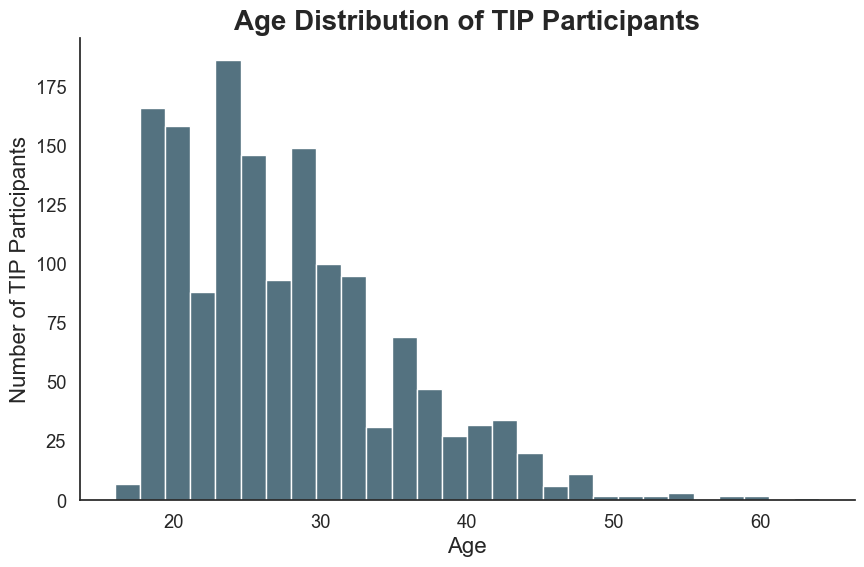

In [382]:
curr_df = df[(df['Status'] == 'Graduated') | (df['Status'] == 'Non Graduated')]
ages = curr_df['age'].dropna()
ages = ages[ages > 5]
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(ages)
sns.despine()
plt.title('Age Distribution of TIP Participants', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Age', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.show()

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2630615500.py:21: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.histplot(
C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2630615500.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Cohort')


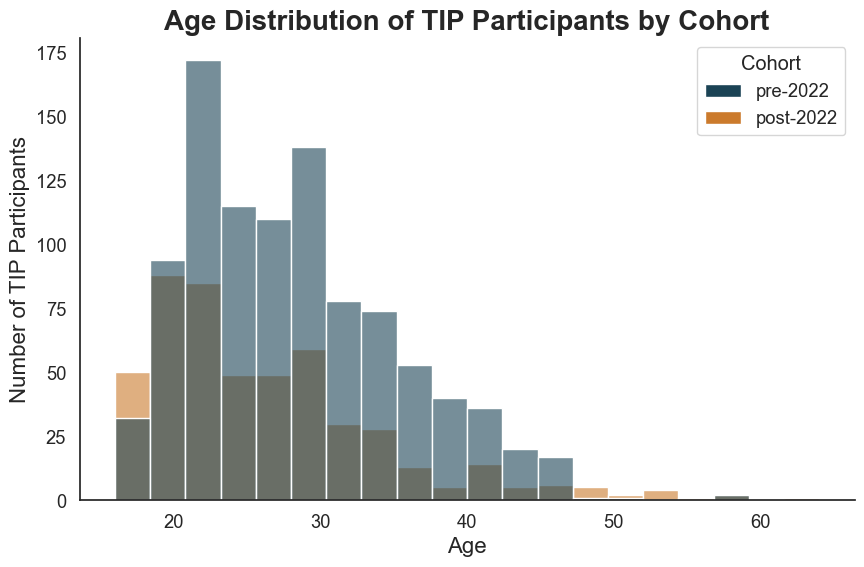

In [383]:
#by cohort

curr_df = df[(df['Status'] == 'Graduated') | (df['Status'] == 'Non Graduated')]
ages = curr_df['age'].dropna()
curr_df = curr_df[curr_df['age'] > 5]  

# Ensure cohort is numeric
curr_df['cohort_2022'] = pd.to_numeric(curr_df['cohort_2022'], errors='coerce')

#cohort label mapping
cohort_label_map = {
    1.0: "pre-2022",
    2.0: "post-2022"
}

cohorts = sorted(curr_df['cohort_2022'].unique())
palette = TIP_colors[:len(cohorts)]

# Plot histogram with overlayed cohorts
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=curr_df,
    x='age',
    hue='cohort_2022',       
    multiple='layer',        
    palette=TIP_colors,          
    bins=20,                 
    alpha=0.6                
)

sns.despine()
plt.title('Age Distribution of TIP Participants by Cohort', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Age', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.legend(title='Cohort')
from matplotlib.patches import Patch
handles = [Patch(facecolor=palette[i], label=cohort_label_map[cohorts[i]]) 
           for i in range(len(cohorts))]

plt.legend(handles=handles, title='Cohort', loc='upper right')

ax.legend(handles=handles, title='Cohort', loc='upper right')
plt.show()

In [384]:
ages.describe()

count    1482.000000
mean       27.539811
std         7.530723
min         0.000000
25%        22.000000
50%        26.000000
75%        32.000000
max        64.000000
Name: age, dtype: float64

In [385]:
df['Status'].value_counts()

Status
Graduated        759
Non Graduated    723
Interviewed      550
Name: count, dtype: int64

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3716141299.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  graph_counts = df.groupby(['StartYear', 'Status']).size().unstack(fill_value=0)


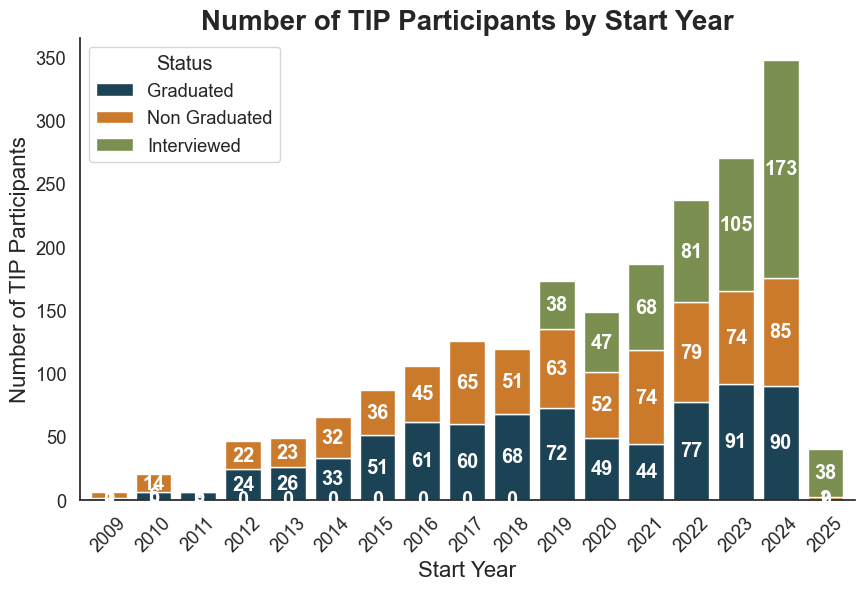

In [386]:
fig, ax = plt.subplots(figsize=(10, 6))

status_order = ["Graduated", "Non Graduated", "Interviewed"]
df['Status'] = pd.Categorical(df['Status'], categories=status_order, ordered=True)

graph_counts = df.groupby(['StartYear', 'Status']).size().unstack(fill_value=0) 
graph_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8)

for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', fontweight='bold')

sns.despine()
plt.xticks(rotation=45)
plt.title('Number of TIP Participants by Start Year', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Start Year', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.show()

## Data Cleaning of TIP_MergedSentencingData and Offense Descriptive Analysis

In [387]:
df_convictions = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Pre-Cleaning\TIP_MergedSentencingData.csv', parse_dates=['DOF', 'DOS', 'StartDate', 'InterviewedDate', 'EndDate', 'GraduatedDate'])
df_convictions = df_convictions[df_convictions['offense_indicator'] == 1]
df_convictions['OffenseBeforeStart'] = df_convictions.apply(lambda x: x['DOS'] < x['StartDate'] if not pd.isnull(x['StartDate']) else (x['DOS'] < x['InterviewedDate'] if not pd.isnull(x['InterviewedDate']) else False), axis=1)

In [388]:
df['OffenseBeforeStart'] = df['tip_id'].apply(lambda x: x in df_convictions[df_convictions['OffenseBeforeStart'] == True]['tip_id'].unique())

In [389]:
df_convictions.head()

,tip_id,DOB,GraduatedDate,InterviewedDate,StartDate,EndDate,DriversLicense,Course,CreatedDate,DOF,DOS,OGS,INCMIN,PCS_OFF_ID,YearsSinceTIP,offense_indicator,OffenseBeforeStart
0,1,1992-08-26,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11,2016-01-09,2016-07-12,9.0,NaN,1068451.0,-2.505185,1,True
1,1,1992-08-26,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11,2016-01-09,2016-07-12,3.0,NaN,1068451.0,-2.505185,1,True
2,1,1992-08-26,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11,2016-01-09,2016-07-12,10.0,NaN,1068451.0,-2.505185,1,True
3,2,1997-01-27,NaT,NaT,2018-07-12,NaT,No,Introduction to Masonry,2018-07-11,2017-05-02,2018-05-22,9.0,NaN,1041834.0,-1.193727,1,True
4,2,1997-01-27,NaT,NaT,2018-07-12,NaT,No,Introduction to Masonry,2018-07-11,2017-05-02,2018-05-22,1.0,0.131579,1041834.0,-1.193727,1,True


In [390]:
df.head()

,tip_id,GraduatedDate,InterviewedDate,StartDate,EndDate,DriversLicense,Course,CreatedDate,Status,age,cohort_2022,StartYear,census_tract,gender,race,ValidYears,ValidYearsPre,OffenseBeforeStart
0,1,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11,Non Graduated,25.0,1.0,2018,4.200356e+10,Male,Black,7.540041,-1.524983,True
1,4,2013-10-16,NaT,2013-08-12,2013-10-16,NaN,Introduction to Masonry,2018-07-12,Graduated,30.0,1.0,2013,4.200313e+10,Male,Black,12.331280,3.389459,False
2,5,2011-02-04,NaT,2010-11-29,2011-02-04,NaN,Introduction to Masonry,2018-07-12,Graduated,22.0,1.0,2010,NaN,NaN,NaN,15.028063,6.091718,False
3,6,NaT,NaT,2013-07-24,2013-09-06,NaN,Introduction to Masonry,2018-07-12,Non Graduated,28.0,1.0,2013,4.212981e+10,Male,Black,12.440794,3.441478,False
4,7,NaT,NaT,2013-08-19,2013-08-27,NaN,Introduction to Masonry,2018-07-12,Non Graduated,23.0,1.0,2013,4.211102e+10,Male,Black,12.468172,3.370294,False


In [391]:
d = df[df["Status"].isin(["Graduated", "Non Graduated"])].copy()

# make sure it's boolean (handles True/False, "True"/"False", 1/0)
d["OffenseBeforeStart"] = d["OffenseBeforeStart"].map(
    lambda x: True if x is True or x == 1 or str(x).strip().lower() == "true"
    else False if x is False or x == 0 or str(x).strip().lower() == "false"
    else np.nan
)

summary = (
    d.groupby("Status")["OffenseBeforeStart"]
     .agg(
         n_total=lambda s: s.notna().sum(),
         n_true=lambda s: (s == True).sum()
     )
     .reset_index()
)

summary["pct_true"] = (summary["n_true"] / summary["n_total"] * 100).round(2)

print(summary)

          Status  n_total  n_true  pct_true
0      Graduated      759     296     39.00
1  Non Graduated      723     280     38.73
2    Interviewed        0       0       NaN


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2541622933.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d.groupby("Status")["OffenseBeforeStart"]


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\1547725093.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = grouped_df.groupby(['StartYear', 'Status'])['OffenseBeforeStart'].mean().reset_index()
C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\1547725093.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for status, subset in grouped_df.groupby('Status'):


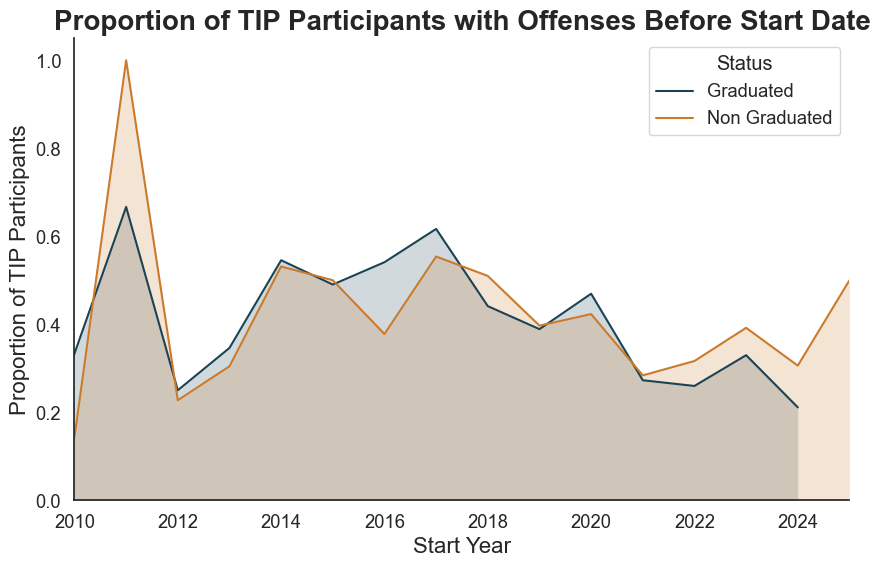

In [392]:
fig, ax = plt.subplots(figsize=(10, 6))

grouped_df = df[df['Status'] != 'Interviewed'].copy()
grouped_df['Status'] = pd.Categorical(grouped_df['Status'], categories=["Graduated", "Non Graduated"], ordered=True)

grouped_df = grouped_df.groupby(['StartYear', 'Status'])['OffenseBeforeStart'].mean().reset_index()
sns.lineplot(
    data=grouped_df,
    x='StartYear',
    y='OffenseBeforeStart',
    hue='Status',
    ax=ax
)
for status, subset in grouped_df.groupby('Status'):
    ax.fill_between(
        subset['StartYear'], subset['OffenseBeforeStart'], 0, alpha=0.2  
    )

sns.despine()

plt.title('Proportion of TIP Participants with Offenses Before Start Date', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Start Year', fontdict={'fontsize': 16})
plt.ylabel('Proportion of TIP Participants', fontdict={'fontsize': 16})
plt.ylim(0, 1.05)
plt.xlim(2010, 2025)
plt.show()

In [393]:
df_convictions = pd.merge(
    df_convictions,
    df_student[['tip_id', 'cohort_2022']],
    on='tip_id',
    how='left'
)
df_convictions['cohort_2022'] = pd.to_numeric(df_convictions['cohort_2022'], errors='coerce')
df_convictions.head

df_convictions = pd.merge(
    df_convictions,
    df[['tip_id','ValidYears','Status']],
    on='tip_id',
    how='left'
)
df_convictions.head

<bound method NDFrame.head of       tip_id         DOB GraduatedDate InterviewedDate  StartDate    EndDate  \
0          1  1992-08-26           NaT             NaT 2018-07-12 2018-08-01   
1          1  1992-08-26           NaT             NaT 2018-07-12 2018-08-01   
2          1  1992-08-26           NaT             NaT 2018-07-12 2018-08-01   
3          2  1997-01-27           NaT             NaT 2018-07-12        NaT   
4          2  1997-01-27           NaT             NaT 2018-07-12        NaT   
...      ...         ...           ...             ...        ...        ...   
5502    2307  1985-04-04           NaT      2025-01-30        NaT        NaT   
5503    2307  1985-04-04           NaT      2025-01-30        NaT        NaT   
5504    2307  1985-04-04           NaT      2025-01-30        NaT        NaT   
5505    2307  1985-04-04           NaT      2025-01-30        NaT        NaT   
5506    2309  1995-07-13           NaT      2025-01-30        NaT        NaT   

     Driv

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\557101707.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


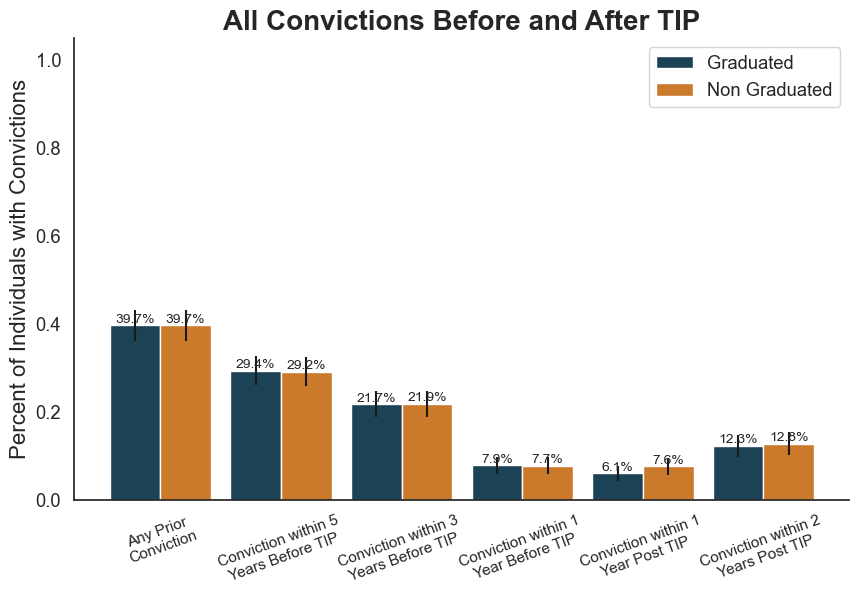

In [394]:
# ================
# CONFIG FOR FULL (COHORT 1+2)
# ================

# keep only Graduated / Non Graduated
off = df_convictions.copy()
off = off[off["Status"].isin(["Graduated", "Non Graduated"])].copy()

# -----------------------------
# 1) PRE cumulative bins
# -----------------------------

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -5: [-5,-4,-3,-2,-1],  #1-5 years pre
    -30: list(range(-30, 0))  # any prior usage
}

off["YearsSinceTIP_int"] = off["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = off[off["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df[(df["Status"].isin(["Graduated", "Non Graduated"]))]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
# 3) POST: cumulative windows [0, i) for i = 1,2 and require ValidYears > i
# -----------------------------
post_points = [1, 2]
rows = []

for i in post_points:
    cur = off[(off["YearsSinceTIP"] >= 0) & (off["YearsSinceTIP"] < i) & (off["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df.loc[(df["Status"] == status) & (df["ValidYears"] >= i), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
# 4) assemble 6 categories + plot
# -----------------------------
label_map = {
    -30: "Any Prior\nConviction",
    -5: "Conviction within 5\nYears Before TIP",
    -3:  "Conviction within 3\nYears Before TIP",
    -1:  "Conviction within 1\nYear Before TIP",
     1:  "Conviction within 1\nYear Post TIP",
     2:  "Conviction within 2\nYears Post TIP"
}
order = [-30, -5, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -5, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)
data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("All Convictions Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Convictions", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2281852085.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


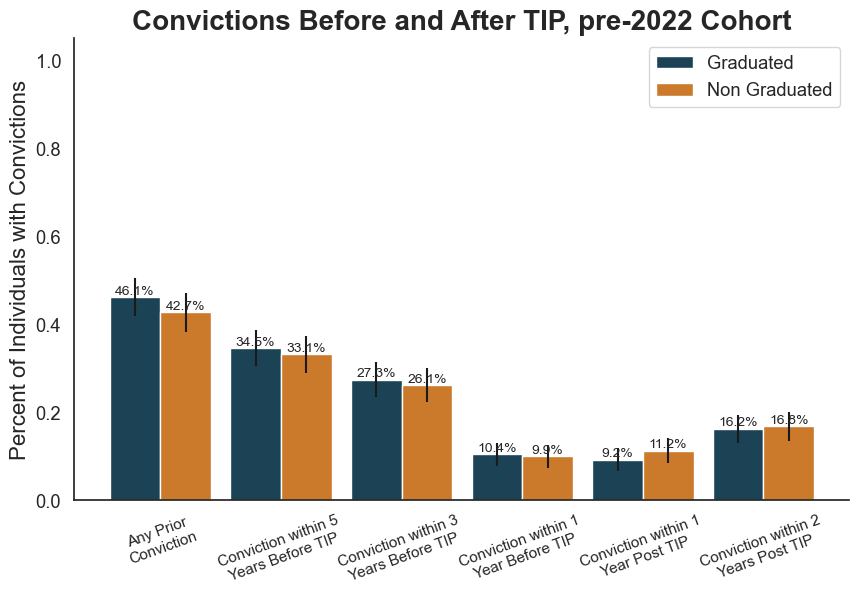

In [395]:
# ================
# CONFIG FOR COHORT 1
# ================

# keep only Graduated / Non Graduated
off = df_convictions.copy()
off = off[off["Status"].isin(["Graduated", "Non Graduated"]) & (off["cohort_2022"] == 1)].copy()

# -----------------------------
# 1) PRE cumulative bins
# -----------------------------

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -5: [-5,-4,-3,-2,-1],  #1-5 years pre
    -30: list(range(-30, 0))  # any prior usage
}

off["YearsSinceTIP_int"] = off["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = off[off["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df[(df["Status"].isin(["Graduated", "Non Graduated"]) & (df["cohort_2022"] == 1))]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
# 3) POST: cumulative windows [0, i) for i = 1,2 and require ValidYears > i
# -----------------------------
post_points = [1, 2]
rows = []

for i in post_points:
    cur = off[(off["YearsSinceTIP"] >= 0) & (off["YearsSinceTIP"] < i) & (off["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df.loc[(df["Status"] == status) & (df["ValidYears"] >= i) & (df["cohort_2022"] ==1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
# 4) assemble 6 categories + plot
# -----------------------------
label_map = {
    -30: "Any Prior\nConviction",
    -5: "Conviction within 5\nYears Before TIP",
    -3:  "Conviction within 3\nYears Before TIP",
    -1:  "Conviction within 1\nYear Before TIP",
     1:  "Conviction within 1\nYear Post TIP",
     2:  "Conviction within 2\nYears Post TIP"
}
order = [-30, -5, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -5, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)
data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Convictions Before and After TIP, pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Convictions", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\1119538199.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


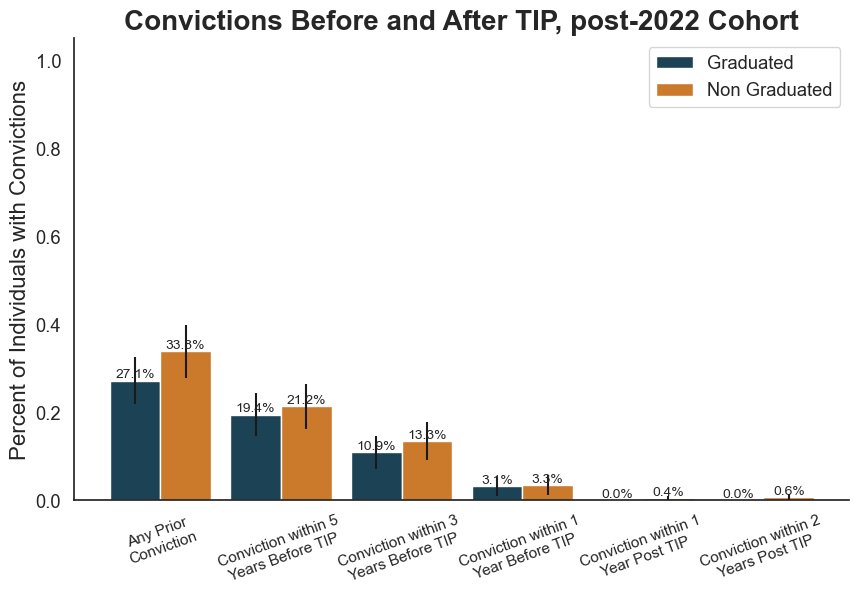

In [396]:
# ================
# CONFIG FOR COHORT 2
# ================

# keep only Graduated / Non Graduated
off = df_convictions.copy()
off = off[off["Status"].isin(["Graduated", "Non Graduated"]) & (off["cohort_2022"] == 2)].copy()

# -----------------------------
# 1) PRE cumulative bins
# -----------------------------

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -5: [-5,-4,-3,-2,-1],  #1-5 years pre
    -30: list(range(-30, 0))  # any prior usage
}

off["YearsSinceTIP_int"] = off["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = off[off["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df[(df["Status"].isin(["Graduated", "Non Graduated"]) & (df["cohort_2022"] == 2))]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
# 3) POST: cumulative windows [0, i) for i = 1,2 and require ValidYears > i
# -----------------------------
post_points = [1, 2]
rows = []

for i in post_points:
    cur = off[(off["YearsSinceTIP"] >= 0) & (off["YearsSinceTIP"] < i) & (off["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df.loc[(df["Status"] == status) & (df["ValidYears"] >= i) & (df["cohort_2022"] ==2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
# 4) assemble 6 categories + plot
# -----------------------------
label_map = {
    -30: "Any Prior\nConviction",
    -5: "Conviction within 5\nYears Before TIP",
    -3:  "Conviction within 3\nYears Before TIP",
    -1:  "Conviction within 1\nYear Before TIP",
     1:  "Conviction within 1\nYear Post TIP",
     2:  "Conviction within 2\nYears Post TIP"
}
order = [-30, -5, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -5, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)
data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Convictions Before and After TIP, post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Convictions", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


## Data Cleaning of arrest_data and Arrests Descriptive Analysis

In [397]:
df_arrests = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Pre-Cleaning\arrest_data.csv', parse_dates=['ArrestDate', 'StartDate', 'EndDate', 'InterviewedDate', 'GraduatedDate'])
df_arrests['ArrestBeforeStart'] = df_arrests.apply(lambda x: x['ArrestDate'] < x['StartDate'] if not pd.isnull(x['StartDate']) else (x['ArrestDate'] < x['InterviewedDate'] if not pd.isnull(x['InterviewedDate']) else False), axis=1)

In [398]:
df['ArrestBeforeStart'] = df['tip_id'].apply(lambda x: x in df_arrests[df_arrests['ArrestBeforeStart'] == True]['tip_id'].unique())

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3009478391.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = grouped_df.groupby(['StartYear', 'Status'])['ArrestBeforeStart'].mean().reset_index()
C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3009478391.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for status, subset in grouped_df.groupby('Status'):


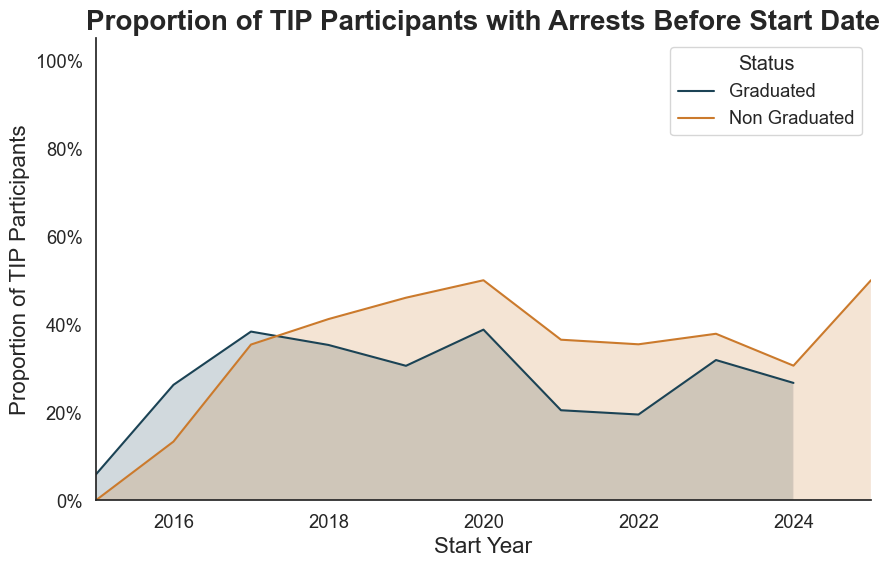

In [399]:
fig, ax = plt.subplots(figsize=(10, 6))

grouped_df = df[df['Status'] != 'Interviewed'].copy()
grouped_df['Status'] = pd.Categorical(grouped_df['Status'], categories=["Graduated", "Non Graduated"], ordered=True)

grouped_df = grouped_df.groupby(['StartYear', 'Status'])['ArrestBeforeStart'].mean().reset_index()
sns.lineplot(
    data=grouped_df,
    x='StartYear',
    y='ArrestBeforeStart',
    hue='Status',
    ax=ax
)
for status, subset in grouped_df.groupby('Status'):
    ax.fill_between(
        subset['StartYear'], subset['ArrestBeforeStart'], 0, alpha=0.2  
    )

sns.despine()

ax.yaxis.set_major_formatter('{:.0%}'.format)
plt.title('Proportion of TIP Participants with Arrests Before Start Date', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Start Year', fontdict={'fontsize': 16})
plt.ylabel('Proportion of TIP Participants', fontdict={'fontsize': 16})
plt.ylim(0, 1.05)
plt.xlim(2015, 2025)
plt.show()

## OGS

In [400]:
df_convictions = pd.merge(
    df_convictions,
    df[['tip_id', 'Status', 'ValidYears', 'cohort_2022']],
    on='tip_id',
    how='left'
)

In [401]:
df_convictions_ogs = df_convictions.dropna(subset=['Status']).copy()
df_convictions_ogs = df_convictions_ogs[df_convictions_ogs['OffenseBeforeStart'] == True]
df_convictions_ogs['StartYear'] = df_convictions_ogs.apply(lambda x: x['StartDate'].year if not pd.isnull(x['StartDate']) else x['InterviewedDate'].year, axis=1)
df_convictions_ogs = df_convictions_ogs[df_convictions_ogs['Status'] != 'Interviewed']
df_convictions_ogs['Status'] = pd.Categorical(df_convictions_ogs['Status'], categories=["Graduated", "Non Graduated"], ordered=True)
df_convictions_ogs['OGS'] = df_convictions_ogs['OGS'].astype(int)

KeyError: ['Status']

In [402]:
# The records with same tip_id, DOF, OGS, and Status are treated as duplicates
df_convictions_ogs = df_convictions_ogs.drop_duplicates(subset=["tip_id", "DOF", "OGS", "Status"])

ogs_df = pd.DataFrame(df_convictions_ogs.groupby(['OGS', 'Status']).size()).reset_index()
ogs_df.columns = ['OGS', 'Status', 'Count']
ogs_df['Percentage'] = ogs_df['Count'] / ogs_df['Count'].sum()
ogs_df = ogs_df.pivot(index='OGS', columns='Status', values=['Percentage', 'Count'])
ogs_df.columns = ['Graduated_Percentage', 'Non Graduated_Percentage', 'Graduated_Count', 'Non Graduated_Count']
ogs_df = ogs_df.reset_index()

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\1743254842.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ogs_df = pd.DataFrame(df_convictions_ogs.groupby(['OGS', 'Status']).size()).reset_index()


In [403]:
# Set up pre-2022 cohort
df_convictions_pre22 = df_convictions_ogs.copy()
df_convictions_pre22 = df_convictions_pre22[df_convictions_pre22["Status"].isin(["Graduated", "Non Graduated"]) & (df_convictions_pre22["cohort_2022"] == 1)].copy()

ogs_pre22_df = pd.DataFrame(df_convictions_pre22.groupby(['OGS', 'Status']).size()).reset_index()
ogs_pre22_df.columns = ['OGS', 'Status', 'Count']
ogs_pre22_df['Percentage'] = ogs_pre22_df['Count'] / ogs_pre22_df['Count'].sum()
ogs_pre22_df = ogs_pre22_df.pivot(index='OGS', columns='Status', values=['Percentage', 'Count'])
ogs_pre22_df.columns = ['Graduated_Percentage', 'Non Graduated_Percentage', 'Graduated_Count', 'Non Graduated_Count']
ogs_pre22_df = ogs_pre22_df.reset_index()

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2601887160.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ogs_pre22_df = pd.DataFrame(df_convictions_pre22.groupby(['OGS', 'Status']).size()).reset_index()


In [404]:
# Set up post-2022 cohort
df_convictions_post22 = df_convictions_ogs.copy()
df_convictions_post22 = df_convictions_post22[df_convictions_post22["Status"].isin(["Graduated", "Non Graduated"]) & (df_convictions_post22["cohort_2022"] == 2)].copy()

ogs_post22_df = pd.DataFrame(df_convictions_post22.groupby(['OGS', 'Status']).size()).reset_index()
ogs_post22_df.columns = ['OGS', 'Status', 'Count']
ogs_post22_df['Percentage'] = ogs_post22_df['Count'] / ogs_post22_df['Count'].sum()
ogs_post22_df = ogs_post22_df.pivot(index='OGS', columns='Status', values=['Percentage', 'Count'])
ogs_post22_df.columns = ['Graduated_Percentage', 'Non Graduated_Percentage', 'Graduated_Count', 'Non Graduated_Count']
ogs_post22_df = ogs_post22_df.reset_index()

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\581008.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ogs_post22_df = pd.DataFrame(df_convictions_post22.groupby(['OGS', 'Status']).size()).reset_index()


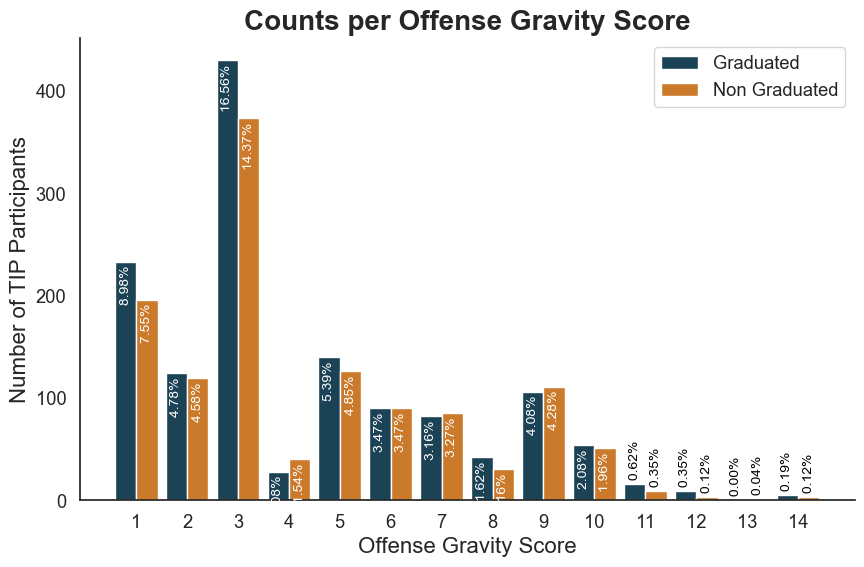

In [405]:
fig, ax = plt.subplots(figsize=(10, 6))

x_indexes = np.arange(len(ogs_df))

bar_width = 0.42

plt.bar(
    x_indexes - bar_width / 2,
    ogs_df['Graduated_Count'],
    width=bar_width,
    label='Graduated',
    color=TIP_colors[0]
)

plt.bar(
    x_indexes + bar_width / 2,
    ogs_df['Non Graduated_Count'],
    width=bar_width,
    label='Non Graduated',
    color=TIP_colors[1]
)

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_df['Graduated_Percentage'], ogs_df['Graduated_Count'], ogs_df['Non Graduated_Percentage'], ogs_df['Non Graduated_Count'])):
    if i >= 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f'{y:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')
    plt.text(x + bar_width / 2, upper2 + 0.01, f'{y2:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_df['Graduated_Percentage'], ogs_df['Graduated_Count'], ogs_df['Non Graduated_Percentage'], ogs_df['Non Graduated_Count'])):
    if i < 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f' {y:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')
    plt.text(x + bar_width / 2, upper2 + 0.01, f' {y2:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')

sns.despine()

plt.xticks(ticks=x_indexes, labels=ogs_df['OGS'], rotation=0)
plt.legend()
plt.title('Counts per Offense Gravity Score', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Offense Gravity Score', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.show()

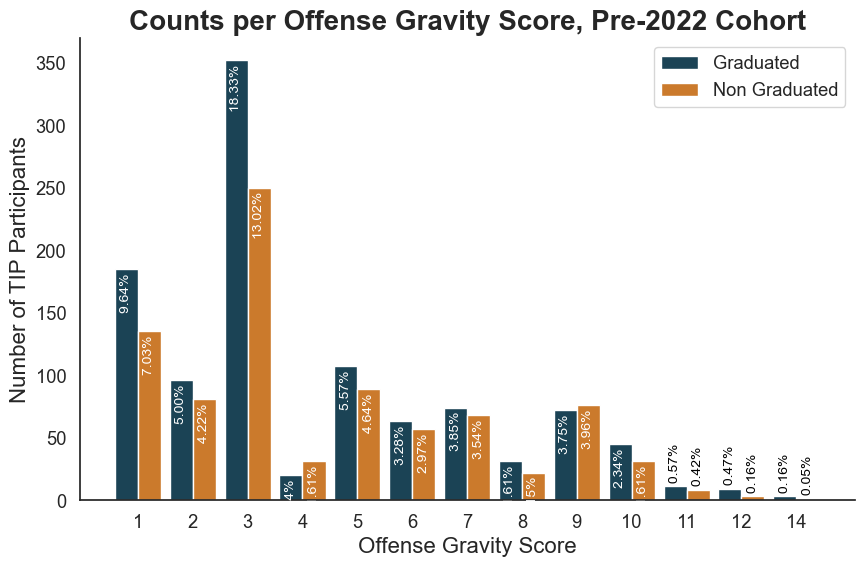

In [406]:
#For pre-2022 cohort
fig, ax = plt.subplots(figsize=(10, 6))

x_indexes = np.arange(len(ogs_pre22_df))

bar_width = 0.42

plt.bar(
    x_indexes - bar_width / 2,
    ogs_pre22_df['Graduated_Count'],
    width=bar_width,
    label='Graduated',
    color=TIP_colors[0]
)

plt.bar(
    x_indexes + bar_width / 2,
    ogs_pre22_df['Non Graduated_Count'],
    width=bar_width,
    label='Non Graduated',
    color=TIP_colors[1]
)

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_pre22_df['Graduated_Percentage'], ogs_pre22_df['Graduated_Count'], ogs_pre22_df['Non Graduated_Percentage'], ogs_pre22_df['Non Graduated_Count'])):
    if i >= 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f'{y:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')
    plt.text(x + bar_width / 2, upper2 + 0.01, f'{y2:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_pre22_df['Graduated_Percentage'], ogs_pre22_df['Graduated_Count'], ogs_pre22_df['Non Graduated_Percentage'], ogs_pre22_df['Non Graduated_Count'])):
    if i < 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f' {y:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')
    plt.text(x + bar_width / 2, upper2 + 0.01, f' {y2:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')

sns.despine()

plt.xticks(ticks=x_indexes, labels=ogs_pre22_df['OGS'], rotation=0)
plt.legend()
plt.title('Counts per Offense Gravity Score, Pre-2022 Cohort', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Offense Gravity Score', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.show()

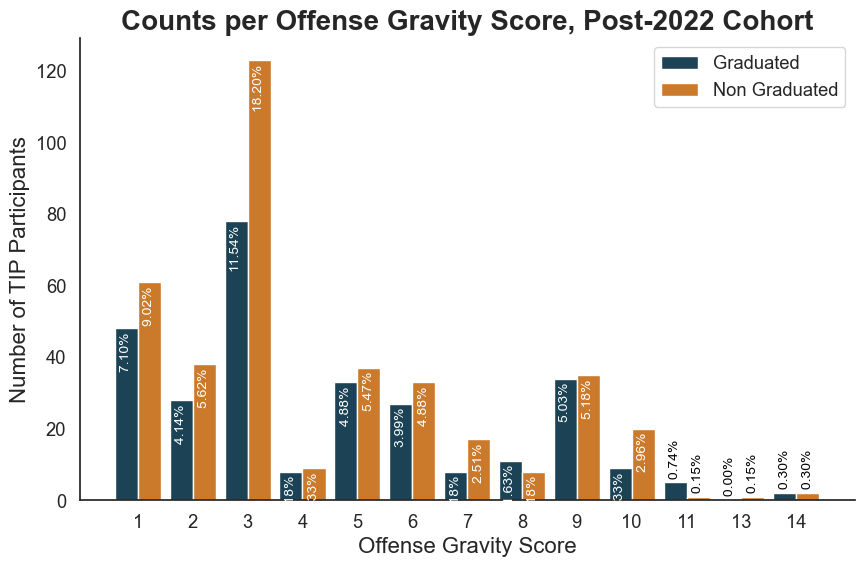

In [407]:
#For post-2022 cohort
fig, ax = plt.subplots(figsize=(10, 6))

x_indexes = np.arange(len(ogs_post22_df))

bar_width = 0.42

plt.bar(
    x_indexes - bar_width / 2,
    ogs_post22_df['Graduated_Count'],
    width=bar_width,
    label='Graduated',
    color=TIP_colors[0]
)

plt.bar(
    x_indexes + bar_width / 2,
    ogs_post22_df['Non Graduated_Count'],
    width=bar_width,
    label='Non Graduated',
    color=TIP_colors[1]
)

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_post22_df['Graduated_Percentage'], ogs_post22_df['Graduated_Count'], ogs_post22_df['Non Graduated_Percentage'], ogs_post22_df['Non Graduated_Count'])):
    if i >= 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f'{y:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')
    plt.text(x + bar_width / 2, upper2 + 0.01, f'{y2:.2%} ', ha='center', va='top', fontsize=10, rotation=90, color='white')

for i, (x, y, upper, y2, upper2) in enumerate(zip(x_indexes, ogs_post22_df['Graduated_Percentage'], ogs_post22_df['Graduated_Count'], ogs_post22_df['Non Graduated_Percentage'], ogs_post22_df['Non Graduated_Count'])):
    if i < 10:
        continue
    plt.text(x - bar_width / 2, upper + 0.01, f' {y:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')
    plt.text(x + bar_width / 2, upper2 + 0.01, f' {y2:.2%}', ha='center', va='bottom', fontsize=10, rotation=90, color='black')

sns.despine()

plt.xticks(ticks=x_indexes, labels=ogs_post22_df['OGS'], rotation=0)
plt.legend()
plt.title('Counts per Offense Gravity Score, Post-2022 Cohort', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('Offense Gravity Score', fontdict={'fontsize': 16})
plt.ylabel('Number of TIP Participants', fontdict={'fontsize': 16})
plt.show()

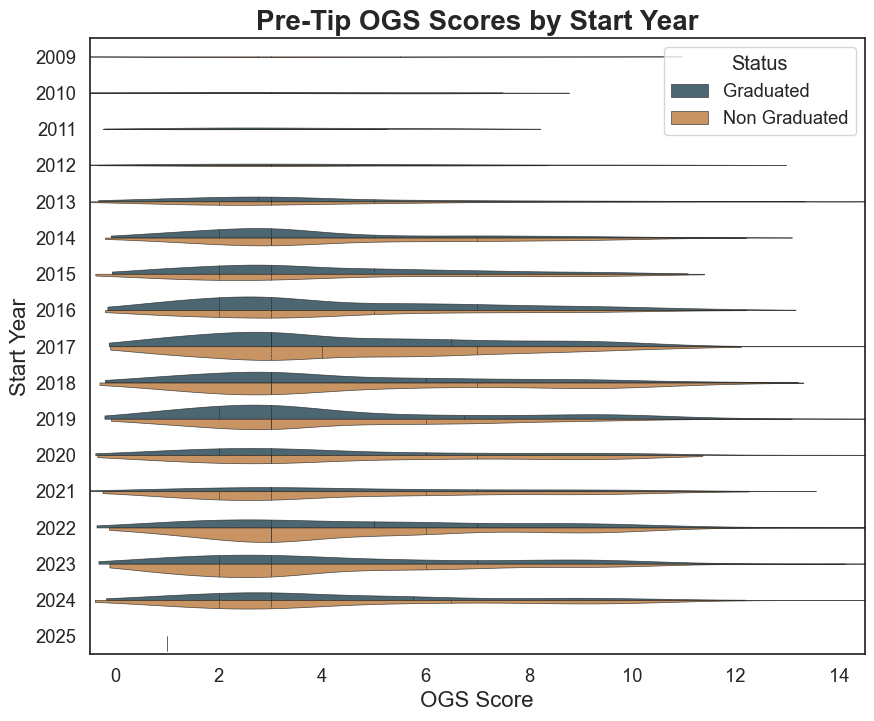

In [408]:
plt.figure(figsize=(10, 8))

sns.violinplot(
    data = df_convictions_ogs,
    y='StartYear',
    x='OGS',
    hue='Status',
    split=True,
    inner='quart',
    orient='h',
    saturation=0.8,
    dodge=True,
    cut=1.1,
    density_norm='count',
    linewidth=0.5,
    alpha=0.8
)

plt.title('Pre-Tip OGS Scores by Start Year', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.ylabel('Start Year', fontdict={'fontsize': 16})
plt.xlabel('OGS Score', fontdict={'fontsize': 16})
plt.xlim(-0.5, 14.5)
plt.show()

## Criminal Justice Interactions

In [409]:
def years_since_TIP(row):
    val = 0
    dof = row['DOF']
    if not pd.isnull(row['StartDate']):
        start = row['StartDate']
    else:
        start = row['InterviewedDate']
    if not pd.isnull(row['GraduatedDate']):
        end = row['GraduatedDate']
    else:
        end = row['EndDate']

    if pd.isnull(start) and pd.isnull(end):
        return None

    if dof > start:
        val = (dof - end).days/365.2425
    elif dof < start:
        val = -(start - dof).days/365.2425
    return val

df_convictions['YearsSinceTIP'] = df_convictions.apply(years_since_TIP, axis=1)

In [410]:
df_arrests = pd.merge(
    df_arrests,
    df[['tip_id', 'Status', 'ValidYears', 'ValidYearsPre', 'cohort_2022']],
    on='tip_id',
    how='left'
)

In [411]:
df_arrests['DOF'] = df_arrests['ArrestDate']
df_arrests['YearsSinceTIP'] = df_arrests.apply(years_since_TIP, axis=1)

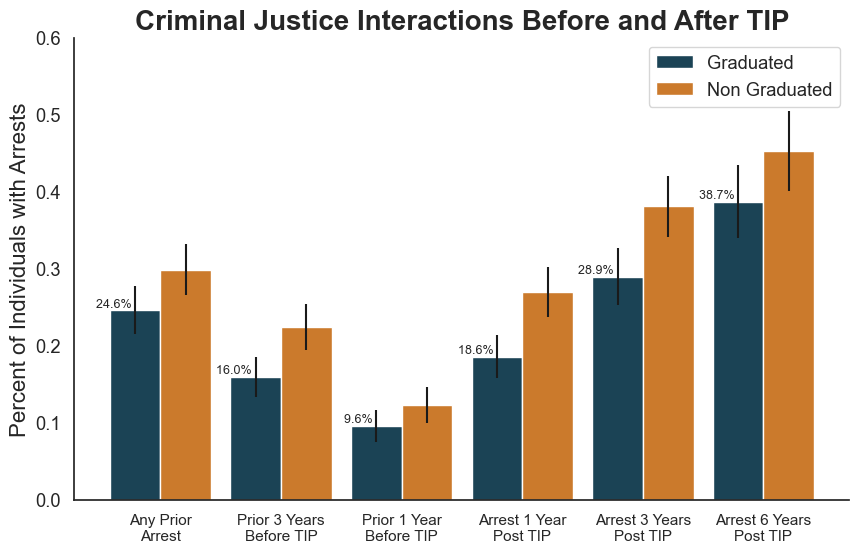

In [412]:
# -------------------------
# Pre-TIP cumulative calculations
# -------------------------
data_before = []

pre_bins = {
    -30: ("Any Prior Arrest", None),  # all pre-TIP arrests, any ValidYearsPre
    -3: ("Prior 3 Years Before TIP", -3),
    -1: ("Prior 1 Year Before TIP", -1)
}

for bin_edge, (label, min_valid_year) in pre_bins.items():
    if bin_edge == -30:
        # Any prior arrest: include tip_ids with any valid pre-TIP data
        curr_grads = df_arrests[
            (df_arrests['YearsSinceTIP'] < 0) &
            (df_arrests['Status'] == 'Graduated')
        ]['tip_id'].unique()
        
        curr_non_grads = df_arrests[
            (df_arrests['YearsSinceTIP'] < 0) &
            (df_arrests['Status'] == 'Non Graduated')
        ]['tip_id'].unique()
        
        curr_interviewed = df_arrests[
            (df_arrests['YearsSinceTIP'] < 0) &
            (df_arrests['Status'] == 'Interviewed')
        ]['tip_id'].unique()
    else:
        # Define the window: cumulative
        start = bin_edge  # e.g., -3 or -1
        end = 0
        
        # Only include tip_ids with enough valid pre-TIP years
        curr_grads = df_arrests[
            (df_arrests['YearsSinceTIP'] >= start) &
            (df_arrests['YearsSinceTIP'] < end) &
            (df_arrests['Status'] == 'Graduated') &
            (df_arrests['tip_id'].isin(df[df['ValidYearsPre'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
        
        curr_non_grads = df_arrests[
            (df_arrests['YearsSinceTIP'] >= start) &
            (df_arrests['YearsSinceTIP'] < end) &
            (df_arrests['Status'] == 'Non Graduated') &
            (df_arrests['tip_id'].isin(df[df['ValidYearsPre'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
        
        curr_interviewed = df_arrests[
            (df_arrests['YearsSinceTIP'] >= start) &
            (df_arrests['YearsSinceTIP'] < end) &
            (df_arrests['Status'] == 'Interviewed') &
            (df_arrests['tip_id'].isin(df[df['ValidYearsPre'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
    
    # Denominator = number of tip_ids that could appear in this window
    denom_grads = len(df[(df['Status'] == 'Graduated') & (df['ValidYearsPre'] <= min_valid_year if min_valid_year is not None else True)])
    denom_non_grads = len(df[(df['Status'] == 'Non Graduated') & (df['ValidYearsPre'] <= min_valid_year if min_valid_year is not None else True)])
    denom_interviewed = len(df[(df['Status'] == 'Interviewed') & (df['ValidYearsPre'] <= min_valid_year if min_valid_year is not None else True)])
    
    data_before.append({
        'YearsSinceTIP': bin_edge,
        'Graduated': len(curr_grads),
        'Graduated Percent': len(curr_grads)/denom_grads if denom_grads>0 else 0,
        'Non Graduated': len(curr_non_grads),
        'Non Graduated Percent': len(curr_non_grads)/denom_non_grads if denom_non_grads>0 else 0,
        'Interviewed': len(curr_interviewed),
        'Interviewed Percent': len(curr_interviewed)/denom_interviewed if denom_interviewed>0 else 0
    })

data_before = pd.DataFrame(data_before)


data_after = []
for i in np.arange(0, 30.2, 0.2):
    curr_grads = df_arrests[(df_arrests['YearsSinceTIP'] >= 0) & (df_arrests['YearsSinceTIP'] < i) & (df_arrests['Status'] == 'Graduated') & (df_arrests['ValidYears'] > i)].copy()
    curr_non_grads = df_arrests[(df_arrests['YearsSinceTIP'] >= 0) & (df_arrests['YearsSinceTIP'] < i) & (df_arrests['Status'] == 'Non Graduated') & (df_arrests['ValidYears'] > i)].copy()
    curr_interviewed = df_arrests[(df_arrests['YearsSinceTIP'] >= 0) & (df_arrests['YearsSinceTIP'] < i) & (df_arrests['Status'] == 'Interviewed') & (df_arrests['ValidYears'] > i)].copy()

    graduate_pop_size = df[(df['Status'] == 'Graduated') & (df['ValidYears'] > i)].tip_id.nunique()
    non_graduate_pop_size = df[(df['Status'] == 'Non Graduated') & (df['ValidYears'] > i)].tip_id.nunique()
    interviewed_pop_size = df[(df['Status'] == 'Interviewed') & (df['ValidYears'] > i)].tip_id.nunique()

    data_after.append({
        'YearsSinceTIP': i,
        'Graduated': curr_grads['tip_id'].nunique(),
        'Graduated Percent' : (curr_grads['tip_id'].nunique() / graduate_pop_size) if graduate_pop_size > 0 else 0,
        'Non Graduated': curr_non_grads['tip_id'].nunique(),
        'Non Graduated Percent' : (curr_non_grads['tip_id'].nunique() / non_graduate_pop_size) if non_graduate_pop_size > 0 else 0,
        'Interviewed': curr_interviewed['tip_id'].nunique(),
        'Interviewed Percent' : (curr_interviewed['tip_id'].nunique() / interviewed_pop_size) if interviewed_pop_size > 0 else 0
    })

data_after = pd.DataFrame(data_after)

data_before['Graduated_Upper_CI'] = data_before['Graduated Percent'] + 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df[df['Status'] == 'Graduated'].tip_id.nunique())
data_before['Graduated_Lower_CI'] = data_before['Graduated Percent'] - 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df[df['Status'] == 'Graduated'].tip_id.nunique())
data_before['Non Graduated_Upper_CI'] = data_before['Non Graduated Percent'] + 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df[df['Status'] == 'Non Graduated'].tip_id.nunique())
data_before['Non Graduated_Lower_CI'] = data_before['Non Graduated Percent'] - 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df[df['Status'] == 'Non Graduated'].tip_id.nunique())
data_before['Interviewed_Upper_CI'] = data_before['Interviewed Percent'] + 1.96 * np.sqrt(data_before['Interviewed Percent'] * (1 - data_before['Interviewed Percent']) / df[df['Status'] == 'Interviewed'].tip_id.nunique())
data_before['Interviewed_Lower_CI'] = data_before['Interviewed Percent'] - 1.96 * np.sqrt(data_before['Interviewed Percent'] * (1 - data_before['Interviewed Percent']) / df[df['Status'] == 'Interviewed'].tip_id.nunique())

data_after['Graduated_Upper_CI'] = data_after['Graduated Percent'] + 1.96 * np.sqrt(data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Graduated')].tip_id.nunique()))
data_after['Graduated_Lower_CI'] = data_after['Graduated Percent'] - 1.96 * np.sqrt(data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Graduated')].tip_id.nunique()))
data_after['Non Graduated_Upper_CI'] = data_after['Non Graduated Percent'] + 1.96 * np.sqrt(data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Non Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Non Graduated')].tip_id.nunique()))
data_after['Non Graduated_Lower_CI'] = data_after['Non Graduated Percent'] - 1.96 * np.sqrt(data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Non Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Non Graduated')].tip_id.nunique()))
data_after['Interviewed_Upper_CI'] = data_after['Interviewed Percent'] + 1.96 * np.sqrt(data_after['Interviewed Percent'] * (1 - data_after['Interviewed Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Interviewed') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Interviewed')].tip_id.nunique()))
data_after['Interviewed_Lower_CI'] = data_after['Interviewed Percent'] - 1.96 * np.sqrt(data_after['Interviewed Percent'] * (1 - data_after['Interviewed Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Interviewed') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Interviewed')].tip_id.nunique()))

data = pd.concat([
    data_before[(data_before['YearsSinceTIP'] == -1) | (data_before['YearsSinceTIP'] == -3) | (data_before['YearsSinceTIP'] == -30)],
    data_after[(data_after['YearsSinceTIP'] == 1) | (data_after['YearsSinceTIP'] == 3) | (data_after['YearsSinceTIP'] == 6)]
])

data = data.drop(columns=['Interviewed', 'Interviewed Percent', 'Interviewed_Lower_CI', 'Interviewed_Upper_CI'])
data['YearsSinceTIP'] = data['YearsSinceTIP'].astype(str)
data['YearsSinceTIP'] = [
    "Any Prior Arrest", 
    "Prior 3 Years Before TIP", 
    "Prior 1 Year Before TIP", 
    "Arrest 1 Year Post TIP", 
    "Arrest 3 Years Post TIP", 
    "Arrest 6 Years Post TIP"
]

grad_err = np.abs(data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values)
non_grad_err = np.abs(data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values)

fig, ax = plt.subplots(figsize=(10, 6))

x_indexes = np.arange(len(data))
width = 0.42

ax.bar(
    x_indexes - width/2,
    data['Graduated Percent'],
    width=width,
    label='Graduated',
    yerr=grad_err,
    capsize=0
)

ax.bar(
    x_indexes + width/2,
    data['Non Graduated Percent'],
    width=width,
    label='Non Graduated',
    yerr=non_grad_err,
    capsize=0,
)


ax.set_xticks(x_indexes)
ax.set_xticklabels([
    "Any Prior\nArrest", 
    "Prior 3 Years\nBefore TIP", 
    "Prior 1 Year\nBefore TIP", 
    "Arrest 1 Year\nPost TIP", 
    "Arrest 3 Years\nPost TIP", 
    "Arrest 6 Years\nPost TIP"
], rotation=0, ha='center', fontsize=11)

for i, (x, y, upper, lower) in enumerate(zip(x_indexes - width/2, data['Graduated Percent'], data['Graduated_Upper_CI'], data['Graduated_Lower_CI'])):
    ax.text(x, y, f"{y:.1%} ", ha='right', va='bottom', fontsize=9, fontdict={'fontweight': 'medium'})

# for i, (x, y, upper, lower) in enumerate(zip(x_indexes + width/2, data['Non Graduated Percent'], data['Non Graduated_Upper_CI'], data['Non Graduated_Lower_CI'])):
#     ax.text(x, y, f" {y:.1%}", ha='left', va='bottom', fontsize=9, fontdict={'fontweight': 'medium'})

sns.despine()

plt.title('Criminal Justice Interactions Before and After TIP', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('', fontdict={'fontsize': 0})
plt.ylabel('Percent of Individuals with Arrests', fontdict={'fontsize': 16})
plt.ylim(0, 0.6)
plt.legend()
plt.show()


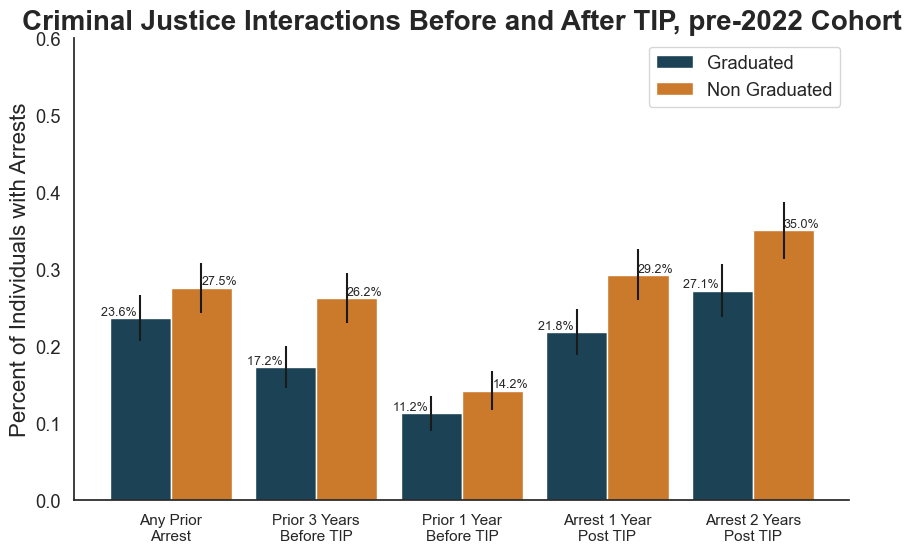

In [413]:
##For pre-2022 cohort
df_arrests_c1 = df_arrests[df_arrests["cohort_2022"] == 1].copy()
df_c1 = df[df["cohort_2022"] == 1].copy()

# -------------------------
# Pre-TIP calculations for pre-2022 cohort
# -------------------------
data_before = []

pre_bins = {
    -30: ("Any Prior Arrest", None),  # all pre-TIP arrests, any ValidYearsPre
    -3: ("Prior 3 Years Before TIP", -3),
    -1: ("Prior 1 Year Before TIP", -1)
}

for bin_edge, (label, min_valid_year) in pre_bins.items():
    if bin_edge == -30:
        # Any prior arrest: include tip_ids with any valid pre-TIP data
        curr_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] < 0) &
            (df_arrests_c1['Status'] == 'Graduated')
        ]['tip_id'].unique()
        
        curr_non_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] < 0) &
            (df_arrests_c1['Status'] == 'Non Graduated')
        ]['tip_id'].unique()
        
        curr_interviewed = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] < 0) &
            (df_arrests_c1['Status'] == 'Interviewed')
        ]['tip_id'].unique()
    else:
        # Define the window: cumulative
        start = bin_edge  # e.g., -3 or -1
        end = 0
        
        # Only include tip_ids with enough valid pre-TIP years
        curr_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] >= start) &
            (df_arrests_c1['YearsSinceTIP'] < end) &
            (df_arrests_c1['Status'] == 'Graduated') &
            (df_arrests_c1['tip_id'].isin(df_c1[df_c1['ValidYearsPre'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
        
        curr_non_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] >= start) &
            (df_arrests_c1['YearsSinceTIP'] < end) &
            (df_arrests_c1['Status'] == 'Non Graduated') &
            (df_arrests_c1['tip_id'].isin(df_c1[df_c1['ValidYearsPre'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
        
        curr_interviewed = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] >= start) &
            (df_arrests_c1['YearsSinceTIP'] < end) &
            (df_arrests_c1['Status'] == 'Interviewed') &
            (df_arrests_c1['tip_id'].isin(df_c1[df_c1['ValidYearsPre'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
    
    # Denominator = number of tip_ids that could appear in this window
    denom_grads = len(df_c1[(df_c1['Status'] == 'Graduated') & (df_c1['ValidYearsPre'] <= min_valid_year if min_valid_year is not None else True)])
    denom_non_grads = len(df_c1[(df_c1['Status'] == 'Non Graduated') & (df_c1['ValidYearsPre'] <= min_valid_year if min_valid_year is not None else True)])
    denom_interviewed = len(df_c1[(df_c1['Status'] == 'Interviewed') & (df_c1['ValidYearsPre'] <= min_valid_year if min_valid_year is not None else True)])
    
    data_before.append({
        'YearsSinceTIP': bin_edge,
        'Graduated': len(curr_grads),
        'Graduated Percent': len(curr_grads)/denom_grads if denom_grads>0 else 0,
        'Non Graduated': len(curr_non_grads),
        'Non Graduated Percent': len(curr_non_grads)/denom_non_grads if denom_non_grads>0 else 0,
        'Interviewed': len(curr_interviewed),
        'Interviewed Percent': len(curr_interviewed)/denom_interviewed if denom_interviewed>0 else 0
    })

data_before = pd.DataFrame(data_before)


data_after = []
for i in np.arange(0, 30.2, 0.2):
    curr_grads = df_arrests_c1[(df_arrests_c1['YearsSinceTIP'] >= 0) & (df_arrests_c1['YearsSinceTIP'] < i) & (df_arrests_c1['Status'] == 'Graduated') & (df_arrests_c1['ValidYears'] > i)].copy()
    curr_non_grads = df_arrests_c1[(df_arrests_c1['YearsSinceTIP'] >= 0) & (df_arrests_c1['YearsSinceTIP'] < i) & (df_arrests_c1['Status'] == 'Non Graduated') & (df_arrests_c1['ValidYears'] > i)].copy()
    curr_interviewed = df_arrests_c1[(df_arrests_c1['YearsSinceTIP'] >= 0) & (df_arrests_c1['YearsSinceTIP'] < i) & (df_arrests_c1['Status'] == 'Interviewed') & (df_arrests_c1['ValidYears'] > i)].copy()

    graduate_pop_size = df_c1[(df_c1['Status'] == 'Graduated') & (df_c1['ValidYears'] > i)].tip_id.nunique()
    non_graduate_pop_size = df_c1[(df_c1['Status'] == 'Non Graduated') & (df_c1['ValidYears'] > i)].tip_id.nunique()
    interviewed_pop_size = df_c1[(df_c1['Status'] == 'Interviewed') & (df_c1['ValidYears'] > i)].tip_id.nunique()

    data_after.append({
        'YearsSinceTIP': i,
        'Graduated': curr_grads['tip_id'].nunique(),
        'Graduated Percent' : (curr_grads['tip_id'].nunique() / graduate_pop_size) if graduate_pop_size > 0 else 0,
        'Non Graduated': curr_non_grads['tip_id'].nunique(),
        'Non Graduated Percent' : (curr_non_grads['tip_id'].nunique() / non_graduate_pop_size) if non_graduate_pop_size > 0 else 0,
        'Interviewed': curr_interviewed['tip_id'].nunique(),
        'Interviewed Percent' : (curr_interviewed['tip_id'].nunique() / interviewed_pop_size) if interviewed_pop_size > 0 else 0
    })

data_after = pd.DataFrame(data_after)


data_before['Graduated_Upper_CI'] = data_before['Graduated Percent'] + 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df[df['Status'] == 'Graduated'].tip_id.nunique())
data_before['Graduated_Lower_CI'] = data_before['Graduated Percent'] - 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df[df['Status'] == 'Graduated'].tip_id.nunique())
data_before['Non Graduated_Upper_CI'] = data_before['Non Graduated Percent'] + 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df[df['Status'] == 'Non Graduated'].tip_id.nunique())
data_before['Non Graduated_Lower_CI'] = data_before['Non Graduated Percent'] - 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df[df['Status'] == 'Non Graduated'].tip_id.nunique())
data_before['Interviewed_Upper_CI'] = data_before['Interviewed Percent'] + 1.96 * np.sqrt(data_before['Interviewed Percent'] * (1 - data_before['Interviewed Percent']) / df[df['Status'] == 'Interviewed'].tip_id.nunique())
data_before['Interviewed_Lower_CI'] = data_before['Interviewed Percent'] - 1.96 * np.sqrt(data_before['Interviewed Percent'] * (1 - data_before['Interviewed Percent']) / df[df['Status'] == 'Interviewed'].tip_id.nunique())

data_after['Graduated_Upper_CI'] = data_after['Graduated Percent'] + 1.96 * np.sqrt(data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Graduated')].tip_id.nunique()))
data_after['Graduated_Lower_CI'] = data_after['Graduated Percent'] - 1.96 * np.sqrt(data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Graduated')].tip_id.nunique()))
data_after['Non Graduated_Upper_CI'] = data_after['Non Graduated Percent'] + 1.96 * np.sqrt(data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Non Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Non Graduated')].tip_id.nunique()))
data_after['Non Graduated_Lower_CI'] = data_after['Non Graduated Percent'] - 1.96 * np.sqrt(data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Non Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Non Graduated')].tip_id.nunique()))
data_after['Interviewed_Upper_CI'] = data_after['Interviewed Percent'] + 1.96 * np.sqrt(data_after['Interviewed Percent'] * (1 - data_after['Interviewed Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Interviewed') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Interviewed')].tip_id.nunique()))
data_after['Interviewed_Lower_CI'] = data_after['Interviewed Percent'] - 1.96 * np.sqrt(data_after['Interviewed Percent'] * (1 - data_after['Interviewed Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Interviewed') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Interviewed')].tip_id.nunique()))

# -------------------------
# Adjust post-TIP bins for post-2022 cohort
# -------------------------

data = pd.concat([
    data_before[(data_before['YearsSinceTIP'] == -1) | 
                (data_before['YearsSinceTIP'] == -3) | 
                (data_before['YearsSinceTIP'] == -30)],
    data_after[(data_after['YearsSinceTIP'] == 1) | 
               (data_after['YearsSinceTIP'] == 2)]  # change from 3->2 years
])

# Drop Interviewed columns
data = data.drop(columns=['Interviewed', 'Interviewed Percent', 'Interviewed_Lower_CI', 'Interviewed_Upper_CI'])

# Rename the x-axis labels
data['YearsSinceTIP'] = data['YearsSinceTIP'].astype(str)
data['YearsSinceTIP'] = [
    "Any Prior Arrest", 
    "Prior 3 Years Before TIP", 
    "Prior 1 Year Before TIP", 
    "Arrest 1 Year Post TIP", 
    "Arrest 2 Years Post TIP"  # changed from 3->2
]

# Recalculate error bars
grad_err = np.abs(data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values)
non_grad_err = np.abs(data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x_indexes = np.arange(len(data))
width = 0.42

ax.bar(
    x_indexes - width/2,
    data['Graduated Percent'],
    width=width,
    label='Graduated',
    yerr=grad_err,
    capsize=0
)

ax.bar(
    x_indexes + width/2,
    data['Non Graduated Percent'],
    width=width,
    label='Non Graduated',
    yerr=non_grad_err,
    capsize=0,
)

ax.set_xticks(x_indexes)
ax.set_xticklabels([
    "Any Prior\nArrest", 
    "Prior 3 Years\nBefore TIP", 
    "Prior 1 Year\nBefore TIP", 
    "Arrest 1 Year\nPost TIP", 
    "Arrest 2 Years\nPost TIP"
], rotation=0, ha='center', fontsize=11)

for i, (x, y, upper, lower) in enumerate(zip(x_indexes - width/2, data['Graduated Percent'], data['Graduated_Upper_CI'], data['Graduated_Lower_CI'])):
    ax.text(x, y, f"{y:.1%} ", ha='right', va='bottom', fontsize=9, fontdict={'fontweight': 'medium'})

for i, (x, y, upper, lower) in enumerate(zip(x_indexes + width/2, data['Non Graduated Percent'], data['Non Graduated_Upper_CI'], data['Non Graduated_Lower_CI'])):
    ax.text(x, y, f"{y:.1%}", ha='left', va='bottom', fontsize=9, fontdict={'fontweight': 'medium'})

sns.despine()

plt.title('Criminal Justice Interactions Before and After TIP, pre-2022 Cohort', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('', fontdict={'fontsize': 0})
plt.ylabel('Percent of Individuals with Arrests', fontdict={'fontsize': 16})
plt.ylim(0, 0.6)
plt.legend()
plt.show()



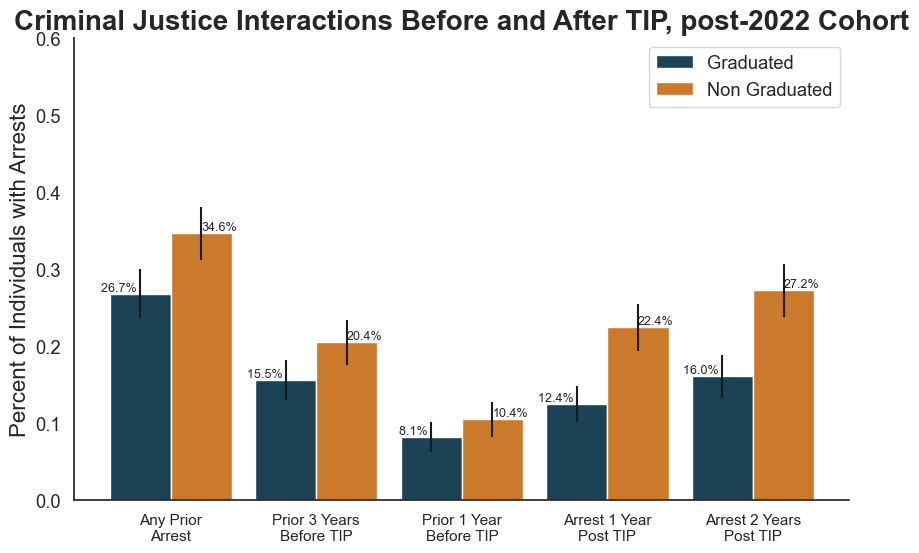

In [414]:
##For post-2022 cohort
df_arrests_c1 = df_arrests[df_arrests["cohort_2022"] == 2].copy()
df_c1 = df[df["cohort_2022"] == 2].copy()


data_before = []

pre_bins = {
    -30: ("Any Prior Arrest", None),  # all pre-TIP arrests, any ValidYearsPre
    -3: ("Prior 3 Years Before TIP", -3),
    -1: ("Prior 1 Year Before TIP", -1)
}

for bin_edge, (label, min_valid_year) in pre_bins.items():
    if bin_edge == -30:
        # Any prior arrest: include tip_ids with any valid pre-TIP data
        curr_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] < 0) &
            (df_arrests_c1['Status'] == 'Graduated')
        ]['tip_id'].unique()
        
        curr_non_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] < 0) &
            (df_arrests_c1['Status'] == 'Non Graduated')
        ]['tip_id'].unique()
        
        curr_interviewed = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] < 0) &
            (df_arrests_c1['Status'] == 'Interviewed')
        ]['tip_id'].unique()
    else:
        # Define the window: cumulative
        start = bin_edge  # e.g., -3 or -1
        end = 0
        
        # Only include tip_ids with enough valid pre-TIP years
        curr_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] >= start) &
            (df_arrests_c1['YearsSinceTIP'] < end) &
            (df_arrests_c1['Status'] == 'Graduated') &
            (df_arrests_c1['tip_id'].isin(df_c1[df_c1['ValidYearsPre'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
        
        curr_non_grads = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] >= start) &
            (df_arrests_c1['YearsSinceTIP'] < end) &
            (df_arrests_c1['Status'] == 'Non Graduated') &
            (df_arrests_c1['tip_id'].isin(df_c1[df_c1['ValidYearsPre'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
        
        curr_interviewed = df_arrests_c1[
            (df_arrests_c1['YearsSinceTIP'] >= start) &
            (df_arrests_c1['YearsSinceTIP'] < end) &
            (df_arrests_c1['Status'] == 'Interviewed') &
            (df_arrests_c1['tip_id'].isin(df_c1[df_c1['ValidYearsPre'] <= min_valid_year]['tip_id']))
        ]['tip_id'].unique()
    
    # Denominator = number of tip_ids that could appear in this window
    denom_grads = len(df_c1[(df_c1['Status'] == 'Graduated') & (df_c1['ValidYearsPre'] <= min_valid_year if min_valid_year is not None else True)])
    denom_non_grads = len(df_c1[(df_c1['Status'] == 'Non Graduated') & (df_c1['ValidYearsPre'] <= min_valid_year if min_valid_year is not None else True)])
    denom_interviewed = len(df_c1[(df_c1['Status'] == 'Interviewed') & (df_c1['ValidYearsPre'] <= min_valid_year if min_valid_year is not None else True)])
    
    data_before.append({
        'YearsSinceTIP': bin_edge,
        'Graduated': len(curr_grads),
        'Graduated Percent': len(curr_grads)/denom_grads if denom_grads>0 else 0,
        'Non Graduated': len(curr_non_grads),
        'Non Graduated Percent': len(curr_non_grads)/denom_non_grads if denom_non_grads>0 else 0,
        'Interviewed': len(curr_interviewed),
        'Interviewed Percent': len(curr_interviewed)/denom_interviewed if denom_interviewed>0 else 0
    })

data_before = pd.DataFrame(data_before)


data_after = []
for i in np.arange(0, 30.2, 0.2):
    curr_grads = df_arrests_c1[(df_arrests_c1['YearsSinceTIP'] >= 0) & (df_arrests_c1['YearsSinceTIP'] < i) & (df_arrests_c1['Status'] == 'Graduated') & (df_arrests_c1['ValidYears'] > i)].copy()
    curr_non_grads = df_arrests_c1[(df_arrests_c1['YearsSinceTIP'] >= 0) & (df_arrests_c1['YearsSinceTIP'] < i) & (df_arrests_c1['Status'] == 'Non Graduated') & (df_arrests_c1['ValidYears'] > i)].copy()
    curr_interviewed = df_arrests_c1[(df_arrests_c1['YearsSinceTIP'] >= 0) & (df_arrests_c1['YearsSinceTIP'] < i) & (df_arrests_c1['Status'] == 'Interviewed') & (df_arrests_c1['ValidYears'] > i)].copy()

    graduate_pop_size = df_c1[(df_c1['Status'] == 'Graduated') & (df_c1['ValidYears'] > i)].tip_id.nunique()
    non_graduate_pop_size = df_c1[(df_c1['Status'] == 'Non Graduated') & (df_c1['ValidYears'] > i)].tip_id.nunique()
    interviewed_pop_size = df_c1[(df_c1['Status'] == 'Interviewed') & (df_c1['ValidYears'] > i)].tip_id.nunique()

    data_after.append({
        'YearsSinceTIP': i,
        'Graduated': curr_grads['tip_id'].nunique(),
        'Graduated Percent' : (curr_grads['tip_id'].nunique() / graduate_pop_size) if graduate_pop_size > 0 else 0,
        'Non Graduated': curr_non_grads['tip_id'].nunique(),
        'Non Graduated Percent' : (curr_non_grads['tip_id'].nunique() / non_graduate_pop_size) if non_graduate_pop_size > 0 else 0,
        'Interviewed': curr_interviewed['tip_id'].nunique(),
        'Interviewed Percent' : (curr_interviewed['tip_id'].nunique() / interviewed_pop_size) if interviewed_pop_size > 0 else 0
    })

data_after = pd.DataFrame(data_after)


data_before['Graduated_Upper_CI'] = data_before['Graduated Percent'] + 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df[df['Status'] == 'Graduated'].tip_id.nunique())
data_before['Graduated_Lower_CI'] = data_before['Graduated Percent'] - 1.96 * np.sqrt(data_before['Graduated Percent'] * (1 - data_before['Graduated Percent']) / df[df['Status'] == 'Graduated'].tip_id.nunique())
data_before['Non Graduated_Upper_CI'] = data_before['Non Graduated Percent'] + 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df[df['Status'] == 'Non Graduated'].tip_id.nunique())
data_before['Non Graduated_Lower_CI'] = data_before['Non Graduated Percent'] - 1.96 * np.sqrt(data_before['Non Graduated Percent'] * (1 - data_before['Non Graduated Percent']) / df[df['Status'] == 'Non Graduated'].tip_id.nunique())
data_before['Interviewed_Upper_CI'] = data_before['Interviewed Percent'] + 1.96 * np.sqrt(data_before['Interviewed Percent'] * (1 - data_before['Interviewed Percent']) / df[df['Status'] == 'Interviewed'].tip_id.nunique())
data_before['Interviewed_Lower_CI'] = data_before['Interviewed Percent'] - 1.96 * np.sqrt(data_before['Interviewed Percent'] * (1 - data_before['Interviewed Percent']) / df[df['Status'] == 'Interviewed'].tip_id.nunique())

data_after['Graduated_Upper_CI'] = data_after['Graduated Percent'] + 1.96 * np.sqrt(data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Graduated')].tip_id.nunique()))
data_after['Graduated_Lower_CI'] = data_after['Graduated Percent'] - 1.96 * np.sqrt(data_after['Graduated Percent'] * (1 - data_after['Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Graduated')].tip_id.nunique()))
data_after['Non Graduated_Upper_CI'] = data_after['Non Graduated Percent'] + 1.96 * np.sqrt(data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Non Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Non Graduated')].tip_id.nunique()))
data_after['Non Graduated_Lower_CI'] = data_after['Non Graduated Percent'] - 1.96 * np.sqrt(data_after['Non Graduated Percent'] * (1 - data_after['Non Graduated Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Non Graduated') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Non Graduated')].tip_id.nunique()))
data_after['Interviewed_Upper_CI'] = data_after['Interviewed Percent'] + 1.96 * np.sqrt(data_after['Interviewed Percent'] * (1 - data_after['Interviewed Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Interviewed') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Interviewed')].tip_id.nunique()))
data_after['Interviewed_Lower_CI'] = data_after['Interviewed Percent'] - 1.96 * np.sqrt(data_after['Interviewed Percent'] * (1 - data_after['Interviewed Percent']) / data_after['YearsSinceTIP'].apply(lambda x: df[(df['Status'] == 'Interviewed') & (df['ValidYears'] > x)].tip_id.nunique() if x > 0 else df[(df['Status'] == 'Interviewed')].tip_id.nunique()))

# -------------------------
# Adjust post-TIP bins for post-2022 cohort
# -------------------------

data = pd.concat([
    data_before[(data_before['YearsSinceTIP'] == -1) | 
                (data_before['YearsSinceTIP'] == -3) | 
                (data_before['YearsSinceTIP'] == -30)],
    data_after[(data_after['YearsSinceTIP'] == 1) | 
               (data_after['YearsSinceTIP'] == 2)]  # change from 3->2 years
])

# Drop Interviewed columns
data = data.drop(columns=['Interviewed', 'Interviewed Percent', 'Interviewed_Lower_CI', 'Interviewed_Upper_CI'])

# Rename the x-axis labels
data['YearsSinceTIP'] = data['YearsSinceTIP'].astype(str)
data['YearsSinceTIP'] = [
    "Any Prior Arrest", 
    "Prior 3 Years Before TIP", 
    "Prior 1 Year Before TIP", 
    "Arrest 1 Year Post TIP", 
    "Arrest 2 Years Post TIP"  # changed from 3->2
]

# Recalculate error bars
grad_err = np.abs(data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values)
non_grad_err = np.abs(data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x_indexes = np.arange(len(data))
width = 0.42

ax.bar(
    x_indexes - width/2,
    data['Graduated Percent'],
    width=width,
    label='Graduated',
    yerr=grad_err,
    capsize=0
)

ax.bar(
    x_indexes + width/2,
    data['Non Graduated Percent'],
    width=width,
    label='Non Graduated',
    yerr=non_grad_err,
    capsize=0,
)

ax.set_xticks(x_indexes)
ax.set_xticklabels([
    "Any Prior\nArrest", 
    "Prior 3 Years\nBefore TIP", 
    "Prior 1 Year\nBefore TIP", 
    "Arrest 1 Year\nPost TIP", 
    "Arrest 2 Years\nPost TIP"
], rotation=0, ha='center', fontsize=11)

for i, (x, y, upper, lower) in enumerate(zip(x_indexes - width/2, data['Graduated Percent'], data['Graduated_Upper_CI'], data['Graduated_Lower_CI'])):
    ax.text(x, y, f"{y:.1%} ", ha='right', va='bottom', fontsize=9, fontdict={'fontweight': 'medium'})

for i, (x, y, upper, lower) in enumerate(zip(x_indexes + width/2, data['Non Graduated Percent'], data['Non Graduated_Upper_CI'], data['Non Graduated_Lower_CI'])):
    ax.text(x, y, f"{y:.1%}", ha='left', va='bottom', fontsize=9, fontdict={'fontweight': 'medium'})

sns.despine()

plt.title('Criminal Justice Interactions Before and After TIP, post-2022 Cohort', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlabel('', fontdict={'fontsize': 0})
plt.ylabel('Percent of Individuals with Arrests', fontdict={'fontsize': 16})
plt.ylim(0, 0.6)
plt.legend()
plt.show()


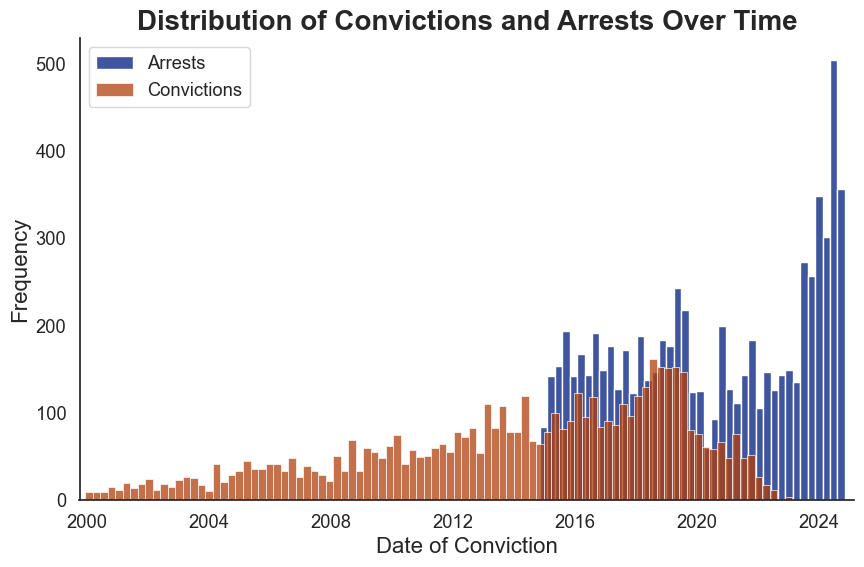

In [415]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    df_arrests['DOF'],
    binwidth=90,
    color=sns.color_palette('dark')[0]
)

sns.histplot(
    df_convictions['DOF'],
    binwidth=90,
    color=sns.color_palette('dark')[1]
)

sns.despine()

plt.title('Distribution of Convictions and Arrests Over Time', fontdict={'fontsize': 20, 'fontweight': 'semibold'})
plt.xlim(pd.Timestamp('1999-10-01'), pd.Timestamp('2025-02-28'))
plt.xlabel('Date of Conviction', fontdict={'fontsize': 16})
plt.ylabel('Frequency', fontdict={'fontsize': 16})
plt.legend(['Arrests', 'Convictions'])
plt.show()


## Data cleaning and exploration of social service usage and UI 

In [416]:
df_uibenefits = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_ui.csv')

In [417]:
df_uibenefits.head()

,Unnamed: 0,TIP_ID,REQUEST_PERIOD,UC_BENEFIT
0,1,1189,20173,2496.0
1,2,297,20173,1648.0
2,3,663,20172,484.0
3,4,34,20172,1281.0
4,5,129,20172,2320.0


In [418]:
df_uibenefits = df_uibenefits.rename(columns={"TIP_ID": "tip_id"})

df_uibenefits["quarter"] = pd.to_numeric(df_uibenefits["REQUEST_PERIOD"], errors="coerce")

df_uibenefits["q_num"] = (df_uibenefits["quarter"] % 10).astype("Int64")
df_uibenefits["year"] = (df_uibenefits["quarter"] // 10).astype("Int64")

df_uibenefits["ui_dummy"] = (~df_uibenefits["UC_BENEFIT"].isna()).astype(int)

# 5) annualize: if any quarter in that year has ui_dummy==1 -> employed that year for UI receipt
df_ui_annual = (
    df_uibenefits.groupby(["tip_id", "year"], as_index=False)["ui_dummy"]
    .max()
)

df_uibenefits.head()

,Unnamed: 0,tip_id,REQUEST_PERIOD,UC_BENEFIT,quarter,q_num,year,ui_dummy
0,1,1189,20173,2496.0,20173,3,2017,1
1,2,297,20173,1648.0,20173,3,2017,1
2,3,663,20172,484.0,20172,2,2017,1
3,4,34,20172,1281.0,20172,2,2017,1
4,5,129,20172,2320.0,20172,2,2017,1


In [419]:
df_ui_annual.head()

,tip_id,year,ui_dummy
0,1,2017,0
1,1,2018,0
2,1,2019,0
3,1,2020,0
4,1,2021,0


In [420]:
df_services = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_ss.csv')
df_services = pd.merge(
    df_services,
    df[['tip_id', 'Status', 'StartDate', 'InterviewedDate', 'EndDate', 'GraduatedDate', 'ValidYears', 'ValidYearsPre']],
    on='tip_id',
    how='left'
)

df_services['DOF'] = pd.to_datetime(df_services['year'], format='%Y')
df_services['YearsSinceTIP'] = df_services.apply(years_since_TIP, axis=1)

In [421]:
df_services.head()
df_services["tip_id"].nunique()

2166

In [422]:
df.columns

Index(['tip_id', 'GraduatedDate', 'InterviewedDate', 'StartDate', 'EndDate',
       'DriversLicense', 'Course', 'CreatedDate', 'Status', 'age',
       'cohort_2022', 'StartYear', 'census_tract', 'gender', 'race',
       'ValidYears', 'ValidYearsPre', 'OffenseBeforeStart',
       'ArrestBeforeStart'],
      dtype='object')

In [423]:
df_services = pd.merge(
    df_services,
    df_student[['tip_id', 'cohort_2022']],
    on='tip_id',
    how='left'
)
df_services['cohort_2022'] = pd.to_numeric(df_services['cohort_2022'], errors='coerce')


In [424]:
df_services.head

<bound method NDFrame.head of        Unnamed: 0  tip_id  year  aging  drug_alcohol  mental_health  \
0               1     632  2011      0             0              0   
1               2     632  2012      0             0              0   
2               3     632  2013      0             0              0   
3               4     632  2014      0             0              0   
4               5     632  2015      0             0              0   
...           ...     ...   ...    ...           ...            ...   
27488       27489    2187  2019      0             0              0   
27489       27490    2187  2020      0             0              0   
27490       27491    2187  2021      0             0              0   
27491       27492    2187  2022      0             0              0   
27492       27493    2187  2023      0             0              0   

       cyf_child  cyf_parent  family_support_center  early_childhood  ...  \
0              0           0            

In [425]:

df_services["year"] = pd.to_numeric(df_services["year"], errors="coerce")

df_services["SNAP_TANF"] = df_services["snap"].fillna(0) + df_services["tanf"].fillna(0)


df_services = df_services.merge(
    df_ui_annual,   
    on=["tip_id", "year"],
    how="outer"
)

df_services = df_services.merge(
    df[["tip_id", "StartYear"]],
    on="tip_id",
    how="left"
)

df_services["distance_from_TIP"] = df_services["year"] - df_services["StartYear"]

service_cols = [
    "aging",
    "drug_alcohol",
    "mental_health",
    "family_support_center",
    "early_childhood",
    "jail_collab",
    "matp",
    "home_visiting",
    "dhs_housing_supports",
    "indep_living",
    "intellectual_disab",
    "link_referral",
    "public_housing",
    "section8_housing",
    "medicaid",
    "snap",
    "tanf",
    "ssi",
    "ccdf",
]

svc_mat = df_services[service_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

df_services["any_one"] = (svc_mat.eq(1).any(axis=1)).astype(int)


ui_col = "ui_dummy" 

df_services[ui_col] = pd.to_numeric(df_services[ui_col], errors="coerce").fillna(0)
df_services["any_one_plus_ui"] = ((df_services["any_one"] == 1) | (df_services[ui_col] == 1)).astype(int)


In [426]:
df_services = df_services.drop(columns=["Unnamed: 0"], errors="ignore")
df_services.head()

,tip_id,year,aging,drug_alcohol,mental_health,cyf_child,cyf_parent,family_support_center,early_childhood,jail_collab,...,ValidYearsPre,DOF,YearsSinceTIP,cohort_2022,SNAP_TANF,ui_dummy,StartYear,distance_from_TIP,any_one,any_one_plus_ui
0,1,2010,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.524983,2010-01-01,-8.525842,1.0,0.0,0.0,2018.0,-8.0,1,1
1,1,2011,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.524983,2011-01-01,-7.526506,1.0,0.0,0.0,2018.0,-7.0,1,1
2,1,2012,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.524983,2012-01-01,-6.527170,1.0,0.0,0.0,2018.0,-6.0,1,1
3,1,2013,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.524983,2013-01-01,-5.525096,1.0,0.0,0.0,2018.0,-5.0,1,1
4,1,2014,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.524983,2014-01-01,-4.525760,1.0,0.0,0.0,2018.0,-4.0,1,1


In [427]:
df_services.columns

Index(['tip_id', 'year', 'aging', 'drug_alcohol', 'mental_health', 'cyf_child',
       'cyf_parent', 'family_support_center', 'early_childhood', 'jail_collab',
       'matp', 'home_visiting', 'dhs_housing_supports', 'indep_living',
       'intellectual_disab', 'cyf_referral', 'link_referral', 'public_housing',
       'section8_housing', 'courts', 'medicaid', 'jail', 'snap', 'tanf', 'ssi',
       'ccdf', 'Status', 'StartDate', 'InterviewedDate', 'EndDate',
       'GraduatedDate', 'ValidYears', 'ValidYearsPre', 'DOF', 'YearsSinceTIP',
       'cohort_2022', 'SNAP_TANF', 'ui_dummy', 'StartYear',
       'distance_from_TIP', 'any_one', 'any_one_plus_ui'],
      dtype='object')

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\4178798477.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


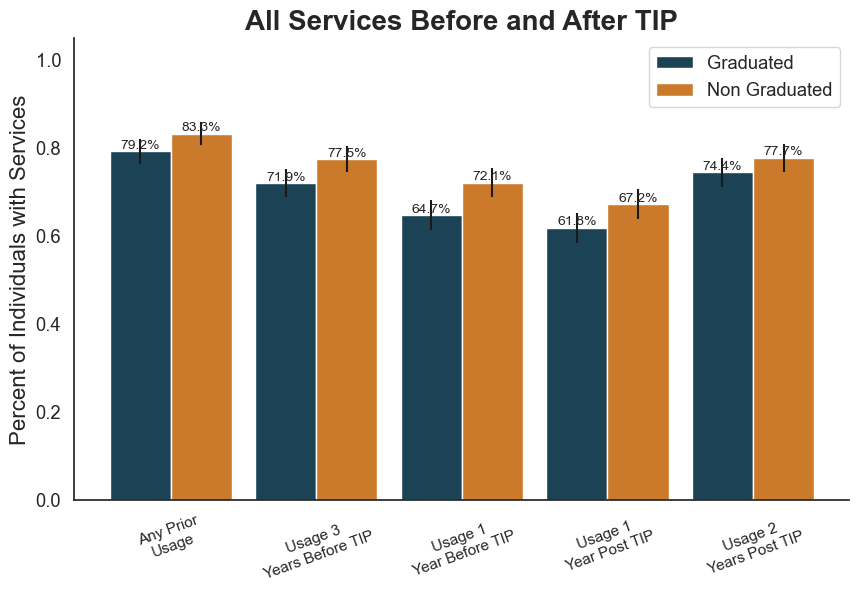

In [428]:
# ================
# CONFIG FOR FULL (COHORT 1+2)
# ================

# keep only Graduated / Non Graduated
svc = df_services.copy()
svc = svc[
    (svc["any_one"] == 1) &
    (svc["Status"].isin(["Graduated","Non Graduated"]))
].copy()
# -----------------------------
# 1) PRE cumulative bins
# -----------------------------

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc["YearsSinceTIP_int"] = svc["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc[svc["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df[(df["Status"].isin(["Graduated", "Non Graduated"]))]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
# 3) POST: cumulative windows [0, i) for i = 1,2 and require ValidYears > i
# -----------------------------
post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc[(svc["YearsSinceTIP"] >= 0) & (svc["YearsSinceTIP"] < i+1) & (svc["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df.loc[(df["Status"] == status) & (df["ValidYears"] >= i), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
# 4) assemble 6 categories + plot
# -----------------------------
label_map = {
    -30: "Any Prior\nUsage",
    -3:  "Usage 3\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("All Services Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3149994293.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


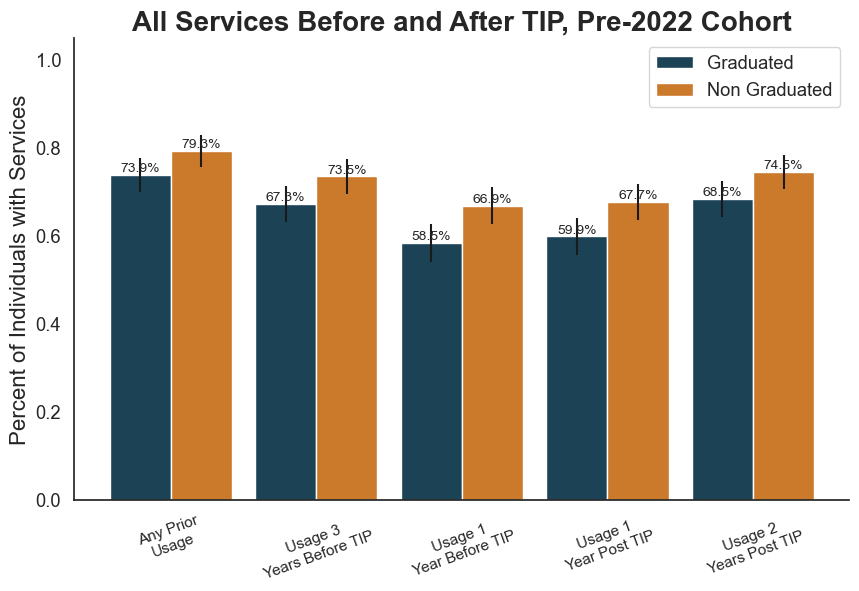

In [429]:
# ================
# CONFIG FOR COHORT 1
# ================

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 1) &
    (svc_c1["any_one"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
# 1) PRE cumulative bins
# -----------------------------

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df[(df["Status"].isin(["Graduated", "Non Graduated"])) & (df["cohort_2022"] == 1)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
# 3) POST: cumulative windows [0, i) for i = 1,2 and require ValidYears > i
# -----------------------------
post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i) & (svc_c1["ValidYears"] > i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df.loc[(df["Status"] == status) & (df["ValidYears"] > i) & (df["cohort_2022"] ==1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
# 4) assemble 6 categories + plot
# -----------------------------
label_map = {
    -30: "Any Prior\nUsage",
    -3:  "Usage 3\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("All Services Before and After TIP, Pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3584066048.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


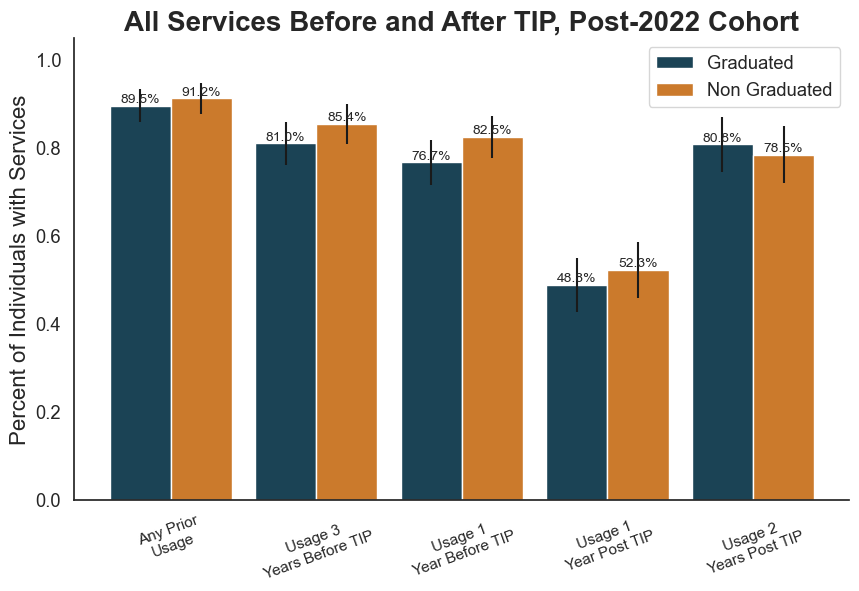

In [430]:
# ================
# CONFIG FOR COHORT 2
# ================

# keep only Graduated / Non Graduated
svc_c1 = df_services.copy()
svc_c1 = svc_c1[
    (svc_c1["cohort_2022"] == 2) &
    (svc_c1["any_one"] == 1) &
    (svc_c1["Status"].isin(["Graduated","Non Graduated"]))
].copy()

# -----------------------------
# 1) PRE cumulative bins
# -----------------------------

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -30: list(range(-30, 0))  # any prior usage
}

svc_c1["YearsSinceTIP_int"] = svc_c1["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = svc_c1[svc_c1["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df[(df["Status"].isin(["Graduated", "Non Graduated"])) & (df["cohort_2022"] == 2)]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
# 3) POST: cumulative windows [0, i) for i = 1,2 and require ValidYears > i
# -----------------------------
post_points = [1, 2]
rows = []

for i in post_points:
    cur = svc_c1[(svc_c1["YearsSinceTIP"] >= 0) & (svc_c1["YearsSinceTIP"] < i+1) & (svc_c1["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df.loc[(df["Status"] == status) & (df["ValidYears"] >= i) & (df["cohort_2022"] == 2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
# 4) assemble 6 categories + plot
# -----------------------------
label_map = {
    -30: "Any Prior\nUsage",
    -3:  "Usage 3\nYears Before TIP",
    -1:  "Usage 1\nYear Before TIP",
     1:  "Usage 1\nYear Post TIP",
     2:  "Usage 2\nYears Post TIP"
}
order = [-30, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)
data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("All Services Before and After TIP, Post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Services", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


In [431]:
#Put this into a function so we can loop through multiple services
def plot_service_usage(service_col, cohort, df_services, df):

    svc = df_services.copy()
    svc = svc[svc["Status"].isin(["Graduated", "Non Graduated"])]
    svc = svc[svc["cohort_2022"] == cohort]

    # keep only rows where service was used
    svc = svc[svc[service_col] == 1]

    svc["YearsSinceTIP_int"] = svc["YearsSinceTIP"].round().astype(int)

    pre_bins = {
        -1: [-1],
        -3: [-3, -2, -1],
        -30: list(range(-30, 0))
    }

    rows = []

    for bin_edge, years in pre_bins.items():

        cur = svc[svc["YearsSinceTIP_int"].isin(years)]

        row = {"YearsSinceTIP": bin_edge}

        for status in ["Graduated", "Non Graduated"]:
            num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
            row[status] = num

        rows.append(row)

    pre_count = pd.DataFrame(rows)

    denom_pre = (
        df[(df["Status"].isin(["Graduated", "Non Graduated"])) &
           (df["cohort_2022"] == cohort)]
        .groupby("Status")["tip_id"]
        .nunique()
        .to_dict()
    )

    z = 1.96

    for status in ["Graduated", "Non Graduated"]:

        pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)

        p = pre_count[f"{status} Percent"]
        n = denom_pre.get(status, np.nan)

        se = np.sqrt(p * (1 - p) / n)

        pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
        pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)


    post_points = [1, 2]
    rows = []

    for i in post_points:

        cur = svc[
            (svc["YearsSinceTIP"] >= 0) &
            (svc["YearsSinceTIP"] < i + 1) &
            (svc["ValidYears"] >= i)
        ]

        row = {"YearsSinceTIP": i}

        for status in ["Graduated", "Non Graduated"]:

            num = cur.loc[cur["Status"] == status, "tip_id"].nunique()

            denom = df.loc[
                (df["Status"] == status) &
                (df["ValidYears"] >= i) &
                (df["cohort_2022"] == cohort),
                "tip_id"
            ].nunique()

            p = (num / denom) if denom > 0 else 0
            se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

            row[f"{status}"] = num
            row[f"{status} Percent"] = p
            row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
            row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

        rows.append(row)

    post_df = pd.DataFrame(rows)


    label_map = {
        -30: "Any Prior\nUsage",
        -3:  "Usage 3\nYears Before TIP",
        -1:  "Usage 1\nYear Before TIP",
         1:  "Usage 1\nYear Post TIP",
         2:  "Usage 2\nYears Post TIP"
    }

    order = [-30, -3, -1, 1, 2]

    pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -3, -1])]
    data = pd.concat([pre_keep, post_df], ignore_index=True)

    data["YearsSinceTIP"] = pd.Categorical(
        data["YearsSinceTIP"],
        categories=order,
        ordered=True
    )

    data = data.sort_values("YearsSinceTIP")
    data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)

    grad_err = np.abs(
        data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values -
        data["Graduated Percent"].values
    )

    non_grad_err = np.abs(
        data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values -
        data["Non Graduated Percent"].values
    )

    print(f"\n{service_col} usage counts (Cohort {cohort})")
    print(data[[
    "label",
    "Graduated",
    "Non Graduated"
    ]])

    fig, ax = plt.subplots(figsize=(10,6))

    x = np.arange(len(data))
    width = 0.42

    ax.bar(x - width/2, data["Graduated Percent"], width,
           label="Graduated", yerr=grad_err)

    ax.bar(x + width/2, data["Non Graduated Percent"], width,
           label="Non Graduated", yerr=non_grad_err)

    # Add percentage labels on bars
    for i, (grad, nongrad) in enumerate(zip(data["Graduated Percent"], data["Non Graduated Percent"])):
    
        # Graduated label
        ax.text(
            x[i] - width/2,
            grad + 0.005,
            f"{grad:.1%}",
            ha="center",
            va="bottom",
            fontsize=10
        )
    
        # Non-graduated label
        ax.text(
            x[i] + width/2,
            nongrad + 0.005,
            f"{nongrad:.1%}",
            ha="center",
            va="bottom",
            fontsize=10
        )


    ax.set_xticks(x)
    ax.set_xticklabels(data["label"], rotation=20)

    plt.title(f"{service_col} Usage Before and After TIP (Cohort {cohort})")
    plt.ylabel("Percent of Individuals with Service")

    sns.despine()

    plt.show()


drug_alcohol usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        149            169
1  Usage 3\nYears Before TIP        106            108
0   Usage 1\nYear Before TIP         73             77
3     Usage 1\nYear Post TIP         66             79
4    Usage 2\nYears Post TIP         78            102


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]


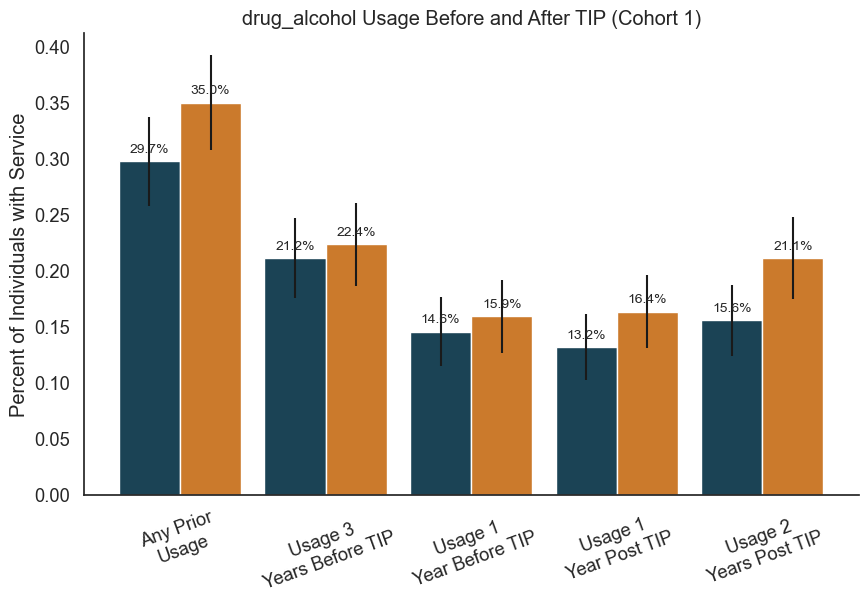

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



mental_health usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        182            224
1  Usage 3\nYears Before TIP        127            164
0   Usage 1\nYear Before TIP         87            117
3     Usage 1\nYear Post TIP        104            128
4    Usage 2\nYears Post TIP        119            149


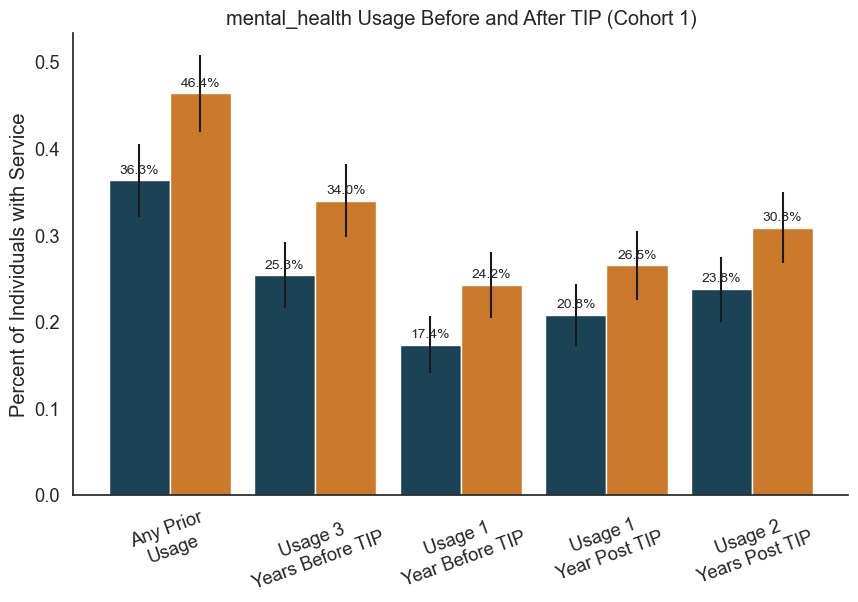

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



jail_collab usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        133            133
1  Usage 3\nYears Before TIP        117            115
0   Usage 1\nYear Before TIP         85             88
3     Usage 1\nYear Post TIP         62             82
4    Usage 2\nYears Post TIP         78            104


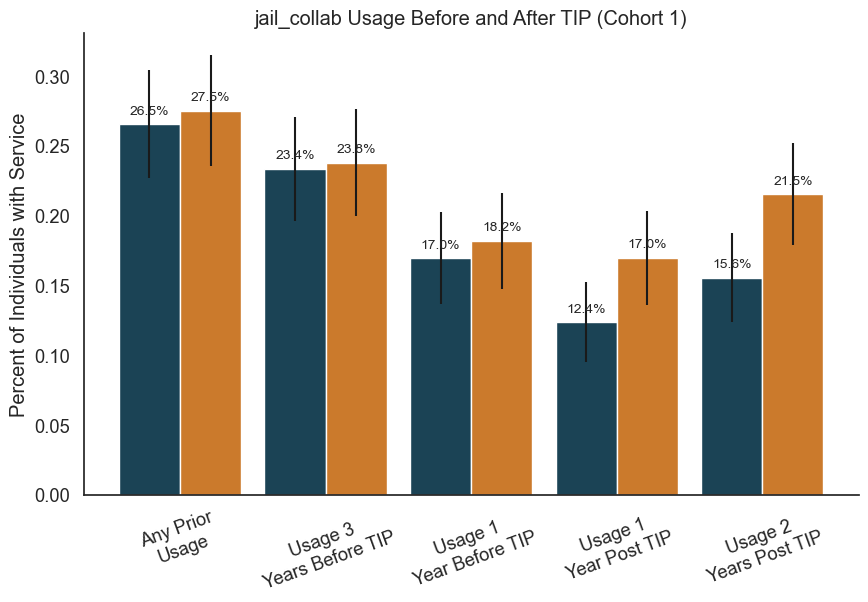

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



home_visiting usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage          3              3
1  Usage 3\nYears Before TIP          1              3
0   Usage 1\nYear Before TIP          0              3
3     Usage 1\nYear Post TIP          1              4
4    Usage 2\nYears Post TIP          1              5


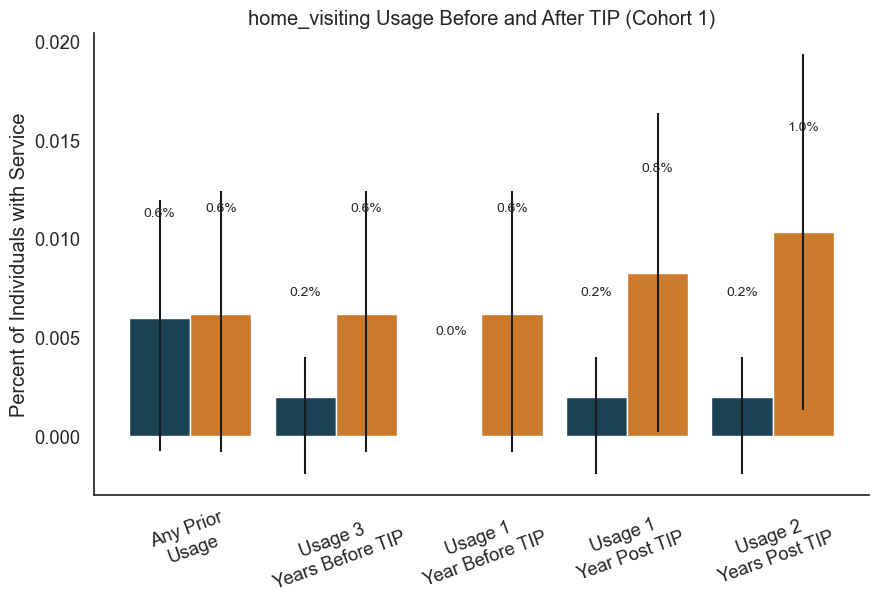

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



dhs_housing_supports usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         38             45
1  Usage 3\nYears Before TIP         21             30
0   Usage 1\nYear Before TIP          7             17
3     Usage 1\nYear Post TIP         23             29
4    Usage 2\nYears Post TIP         35             38


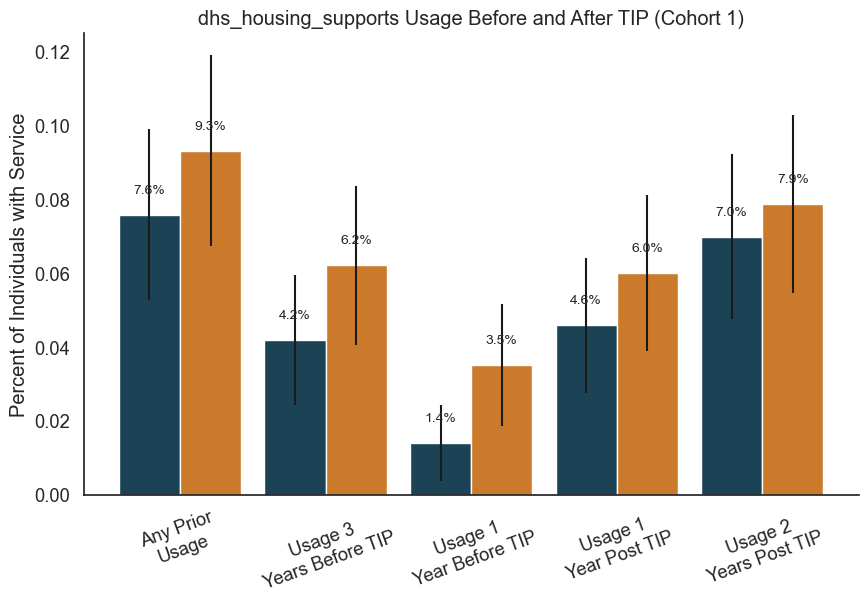

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



link_referral usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         21             28
1  Usage 3\nYears Before TIP         12             20
0   Usage 1\nYear Before TIP          4              6
3     Usage 1\nYear Post TIP          9             13
4    Usage 2\nYears Post TIP         13             19


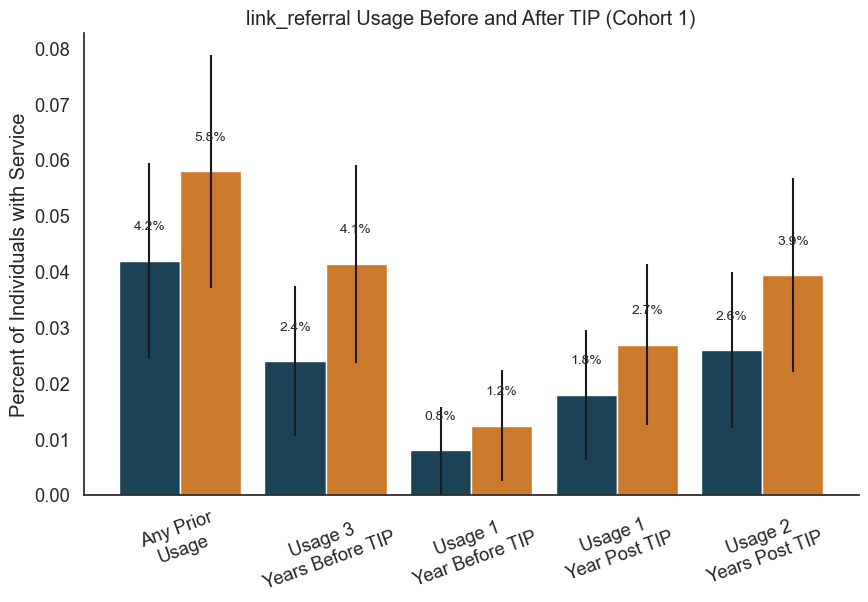

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



public_housing usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         25             31
1  Usage 3\nYears Before TIP         13             17
0   Usage 1\nYear Before TIP          9             12
3     Usage 1\nYear Post TIP         11             13
4    Usage 2\nYears Post TIP         11             14


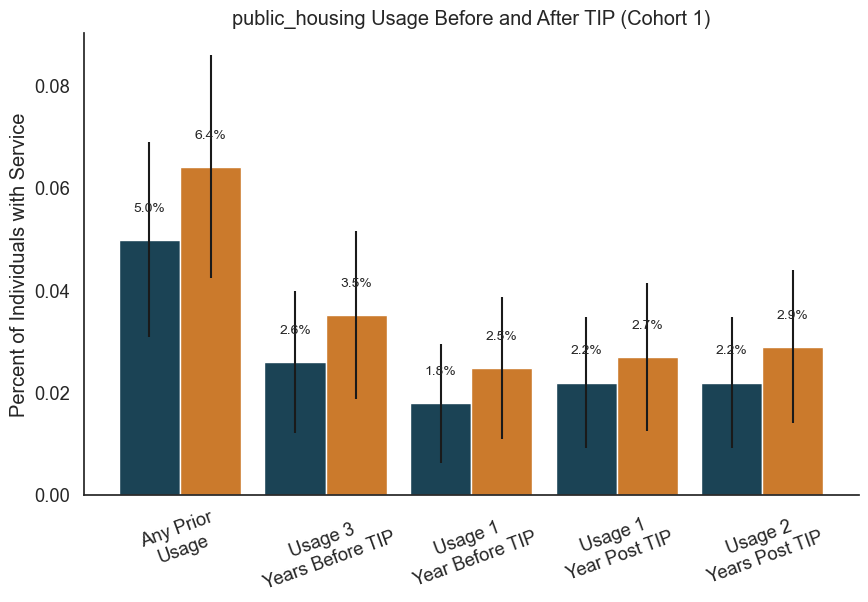

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



section8_housing usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         78             78
1  Usage 3\nYears Before TIP         40             42
0   Usage 1\nYear Before TIP         29             31
3     Usage 1\nYear Post TIP         26             29
4    Usage 2\nYears Post TIP         28             30


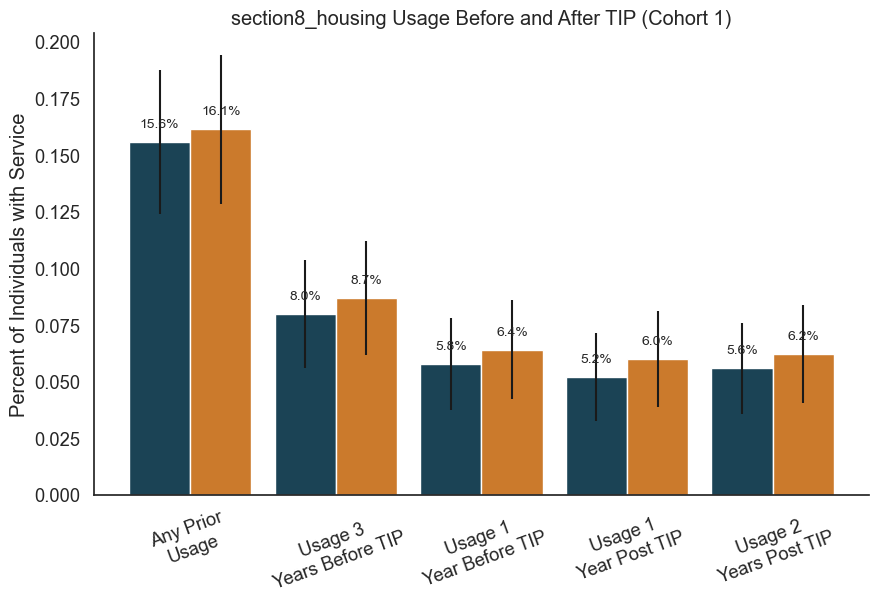

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



medicaid usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        326            348
1  Usage 3\nYears Before TIP        279            302
0   Usage 1\nYear Before TIP        237            265
3     Usage 1\nYear Post TIP        291            320
4    Usage 2\nYears Post TIP        320            338


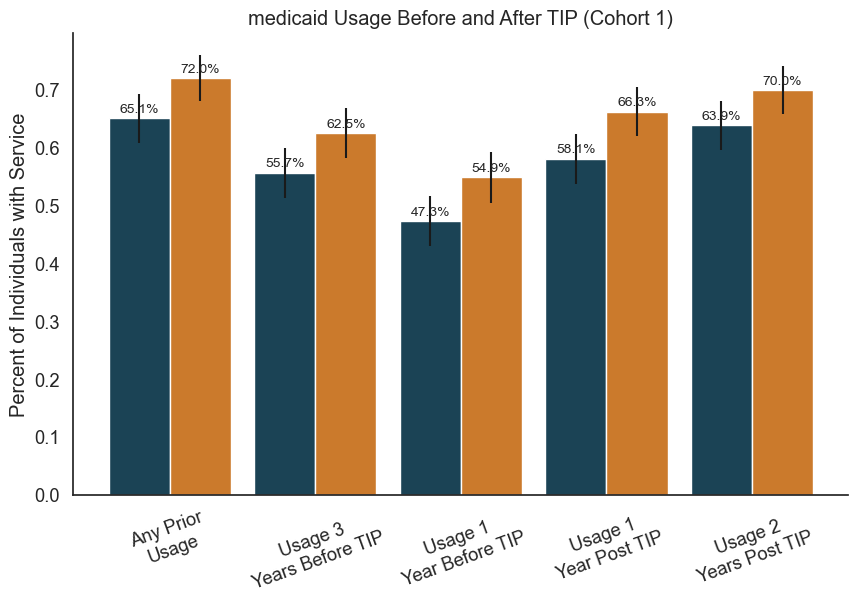

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



snap usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        142            157
1  Usage 3\nYears Before TIP        141            152
0   Usage 1\nYear Before TIP        122            121
3     Usage 1\nYear Post TIP        185            213
4    Usage 2\nYears Post TIP        215            247


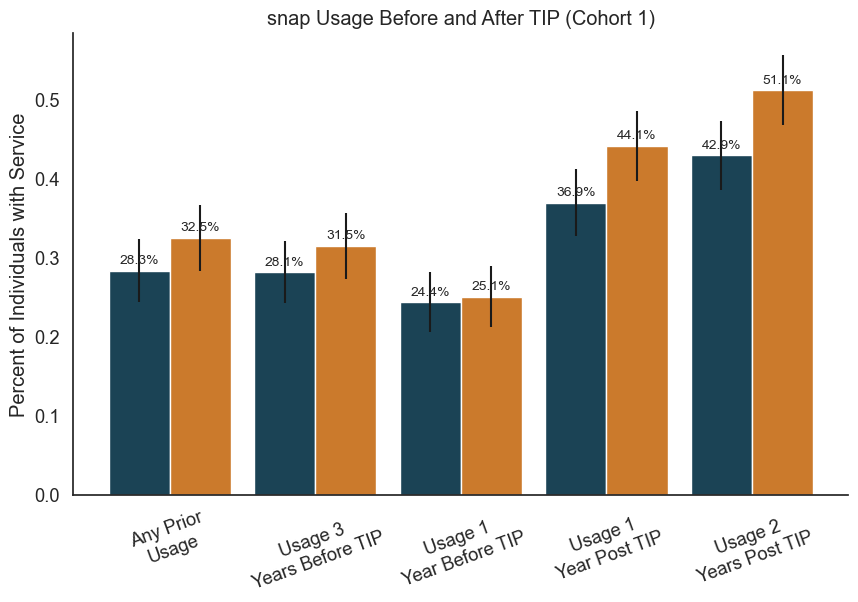

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



tanf usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         11             16
1  Usage 3\nYears Before TIP          9              8
0   Usage 1\nYear Before TIP          5              2
3     Usage 1\nYear Post TIP          4              9
4    Usage 2\nYears Post TIP          5             10


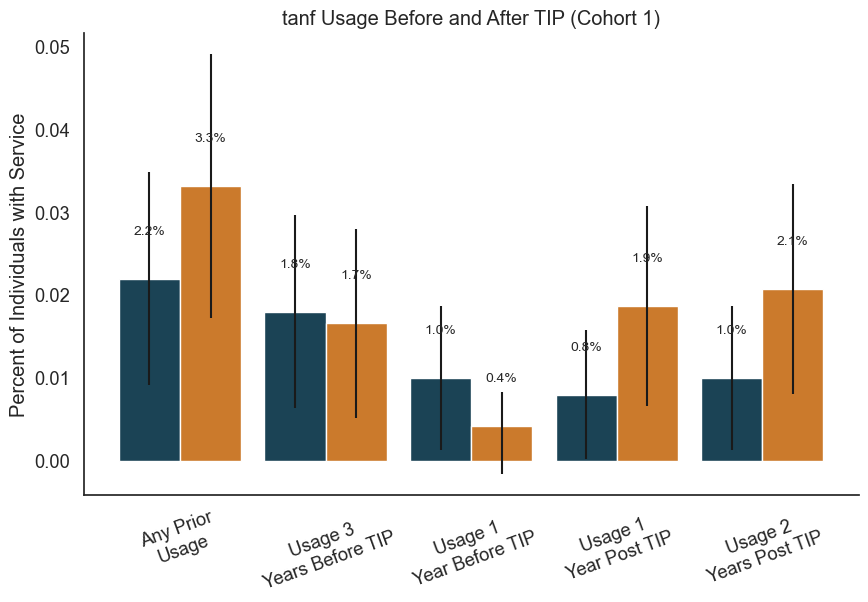

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



ssi usage counts (Cohort 1)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         17             28
1  Usage 3\nYears Before TIP         17             26
0   Usage 1\nYear Before TIP         12             21
3     Usage 1\nYear Post TIP         12             19
4    Usage 2\nYears Post TIP         14             23


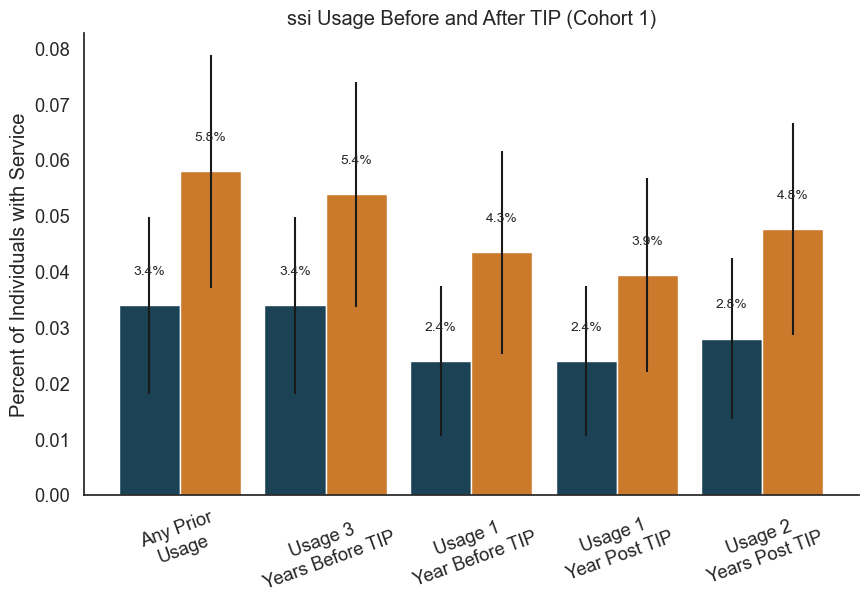

In [432]:
service_cols = [
    "drug_alcohol",
    "mental_health",
    "jail_collab",
    "home_visiting",
    "dhs_housing_supports",
    "link_referral",
    "public_housing",
    "section8_housing",
    "medicaid",
    "snap",
    "tanf",
    "ssi"
]

for service in service_cols:
    plot_service_usage(service, 1, df_services, df)


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



drug_alcohol usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         53             88
1  Usage 3\nYears Before TIP         28             53
0   Usage 1\nYear Before TIP         19             34
3     Usage 1\nYear Post TIP         10             23
4    Usage 2\nYears Post TIP         10             23


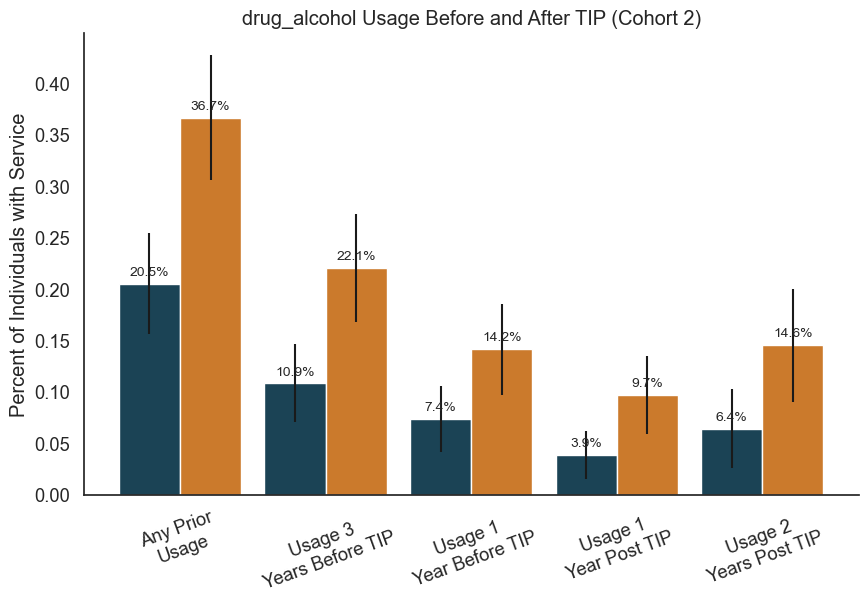

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



mental_health usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        111            154
1  Usage 3\nYears Before TIP         63             83
0   Usage 1\nYear Before TIP         44             49
3     Usage 1\nYear Post TIP         19             34
4    Usage 2\nYears Post TIP         19             34


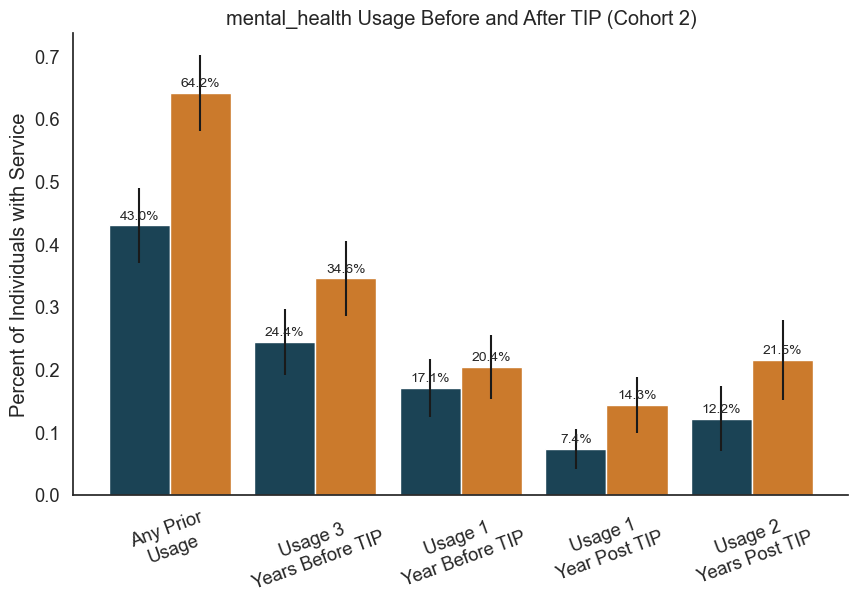

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



jail_collab usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         44             56
1  Usage 3\nYears Before TIP         24             29
0   Usage 1\nYear Before TIP         17             21
3     Usage 1\nYear Post TIP          4             15
4    Usage 2\nYears Post TIP          4             15


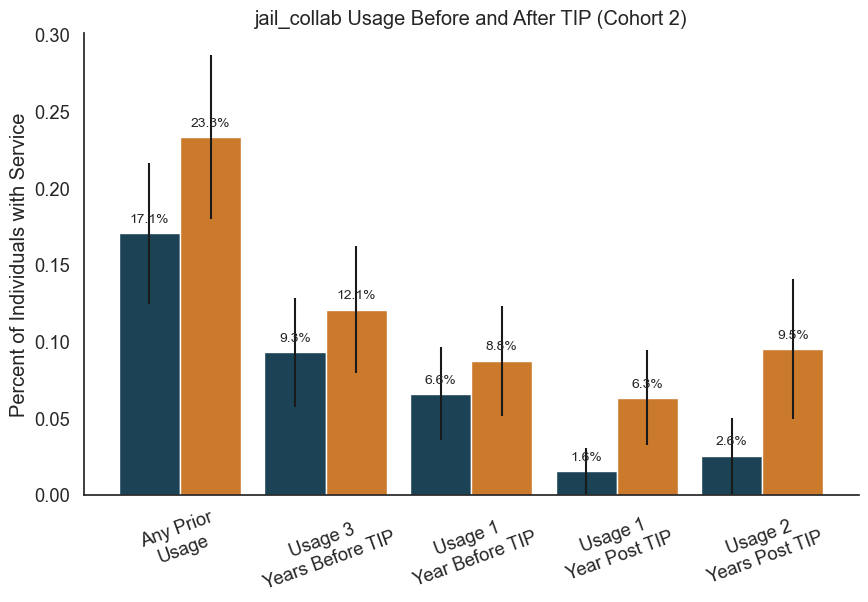

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



home_visiting usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         10              3
1  Usage 3\nYears Before TIP          6              2
0   Usage 1\nYear Before TIP          4              1
3     Usage 1\nYear Post TIP          2              1
4    Usage 2\nYears Post TIP          2              1


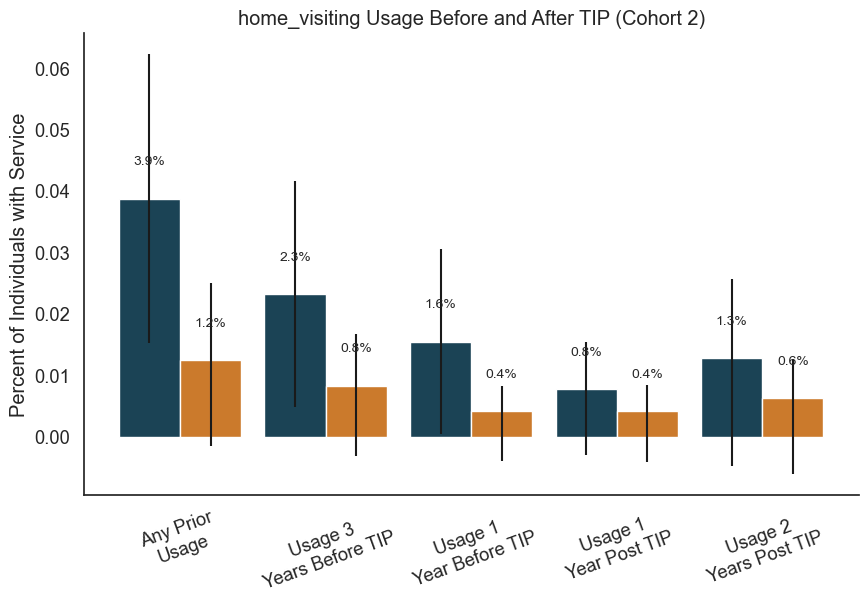

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



dhs_housing_supports usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         40             55
1  Usage 3\nYears Before TIP         22             28
0   Usage 1\nYear Before TIP          8             15
3     Usage 1\nYear Post TIP          3              8
4    Usage 2\nYears Post TIP          3              8


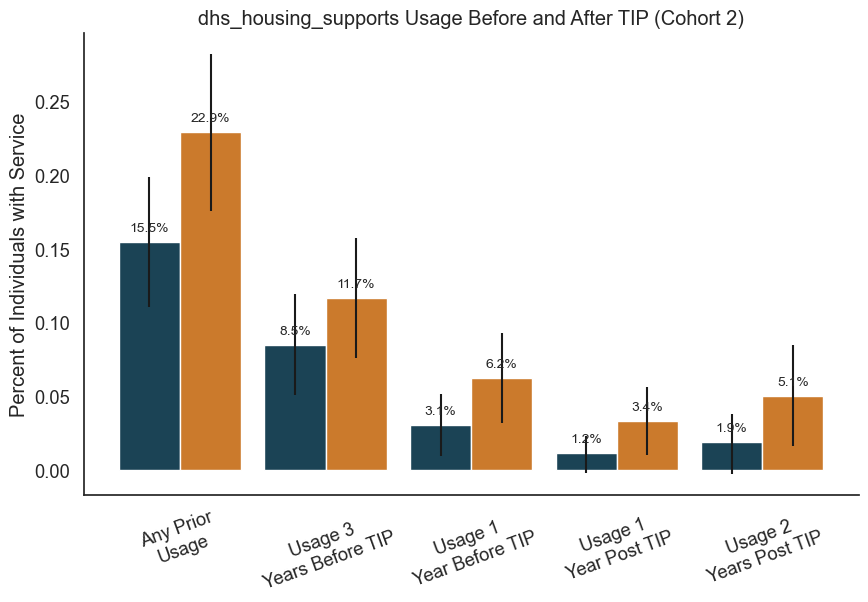

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



link_referral usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         31             39
1  Usage 3\nYears Before TIP         10             15
0   Usage 1\nYear Before TIP          3              8
3     Usage 1\nYear Post TIP          4             10
4    Usage 2\nYears Post TIP          4             10


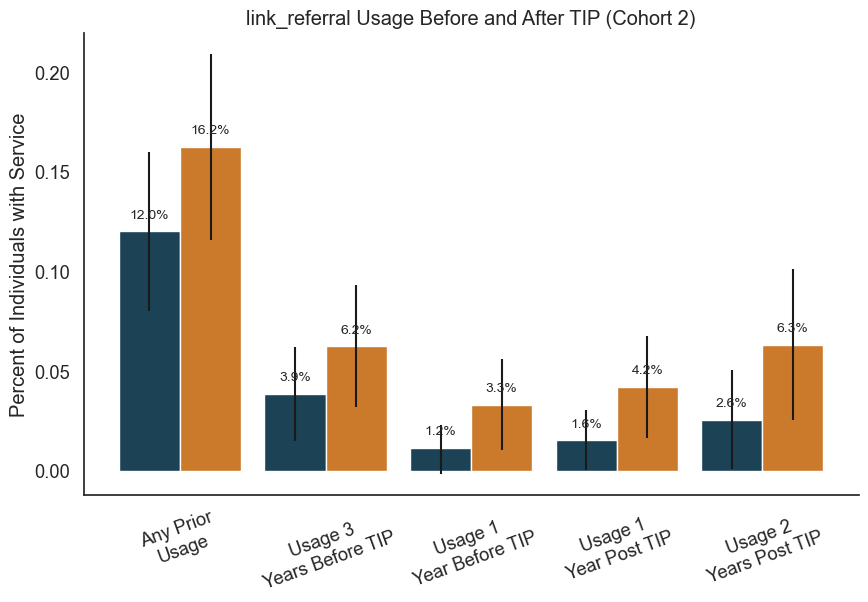

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



public_housing usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         28             26
1  Usage 3\nYears Before TIP         12              9
0   Usage 1\nYear Before TIP          8              5
3     Usage 1\nYear Post TIP          5              2
4    Usage 2\nYears Post TIP          5              2


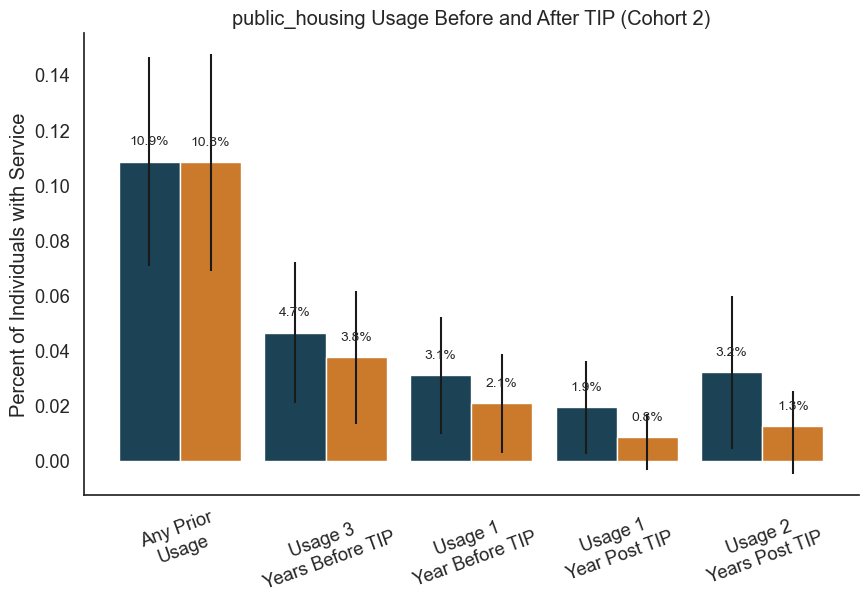

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



section8_housing usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         78             79
1  Usage 3\nYears Before TIP         31             23
0   Usage 1\nYear Before TIP         23             17
3     Usage 1\nYear Post TIP         13             10
4    Usage 2\nYears Post TIP         13             10


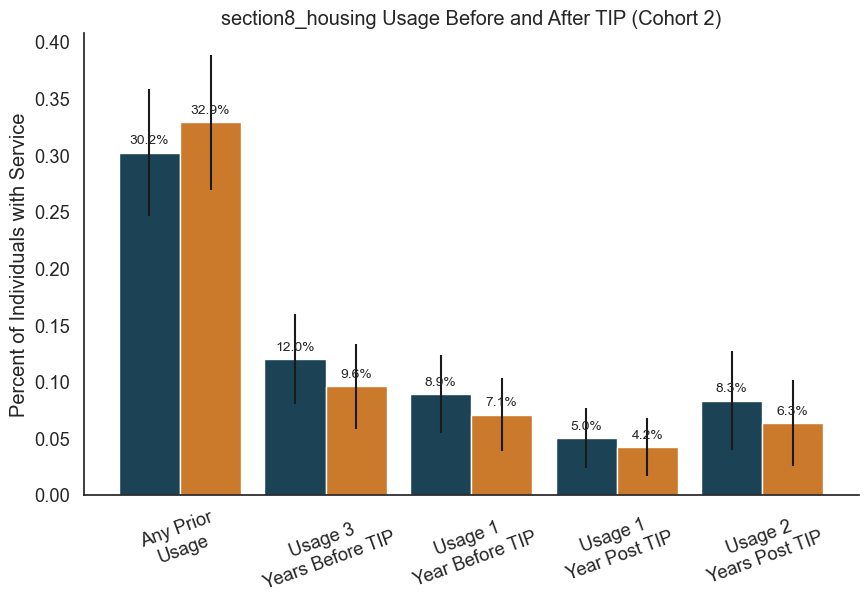

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



medicaid usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        219            214
1  Usage 3\nYears Before TIP        194            196
0   Usage 1\nYear Before TIP        182            190
3     Usage 1\nYear Post TIP        121            113
4    Usage 2\nYears Post TIP        121            113


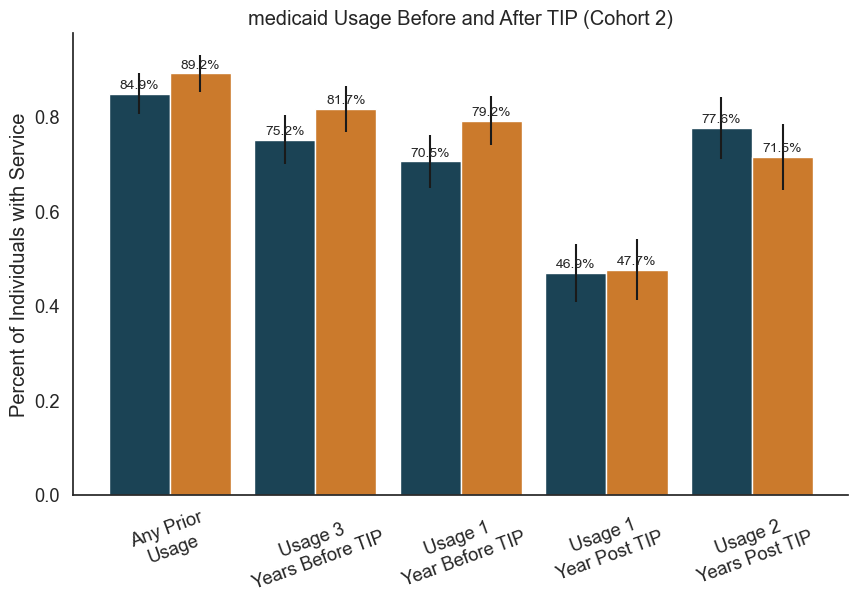

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



snap usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage        203            193
1  Usage 3\nYears Before TIP        174            169
0   Usage 1\nYear Before TIP        139            141
3     Usage 1\nYear Post TIP         86             88
4    Usage 2\nYears Post TIP         86             88


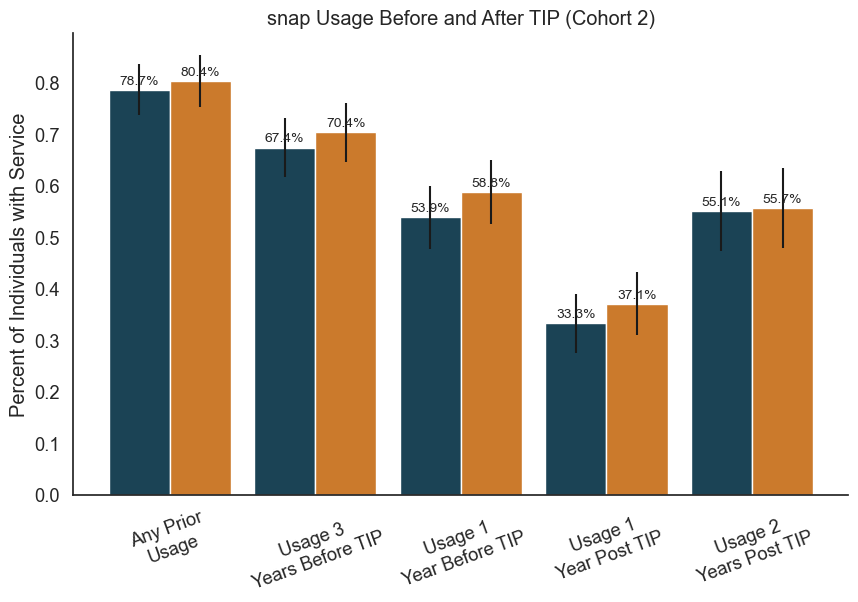

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



tanf usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         34             45
1  Usage 3\nYears Before TIP         15             18
0   Usage 1\nYear Before TIP          6              9
3     Usage 1\nYear Post TIP          0              1
4    Usage 2\nYears Post TIP          0              1


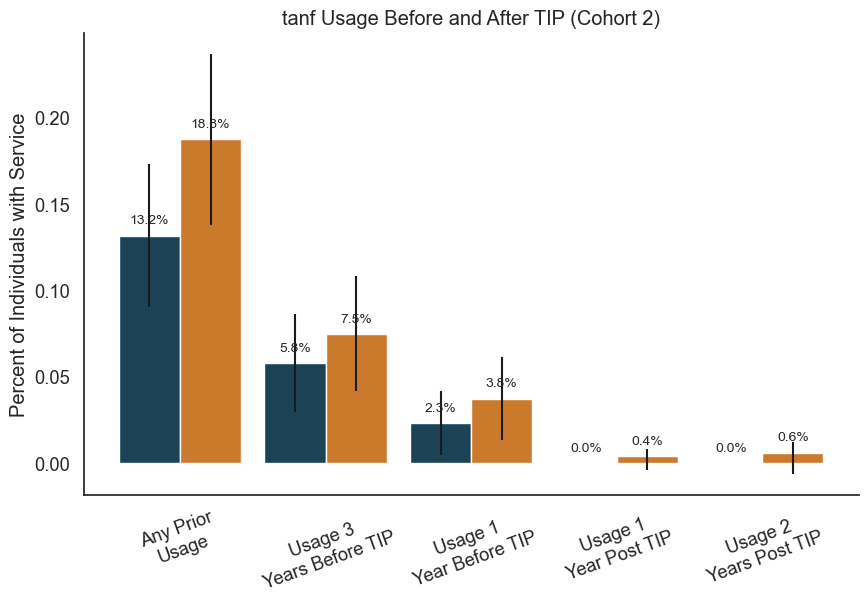

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\3224499610.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Status")["tip_id"]



ssi usage counts (Cohort 2)
                       label  Graduated  Non Graduated
2           Any Prior\nUsage         28             32
1  Usage 3\nYears Before TIP         20             18
0   Usage 1\nYear Before TIP         14             14
3     Usage 1\nYear Post TIP          7              5
4    Usage 2\nYears Post TIP          7              5


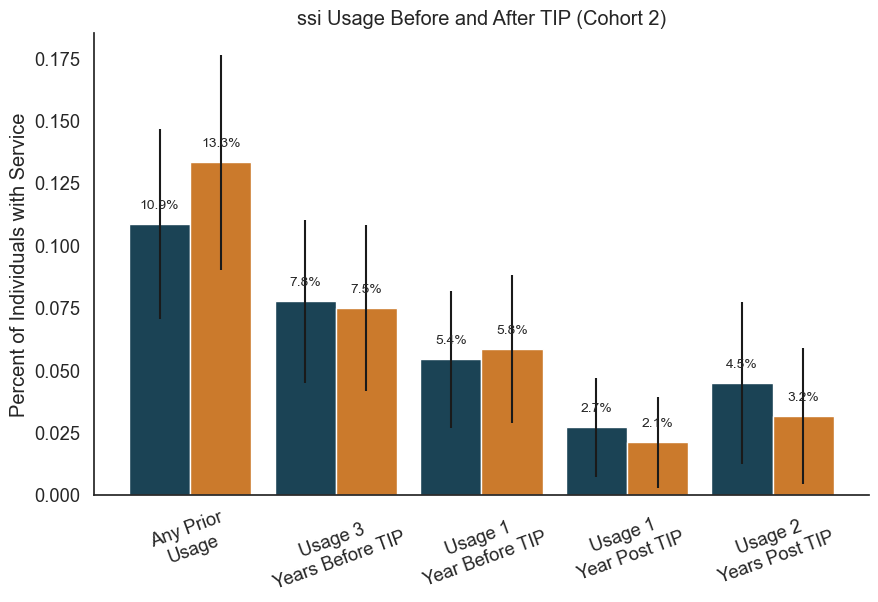

In [433]:
for service in service_cols:
    plot_service_usage(service, 2, df_services, df)

In [434]:
#set up ID list for employment analysis

ac_ss_records = df_services.copy()

ac_ss_records = ac_ss_records[ac_ss_records["any_one_plus_ui"] == 1]

ac_ss_records.head()

ac_ss_records = ac_ss_records.loc[:, ['tip_id', 'year'], ]

ac_ss_records.head()


,tip_id,year
0,1,2010
1,1,2011
2,1,2012
3,1,2013
4,1,2014


## Data cleaning of employment and earnings data, employment and earnings Descriptive Analysis

In [435]:
df_earnings = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_earn.csv')
df_inflation = pd.read_csv(r'C:\Users\sarah\Downloads\inflation_data.csv')

df_earnings["tip_id"].nunique()

C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\761999325.py:1: DtypeWarning: Columns (3,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_earnings = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_earn.csv')


2142

In [436]:
# process quarter to datetime
q_str = df_earnings["quarter"].astype(str).str.strip()

df_earnings["year"] = q_str.str[:4].astype(int)
df_earnings["qnum"] = q_str.str[-1].astype(int)  # 1-4

# map to calendar quarter end month/day
# Q1 -> 03/31
# Q2 -> 06/30
# Q3 -> 09/30
# Q4 -> 12/31 
month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

df_earnings["cal_end_year"] = df_earnings["year"]
df_earnings["cal_end_month"] = df_earnings["qnum"].map(month_map)
df_earnings["cal_end_day"] = df_earnings["qnum"].map(day_map)

df_earnings["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=df_earnings["cal_end_year"],
        month=df_earnings["cal_end_month"],
        day=df_earnings["cal_end_day"],
    ),
    errors="coerce",
)

df_earnings["year_month"] = df_earnings["year_quarter_dt"].dt.to_period("M")
df_earnings.drop(columns=["Unnamed: 0", "qnum", "cal_end_year", "cal_end_month", "cal_end_day"], errors="ignore", inplace=True)

In [437]:
df_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03


In [438]:
# adjust income data for inflation
df_inflation.drop(columns=['HALF1', 'HALF2'], inplace=True)
df_inflation = df_inflation.melt(id_vars='Year', var_name='Month', value_name='CPI')

month_map = {'Jan':'01','Feb':'02','Mar':'03','Apr':'04','May':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
df_inflation["year_month"] = (
    df_inflation["Year"].astype(str) + "-" + df_inflation["Month"].map(month_map)
)
# sort by date to ensure that the latest CPI value is at the end of the DataFrame
df_inflation = df_inflation.sort_values("year_month").reset_index(drop=True)
latest_cpi = df_inflation.loc[df_inflation["year_month"] == "2025-12", "CPI"].iloc[0]

df_earnings["year_month"] = df_earnings["year_month"].astype(str)

cpi_map = df_inflation.drop_duplicates("year_month").set_index("year_month")["CPI"]
df_earnings["CPI"] = df_earnings["year_month"].map(cpi_map)

df_earnings["adjusted_earnings"] = df_earnings["earnings"] * (latest_cpi / df_earnings["CPI"])

In [439]:
##NEW ADDITION TO MATCH 2025 METHODOLOGY: DROPPED ANYONE WITH NA IN EMPLOYER LEGAL NAME OR NAICS SUBSECTOR 2022
df_earnings = df_earnings.dropna(subset=['employer_legal_name', 'naics_subsector_2022']).reset_index(drop=True)
df_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month,CPI,adjusted_earnings
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06,251.989,1844.102068
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,4136.708548
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,6117.649056
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,2477.600167
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,9303.985951


In [440]:
df_e = df_earnings.merge(
    df[["tip_id", "StartDate", "StartYear", "Status", "cohort_2022"]],
    on="tip_id",
    how="left"
)

df_e["distance_from_TIP"] = df_e["year"] - df_e["StartYear"]

# pre/post per quarter
# StartDate <= year_quarter_dt -> post
# StartDate > year_quarter_dt -> pre
df_e["pre_post_q"] = np.where(
    df_e["StartDate"].isna() | df_e["year_quarter_dt"].isna(),
    "N/A",
    np.where(df_e["StartDate"] < df_e["year_quarter_dt"], "post", "pre")
)

df_e = df_e.dropna(subset=['Status']).reset_index(drop=True)
df_e.head()


,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,...,year_quarter_dt,year_month,CPI,adjusted_earnings,StartDate,StartYear,Status,cohort_2022,distance_from_TIP,pre_post_q
0,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,2017-12-31,2017-12,246.524,4136.708548,2017-05-08,2017.0,Graduated,1.0,0.0,post
1,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,2017-12-31,2017-12,246.524,6117.649056,2017-05-08,2017.0,Graduated,1.0,0.0,post
2,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,2018-03-31,2018-03,249.554,2477.600167,2017-05-08,2017.0,Graduated,1.0,1.0,post
3,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,2018-03-31,2018-03,249.554,9303.985951,2017-05-08,2017.0,Graduated,1.0,1.0,post
4,556,20181,GLUUTENY LLC,171,311811.0,Manufacturing,Food manufacturing,Retail Bakeries,Manufacturing,Food Manufacturing,...,2018-03-31,2018-03,249.554,222.049072,2017-05-08,2017.0,Graduated,1.0,1.0,post


In [441]:
#Narrow dataframe to just graduates and non graduates
df_e = df_e[(df_e['Status'] == 'Graduated') | (df_e['Status'] == 'Non Graduated')]

#Create a pre-TIP earnings data frame
df_e_pre = df_e[df_e['year_quarter_dt'] < df_e['StartDate']]
df_e_pre.reset_index(drop=True, inplace=True)

df_e_pre = df_e_pre.groupby(['tip_id', 'year'])['adjusted_earnings'].sum().reset_index()
df_e_pre = df_e_pre.groupby('tip_id', as_index=False)['adjusted_earnings'].mean()

df_e_pre = df_e_pre.rename(columns={'adjusted_earnings':'adjusted_earnings_pre'})

df_e_pre.head()

,tip_id,adjusted_earnings_pre
0,1,410.102835
1,10,186.657964
2,188,8646.938126
3,194,5383.010161
4,476,4599.655399


In [442]:
#Create the post-TIP earnings data frame
df_e_post = df_e[df_e['year_quarter_dt'] > df_e['StartDate']]
df_e_post.reset_index(drop=True, inplace=True)

df_e_post = df_e_post.groupby(['tip_id', 'year'])['adjusted_earnings'].sum().reset_index()
df_e_post = df_e_post.groupby('tip_id', as_index=False)['adjusted_earnings'].mean()

df_e_post = df_e_post.rename(columns={'adjusted_earnings':'adjusted_earnings_post'})

df_e_post.head()

,tip_id,adjusted_earnings_post
0,1,32685.431100
1,4,21128.303574
2,6,1299.286246
3,7,7552.271399
4,8,13784.671964


In [443]:
#Create a combined pre/post earnings data frame
df_e_combined = df_e.loc[:, ['tip_id', 'StartDate', 'StartYear', 'Status', 'cohort_2022'],].drop_duplicates(subset='tip_id')
df_e_combined.head()

df_e_combined = df_e_combined.merge(
    df_e_pre[["tip_id", "adjusted_earnings_pre"]],
    on="tip_id",
    how="left"
)

df_e_combined = df_e_combined.merge(
    df_e_post[["tip_id", "adjusted_earnings_post"]],
    on="tip_id",
    how="left"
)

df_e_combined.head()


,tip_id,StartDate,StartYear,Status,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post
0,556,2017-05-08,2017.0,Graduated,1.0,3126.217727,33001.142203
1,2060,2024-05-28,2024.0,Graduated,2.0,6460.536940,NaN
2,1219,2020-11-16,2020.0,Non Graduated,1.0,18451.301659,5580.421312
3,715,2018-03-19,2018.0,Graduated,1.0,2806.441929,10328.713850
4,2252,2024-12-09,2024.0,Non Graduated,2.0,6012.192904,NaN


In [444]:
earn_change = df_e_combined.dropna(subset=['adjusted_earnings_pre', 'adjusted_earnings_post']).reset_index(drop=True)
earn_change.head()

,tip_id,StartDate,StartYear,Status,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post
0,556,2017-05-08,2017.0,Graduated,1.0,3126.217727,33001.142203
1,1219,2020-11-16,2020.0,Non Graduated,1.0,18451.301659,5580.421312
2,715,2018-03-19,2018.0,Graduated,1.0,2806.441929,10328.713850
3,572,2017-06-13,2017.0,Non Graduated,1.0,586.165824,6139.682419
4,966,2019-06-17,2019.0,Graduated,1.0,2899.808190,7192.706856


In [445]:
earn_change['delta'] = earn_change['adjusted_earnings_post'] - earn_change['adjusted_earnings_pre']
earn_change.head()

,tip_id,StartDate,StartYear,Status,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
0,556,2017-05-08,2017.0,Graduated,1.0,3126.217727,33001.142203,29874.924476
1,1219,2020-11-16,2020.0,Non Graduated,1.0,18451.301659,5580.421312,-12870.880347
2,715,2018-03-19,2018.0,Graduated,1.0,2806.441929,10328.713850,7522.271921
3,572,2017-06-13,2017.0,Non Graduated,1.0,586.165824,6139.682419,5553.516596
4,966,2019-06-17,2019.0,Graduated,1.0,2899.808190,7192.706856,4292.898666


In [446]:
# define employment status based on whether tip_id exists in df_earnings
#def has_employment(tip_id):
 #   return tip_id in df_earnings['tip_id'].unique()

#df['has_employment'] = df['tip_id'].apply(has_employment)

In [447]:
df_grad_earn = df_e_combined[df_e_combined["Status"] == "Graduated"].copy()
df_non_grad_earn = df_e_combined[df_e_combined["Status"] == "Non Graduated"].copy()
df_grad_earn.head()

,tip_id,StartDate,StartYear,Status,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post
0,556,2017-05-08,2017.0,Graduated,1.0,3126.217727,33001.142203
1,2060,2024-05-28,2024.0,Graduated,2.0,6460.536940,NaN
3,715,2018-03-19,2018.0,Graduated,1.0,2806.441929,10328.713850
6,966,2019-06-17,2019.0,Graduated,1.0,2899.808190,7192.706856
7,274,2015-07-08,2015.0,Graduated,1.0,NaN,14239.960047


In [448]:
for name, target_df in [("Graduated", df_grad_earn), ("Non Graduated", df_non_grad_earn)]:
    print("\n" + "=" * 30)
    print(f"{name}: pre-TIP annual earnings (earnings_pre)")
    print("=" * 30)

    s = pd.to_numeric(target_df["adjusted_earnings_pre"], errors="coerce").dropna()

    stats = pd.Series(
        {
            "N (non-missing)": int(s.shape[0]),
            "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
            "Median": round(s.median(), 2) if s.shape[0] else np.nan,
        }
    )
    print(stats)


Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)      404.00
Mean               10015.82
Median              7066.74
dtype: float64

Non Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)     401.00
Mean               7725.60
Median             4685.65
dtype: float64


In [449]:
df_grad_c1 = df_grad_earn[df_grad_earn["cohort_2022"] == 1].copy()
df_nongrad_c1 = df_non_grad_earn[df_non_grad_earn["cohort_2022"] == 1].copy()

print("\n" + "#" * 40)
print("PRE-2022 COHORT")
print("#" * 40)

for name, target_df in [("Graduated", df_grad_c1), ("Non Graduated", df_nongrad_c1)]:
    print("\n" + "=" * 30)
    print(f"{name}: pre-TIP annual earnings (earnings_pre)")
    print("=" * 30)

    s = pd.to_numeric(target_df["adjusted_earnings_pre"], errors="coerce").dropna()

    stats = pd.Series(
        {
            "N (non-missing)": int(s.shape[0]),
            "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
            "Median": round(s.median(), 2) if s.shape[0] else np.nan,
        }
    )
    print(stats)


########################################
PRE-2022 COHORT
########################################

Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)     189.00
Mean               9063.19
Median             5848.36
dtype: float64

Non Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)     200.00
Mean               7929.47
Median             4365.76
dtype: float64


In [450]:
print("\n" + "#" * 40)
print("PRE-2022 COHORT")
print("#" * 40)

for name, target_df in [("Graduated", df_grad_c1), ("Non Graduated", df_nongrad_c1)]:
    print("\n" + "=" * 30)
    print(f"{name}: post-TIP annual earnings (earnings_pre)")
    print("=" * 30)

    s = pd.to_numeric(target_df["adjusted_earnings_post"], errors="coerce").dropna()

    stats = pd.Series(
        {
            "N (non-missing)": int(s.shape[0]),
            "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
            "Median": round(s.median(), 2) if s.shape[0] else np.nan,
        }
    )
    print(stats)


########################################
PRE-2022 COHORT
########################################

Graduated: post-TIP annual earnings (earnings_pre)
N (non-missing)      451.00
Mean               18202.53
Median             15099.68
dtype: float64

Non Graduated: post-TIP annual earnings (earnings_pre)
N (non-missing)      416.00
Mean               15059.41
Median             10472.18
dtype: float64


In [451]:
df_grad_c2 = df_grad_earn[df_grad_earn["cohort_2022"] == 2].copy()
df_nongrad_c2 = df_non_grad_earn[df_non_grad_earn["cohort_2022"] == 2].copy()

print("\n" + "#" * 40)
print("POST-2022 COHORT")
print("#" * 40)

for name, target_df in [("Graduated", df_grad_c2), ("Non Graduated", df_nongrad_c2)]:
    print("\n" + "=" * 30)
    print(f"{name}: pre-TIP annual earnings (earnings_pre)")
    print("=" * 30)

    s = pd.to_numeric(target_df["adjusted_earnings_pre"], errors="coerce").dropna()

    stats = pd.Series(
        {
            "N (non-missing)": int(s.shape[0]),
            "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
            "Median": round(s.median(), 2) if s.shape[0] else np.nan,
        }
    )
    print(stats)


########################################
POST-2022 COHORT
########################################

Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)      215.00
Mean               10853.25
Median              8188.99
dtype: float64

Non Graduated: pre-TIP annual earnings (earnings_pre)
N (non-missing)     201.00
Mean               7522.73
Median             5009.21
dtype: float64


In [452]:
print("\n" + "#" * 40)
print("POST-2022 COHORT")
print("#" * 40)

for name, target_df in [("Graduated", df_grad_c2), ("Non Graduated", df_nongrad_c2)]:
    print("\n" + "=" * 30)
    print(f"{name}: post-TIP annual earnings (earnings_pre)")
    print("=" * 30)

    s = pd.to_numeric(target_df["adjusted_earnings_post"], errors="coerce").dropna()

    stats = pd.Series(
        {
            "N (non-missing)": int(s.shape[0]),
            "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
            "Median": round(s.median(), 2) if s.shape[0] else np.nan,
        }
    )
    print(stats)


########################################
POST-2022 COHORT
########################################

Graduated: post-TIP annual earnings (earnings_pre)
N (non-missing)      202.00
Mean               14553.07
Median             11247.34
dtype: float64

Non Graduated: post-TIP annual earnings (earnings_pre)
N (non-missing)     164.00
Mean               8682.63
Median             5918.85
dtype: float64


In [453]:
summary = []

for cohort, label in [(1, "Pre-2022"), (2, "Post-2022")]:
    subset = df_e_combined[df_e_combined["cohort_2022"] == cohort]
    s = pd.to_numeric(subset["adjusted_earnings_pre"], errors="coerce").dropna()
    
    summary.append({
        "Cohort": label,
        "N (non-missing)": int(s.shape[0]),
        "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
        "Median": round(s.median(), 2) if s.shape[0] else np.nan
    })

summary_df = pd.DataFrame(summary)
summary_df

,Cohort,N (non-missing),Mean,Median
0,Pre-2022,389,8480.30,5237.08
1,Post-2022,416,9244.03,6617.43


In [454]:
summary = []

for cohort, label in [(1, "Pre-2022"), (2, "Post-2022")]:
    subset = df_e_combined[df_e_combined["cohort_2022"] == cohort]
    s = pd.to_numeric(subset["adjusted_earnings_post"], errors="coerce").dropna()
    
    summary.append({
        "Cohort": label,
        "N (non-missing)": int(s.shape[0]),
        "Mean": round(s.mean(), 2) if s.shape[0] else np.nan,
        "Median": round(s.median(), 2) if s.shape[0] else np.nan
    })

summary_df = pd.DataFrame(summary)
summary_df

,Cohort,N (non-missing),Mean,Median
0,Pre-2022,867,16694.41,13058.42
1,Post-2022,366,11922.60,9025.43


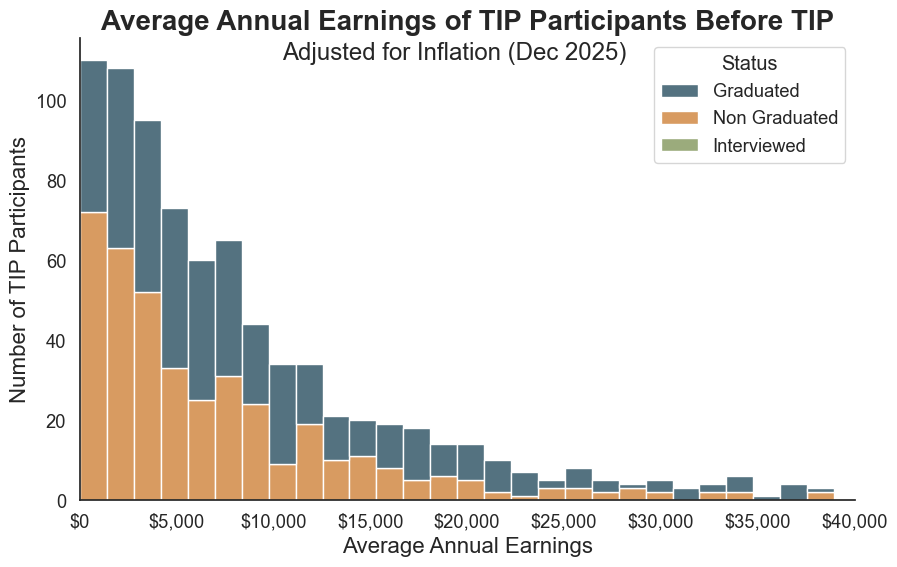

In [455]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
        (df_e_combined["adjusted_earnings_pre"] > 0) & (df_e_combined["adjusted_earnings_pre"] < 40000)
    ],
    x="adjusted_earnings_pre",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of TIP Participants Before TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

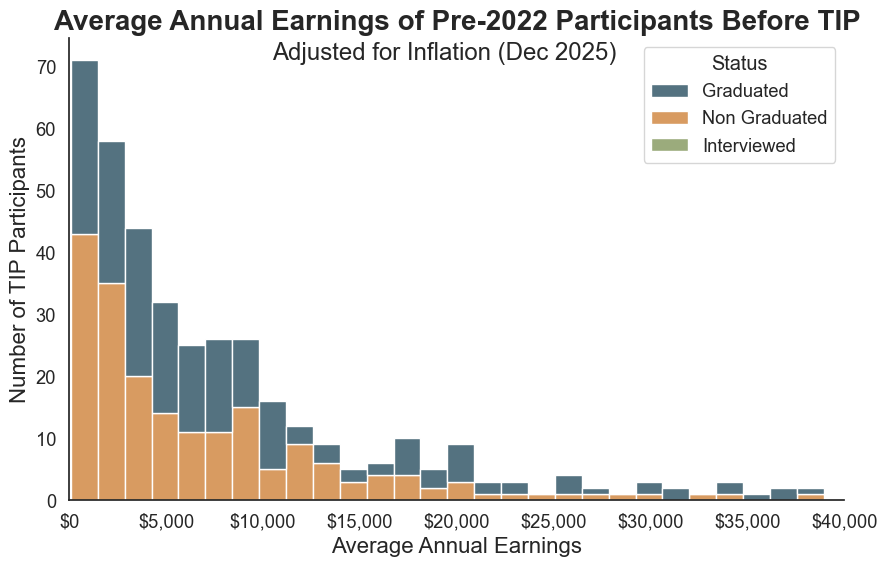

In [456]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
        (df_e_combined["cohort_2022"] == 1) & (df_e_combined["adjusted_earnings_pre"] > 0) & (df_e_combined["adjusted_earnings_pre"] < 40000)
    ],
    x="adjusted_earnings_pre",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of Pre-2022 Participants Before TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

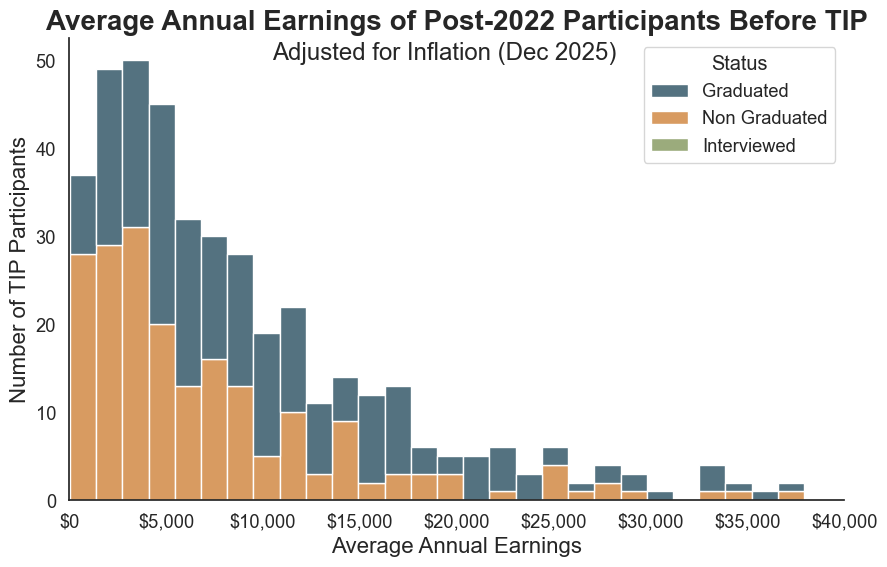

In [457]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
        (df_e_combined["cohort_2022"] == 2) & (df_e_combined["adjusted_earnings_pre"] > 0) & (df_e_combined["adjusted_earnings_pre"] < 40000)
    ],
    x="adjusted_earnings_pre",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of Post-2022 Participants Before TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

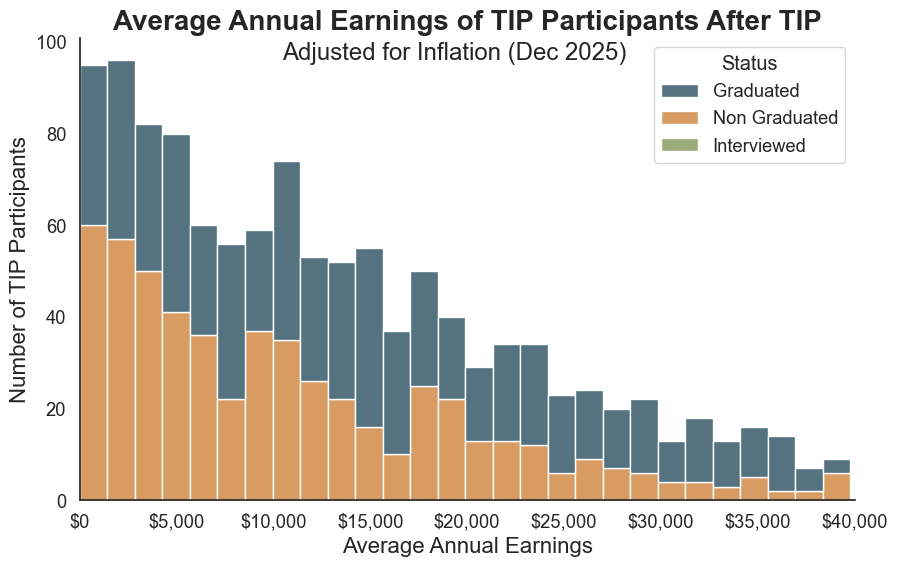

In [458]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
        (df_e_combined["adjusted_earnings_post"] > 0) & (df_e_combined["adjusted_earnings_post"] < 40000)
    ],
    x="adjusted_earnings_post",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of TIP Participants After TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

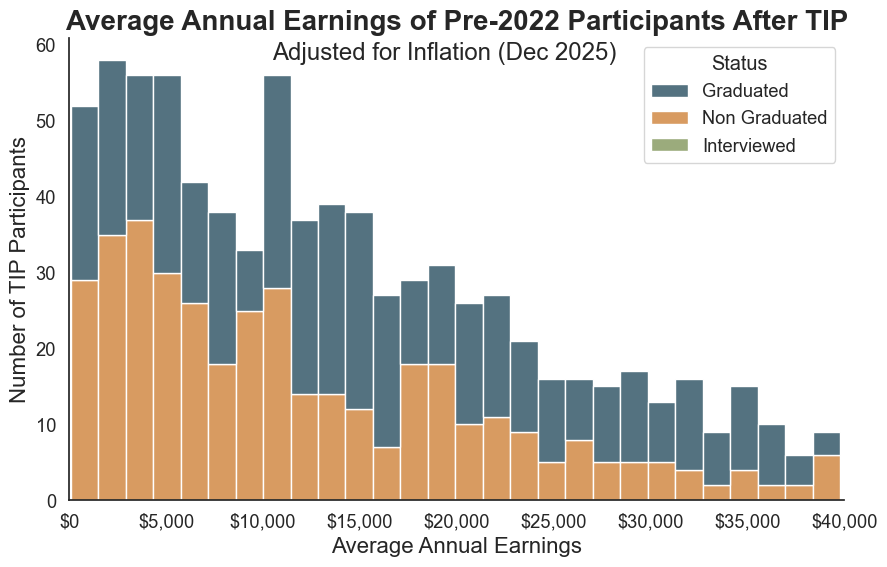

In [459]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
        (df_e_combined["cohort_2022"] == 1) &
        (df_e_combined["adjusted_earnings_post"] > 0) & (df_e_combined["adjusted_earnings_post"] < 40000)
    ],
    x="adjusted_earnings_post",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of Pre-2022 Participants After TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

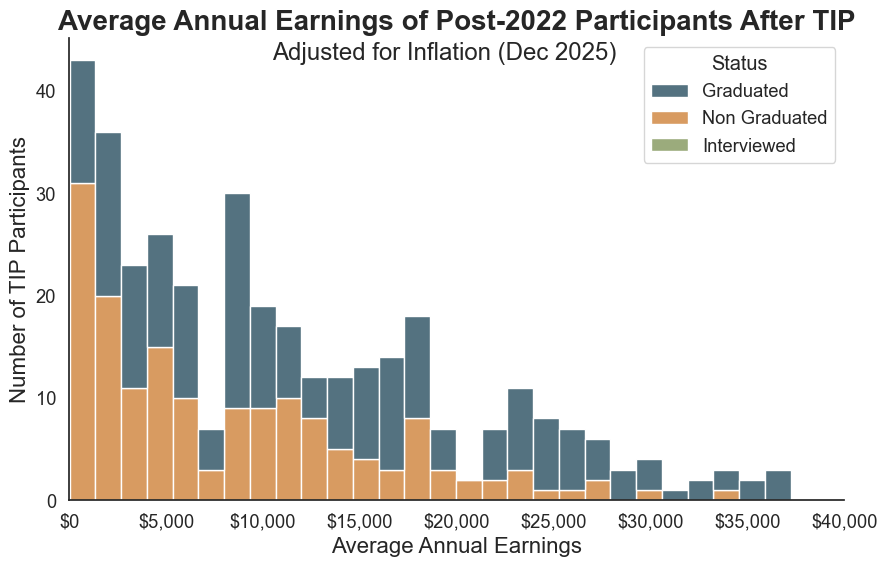

In [460]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df_e_combined[
         (df_e_combined["cohort_2022"] == 2) &
        (df_e_combined["adjusted_earnings_post"] > 0) & (df_e_combined["adjusted_earnings_post"] < 40000)
    ],
    x="adjusted_earnings_post",
    bins=28,
    hue="Status",
    multiple="stack"
)

sns.despine()
plt.xlim(0, 40000)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.ylabel("Number of TIP Participants", fontdict={"fontsize": 16})
plt.xlabel("Average Annual Earnings", fontdict={"fontsize": 16})
plt.title(
    "Average Annual Earnings of Post-2022 Participants After TIP",
    fontdict={"fontsize": 20, "fontweight": "semibold"}
)
plt.suptitle("Adjusted for Inflation (Dec 2025)", fontdict={"fontsize": 14}, y=0.875)

plt.show()

In [461]:
df_earnings.columns

Index(['tip_id', 'quarter', 'employer_legal_name', 'earnings', 'naics_code',
       'naics_sector_2017', 'naics_subsector_2017', 'naics_industry_2017',
       'naics_sector_2022', 'naics_subsector_2022', 'naics_industry_2022',
       'year', 'year_quarter_dt', 'year_month', 'CPI', 'adjusted_earnings'],
      dtype='object')

In [462]:
e = df_earnings.merge(
    df[["tip_id", "StartDate", "ValidYears", "Status", 'ValidYearsPre']],
    on="tip_id",
    how="left"
)

# keep only Graduated / Non Graduated
e = e[e["Status"].isin(["Graduated", "Non Graduated"])].copy()


e["YearsSinceTIP"] = (e["year_quarter_dt"] - e["StartDate"]).dt.days / 365.25

# "employment in quarter" indicator: has employer legal name in that quarter
e["employed_quarter"] = e["employer_legal_name"].notna() & (e["employer_legal_name"].astype(str).str.strip() != "")

# integer bin for pre buckets: >0 -> ceil, <0 -> floor, 0 -> 0
y = e["YearsSinceTIP"]
e["YearsSinceTIP_int"] = np.where(y > 0, np.ceil(y), np.where(y < 0, np.floor(y), 0)).astype(int)

e.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,...,year_month,CPI,adjusted_earnings,StartDate,ValidYears,Status,ValidYearsPre,YearsSinceTIP,employed_quarter,YearsSinceTIP_int
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,2017-12,246.524,4136.708548,2017-05-08,8.569473,Graduated,-0.347707,0.648871,True,1
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,2017-12,246.524,6117.649056,2017-05-08,8.569473,Graduated,-0.347707,0.648871,True,1
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,2018-03,249.554,2477.600167,2017-05-08,8.569473,Graduated,-0.347707,0.895277,True,1
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,2018-03,249.554,9303.985951,2017-05-08,8.569473,Graduated,-0.347707,0.895277,True,1
5,556,20181,GLUUTENY LLC,171,311811.0,Manufacturing,Food manufacturing,Retail Bakeries,Manufacturing,Food Manufacturing,...,2018-03,249.554,222.049072,2017-05-08,8.569473,Graduated,-0.347707,0.895277,True,1


In [463]:
# extract year from quarter date
e['year'] = e['year_quarter_dt'].dt.year

# aggregate to tip_id + year level
e_yearly = (
    e.groupby(['tip_id', 'year'])
     .agg(
         employed_year=('employed_quarter', 'any'),  
         Status=('Status', 'first'),               
         StartDate=('StartDate', 'first'),
         ValidYears=('ValidYears', 'first'),
         ValidYearsPre=('ValidYearsPre', 'first')
     )
     .reset_index()
)

e_yearly.head()

,tip_id,year,employed_year,Status,StartDate,ValidYears,ValidYearsPre
0,1,2017,True,Non Graduated,2018-07-12,7.540041,-1.524983
1,1,2018,True,Non Graduated,2018-07-12,7.540041,-1.524983
2,1,2019,True,Non Graduated,2018-07-12,7.540041,-1.524983
3,1,2020,True,Non Graduated,2018-07-12,7.540041,-1.524983
4,1,2021,True,Non Graduated,2018-07-12,7.540041,-1.524983


In [464]:
e_yearly = e_yearly[e_yearly["employed_year"] == True]

e_yearly_yes = e_yearly.loc[:, ['tip_id', 'year'], ]

ac_records = ac_ss_records.merge(
    e_yearly_yes[["tip_id", "year"]],
    on=["tip_id", "year"],
    how="outer"
)

ac_records.head()

ac_records = ac_records.merge(
    df[["tip_id", "ValidYears", "ValidYearsPre", "Status", "StartDate", "cohort_2022"]],
    on = ["tip_id"],
    how = "left"
)

ac_records.head()

,tip_id,year,ValidYears,ValidYearsPre,Status,StartDate,cohort_2022
0,1,2010,7.540041,-1.524983,Non Graduated,2018-07-12,1.0
1,1,2011,7.540041,-1.524983,Non Graduated,2018-07-12,1.0
2,1,2012,7.540041,-1.524983,Non Graduated,2018-07-12,1.0
3,1,2013,7.540041,-1.524983,Non Graduated,2018-07-12,1.0
4,1,2014,7.540041,-1.524983,Non Graduated,2018-07-12,1.0


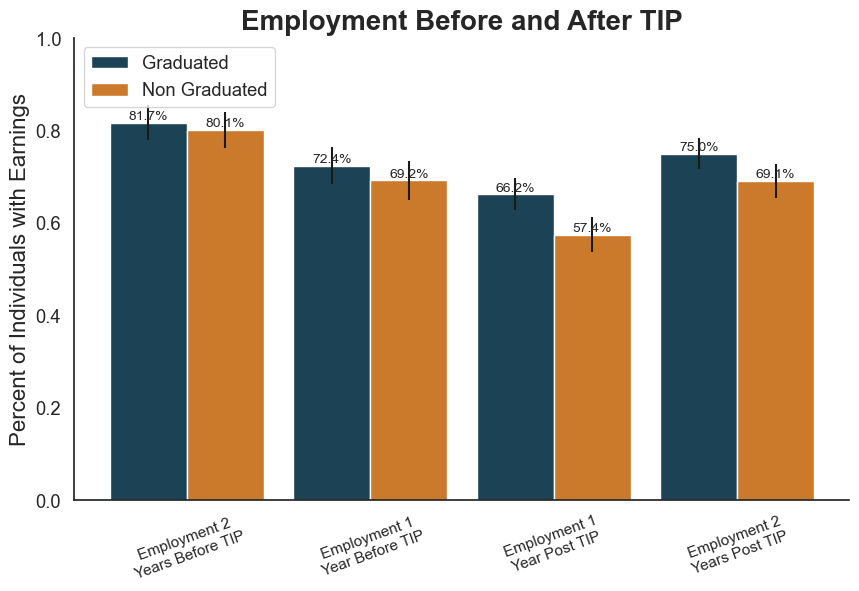

In [465]:

# -----------------------------
# 2) PRE: bins (cumulative)
# -----------------------------
pre_points = [-1, -2]
rows = []
for i in pre_points:
    cur = e[(e["YearsSinceTIP"] < 0) & (e["YearsSinceTIP"] >= i) & (e["ValidYearsPre"] <= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = (cur.loc[(cur["Status"] == status) & (cur["employed_quarter"])]
       ["tip_id"]
       .nunique())
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYearsPre"] <= i), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

pre_df = pd.DataFrame(rows)

# -----------------------------
# 3) POST: cumulative windows [0, i) for i = 1,3,5 and require ValidYears > i
# -----------------------------
post_points = [1, 2]
rows = []

for i in post_points:
    cur = e[(e["YearsSinceTIP"] >= 0) & (e["YearsSinceTIP"] < i) & (e["ValidYears"] > i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = ( cur.loc[(cur["Status"] == status) & (cur["employed_quarter"])]
       ["tip_id"]
       .nunique())
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYears"] > i), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
# 4) assemble 6 categories + plot
# -----------------------------
label_map = {
    -2:  "Employment 2\nYears Before TIP",
    -1:  "Employment 1\nYear Before TIP",
     1:  "Employment 1\nYear Post TIP",
     2:  "Employment 2\nYears Post TIP"
}

order = [-2, -1, 1, 2]

pre_keep = pre_df[pre_df["YearsSinceTIP"].isin([-2, -1])].copy()

data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = pd.to_numeric(data["YearsSinceTIP"])

data["YearsSinceTIP"] = pd.Categorical(
    data["YearsSinceTIP"],
    categories=order,
    ordered=True
)

data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


data["label"] = data["YearsSinceTIP"].map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Employment Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Earnings", fontdict={"fontsize": 16})
plt.ylim(0, 1.0)
plt.legend(loc="upper left")
plt.show()


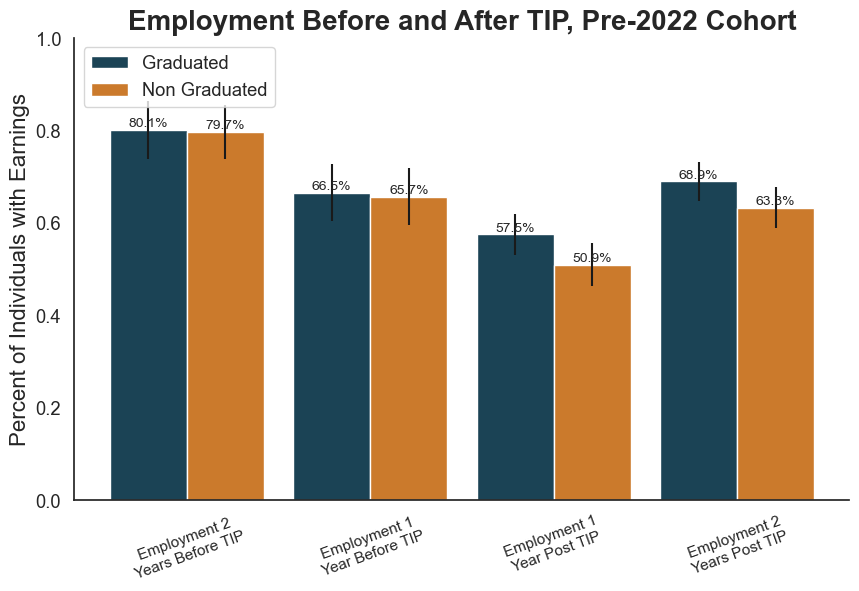

In [466]:
# -----------------------------
# 0) join Status / StartDate / ValidYears onto df_earnings
# -----------------------------
e = df_earnings.merge(
    df[["tip_id", "StartDate", "ValidYears", "Status", "cohort_2022", "ValidYearsPre"]],
    on="tip_id",
    how="left"
)

# keep only Graduated / Non Graduated, cohort 1
e = e[(e["Status"].isin(["Graduated", "Non Graduated"])) & (e["cohort_2022"] ==1)].copy()

# -----------------------------
# 1) YearsSinceTIP (in years) using quarter end date
# -----------------------------
e["YearsSinceTIP"] = (e["year_quarter_dt"] - e["StartDate"]).dt.days / 365.25

# "employment in quarter" indicator: has employer legal name in that quarter
e["employed_quarter"] = e["employer_legal_name"].notna() & (e["employer_legal_name"].astype(str).str.strip() != "")

# integer bin for pre buckets: >0 -> ceil, <0 -> floor, 0 -> 0
y = e["YearsSinceTIP"]
e["YearsSinceTIP_int"] = np.where(y > 0, np.ceil(y), np.where(y < 0, np.floor(y), 0)).astype(int)

# -----------------------------
# 2) PRE: bins (cumulative)
# -----------------------------
pre_points = [-1, -2]
rows = []
for i in pre_points:
    cur = e[(e["YearsSinceTIP"] < 0) & (e["YearsSinceTIP"] >= i) & (e["ValidYearsPre"] <= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = (cur.loc[(cur["Status"] == status) & (cur["employed_quarter"])]
       ["tip_id"]
       .nunique())
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYearsPre"] <= i) & (ac_records["cohort_2022"]==1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

pre_df = pd.DataFrame(rows)

# -----------------------------
# 3) POST: cumulative windows [0, i) for i = 1,2 and require ValidYears > i
# -----------------------------
post_points = [1, 2]
rows = []

for i in post_points:
    cur = e[
    (e["YearsSinceTIP"] >= 0) &
    (e["YearsSinceTIP"] < i) &
    (e["ValidYears"] > i) &
    (e["employed_quarter"])
]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYears"] > i) & (ac_records["cohort_2022"]==1), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
# 4) assemble 6 categories + plot
# -----------------------------
label_map = {
    -2:  "Employment 2\nYears Before TIP",
    -1:  "Employment 1\nYear Before TIP",
     1:  "Employment 1\nYear Post TIP",
     2:  "Employment 2\nYears Post TIP",
}
order = [-2, -1, 1, 2]

pre_keep = pre_df[pre_df["YearsSinceTIP"].isin([-2, -1])].copy()

data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = pd.to_numeric(data["YearsSinceTIP"])

data["YearsSinceTIP"] = pd.Categorical(
    data["YearsSinceTIP"],
    categories=order,
    ordered=True
)

data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


data["label"] = data["YearsSinceTIP"].map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Employment Before and After TIP, Pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Earnings", fontdict={"fontsize": 16})
plt.ylim(0, 1.0)
plt.legend(loc="upper left")
plt.show()


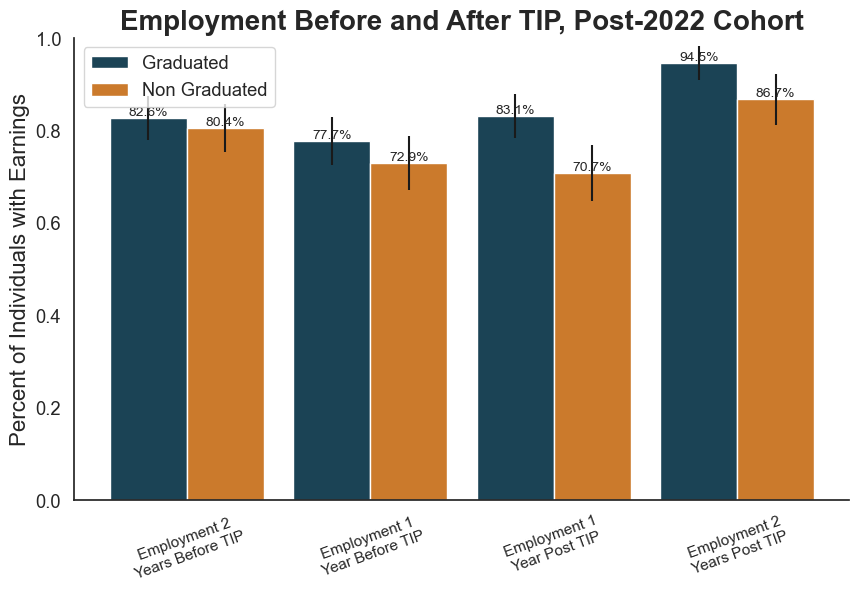

In [467]:
# -----------------------------
# 0) join Status / StartDate / ValidYears onto df_earnings
# -----------------------------
e = df_earnings.merge(
    df[["tip_id", "StartDate", "ValidYears", "Status", "cohort_2022", "ValidYearsPre"]],
    on="tip_id",
    how="left"
)

# keep only Graduated / Non Graduated, cohort 1
e = e[(e["Status"].isin(["Graduated", "Non Graduated"])) & (e["cohort_2022"] ==2)].copy()

# -----------------------------
# 1) YearsSinceTIP (in years) using quarter end date
# -----------------------------
e["YearsSinceTIP"] = (e["year_quarter_dt"] - e["StartDate"]).dt.days / 365.25

# "employment in quarter" indicator: has employer legal name in that quarter
e["employed_quarter"] = e["employer_legal_name"].notna() & (e["employer_legal_name"].astype(str).str.strip() != "")

# integer bin for pre buckets: >0 -> ceil, <0 -> floor, 0 -> 0
y = e["YearsSinceTIP"]
e["YearsSinceTIP_int"] = np.where(y > 0, np.ceil(y), np.where(y < 0, np.floor(y), 0)).astype(int)

# -----------------------------
# 2) PRE: bins (cumulative)
# -----------------------------
pre_points = [-1, -2]
rows = []
for i in pre_points:
    cur = e[(e["YearsSinceTIP"] < 0) & (e["YearsSinceTIP"] >= i) & (e["ValidYearsPre"] <= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = (cur.loc[(cur["Status"] == status) & (cur["employed_quarter"])]
       ["tip_id"]
       .nunique())
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYearsPre"] <= i) & (ac_records["cohort_2022"]==2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

pre_df = pd.DataFrame(rows)

# -----------------------------
# 3) POST: cumulative windows [0, i) for i = 1,2 and require ValidYears > i
# -----------------------------
post_points = [1, 2]
rows = []

for i in post_points:
    cur = e[
    (e["YearsSinceTIP"] >= 0) &
    (e["YearsSinceTIP"] < i) &
    (e["ValidYears"] > i) &
    (e["employed_quarter"])
]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = ac_records.loc[(ac_records["Status"] == status) & (ac_records["ValidYears"] > i) & (ac_records["cohort_2022"]==2), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
# 4) assemble 6 categories + plot
# -----------------------------
label_map = {
    -2:  "Employment 2\nYears Before TIP",
    -1:  "Employment 1\nYear Before TIP",
     1:  "Employment 1\nYear Post TIP",
     2:  "Employment 2\nYears Post TIP",
}
order = [-2, -1, 1, 2]

pre_keep = pre_df[pre_df["YearsSinceTIP"].isin([-2, -1])].copy()

data = pd.concat([pre_keep, post_df], ignore_index=True)

data["YearsSinceTIP"] = pd.to_numeric(data["YearsSinceTIP"])

data["YearsSinceTIP"] = pd.Categorical(
    data["YearsSinceTIP"],
    categories=order,
    ordered=True
)

data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


data["label"] = data["YearsSinceTIP"].map(label_map)

grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("Employment Before and After TIP, Post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Earnings", fontdict={"fontsize": 16})
plt.ylim(0, 1.0)
plt.legend(loc="upper left")
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\4112218441.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


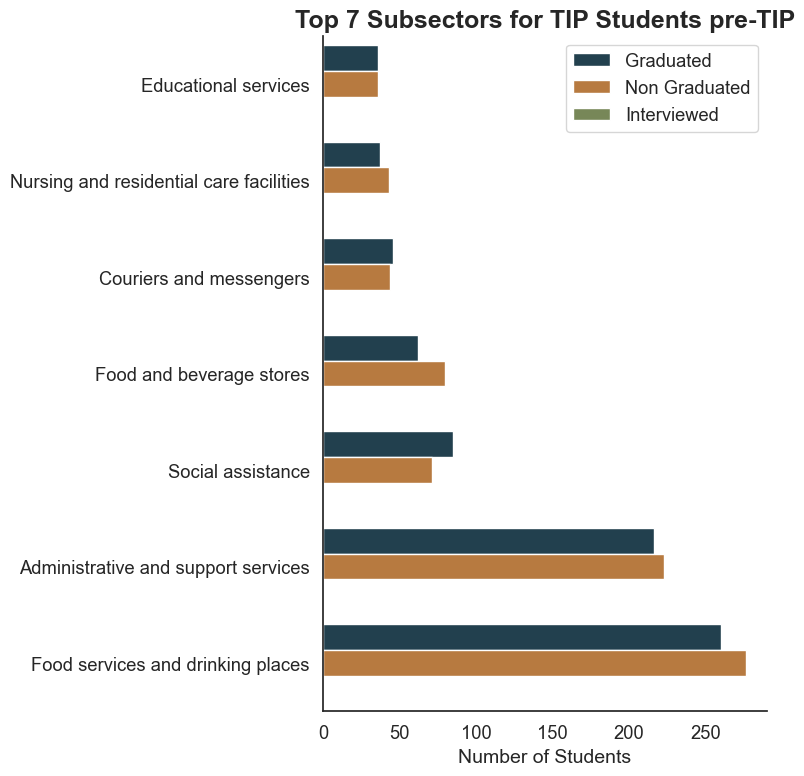

In [468]:
# 1) join StartDate + Status
e = df_earnings.merge(
    df[["tip_id", "StartDate", "Status"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + pre-TIP quarters + non-missing subsector
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] < e["StartDate"]) &
    e["naics_subsector_2017"].notna()
].copy()

# (optional) drop blank strings just in case
e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]

# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    counts.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

plot_df = counts[counts["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    plot_df.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=plot_df,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students pre-TIP", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2443096518.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


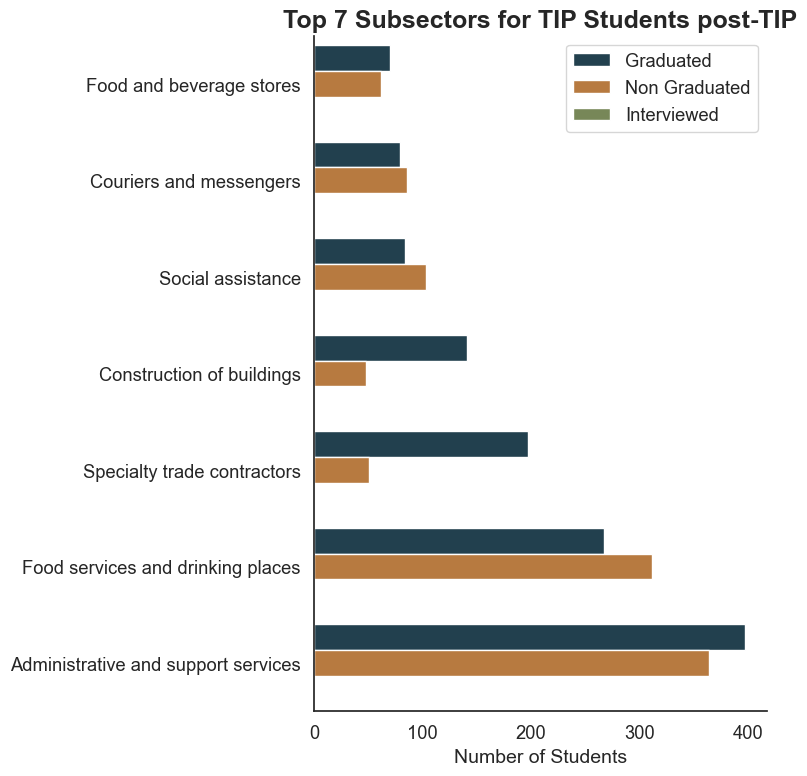

In [469]:
# 1) join StartDate + Status
e = df_earnings.merge(
    df[["tip_id", "StartDate", "Status"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + pre-TIP quarters + non-missing subsector
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] > e["StartDate"]) &
    e["naics_subsector_2017"].notna()
].copy()

# (optional) drop blank strings just in case
e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]

# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    counts.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

plot_df = counts[counts["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    plot_df.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=plot_df,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students post-TIP", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\327847501.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


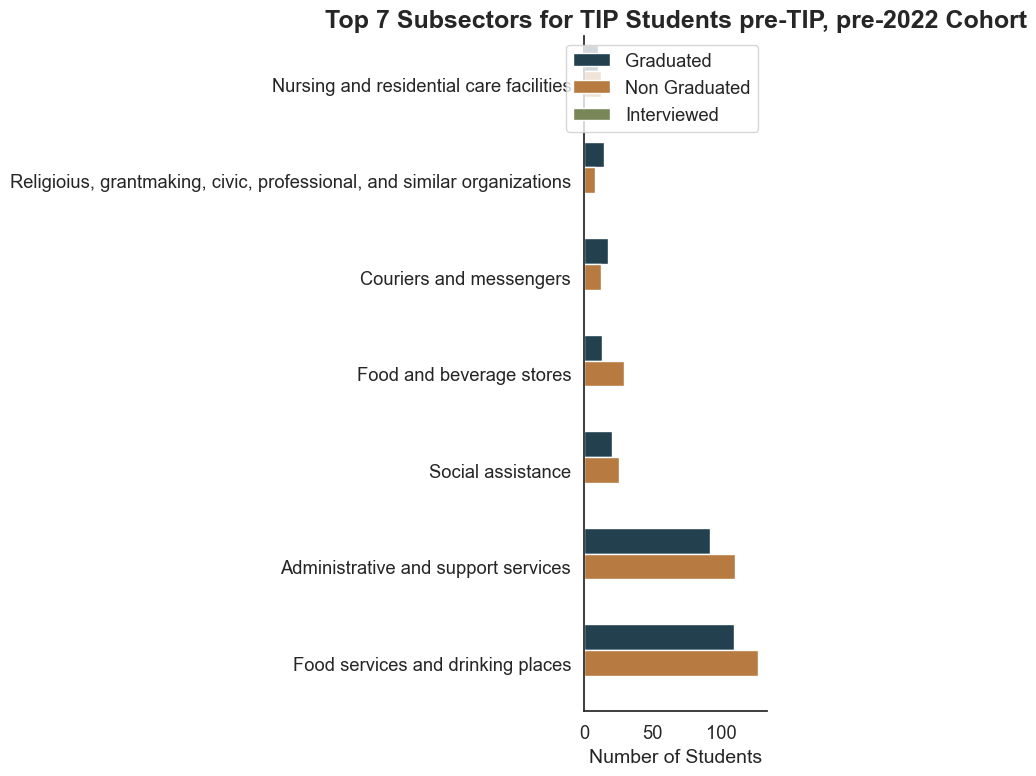

In [470]:
##pre-2022 cohort
# 1) join StartDate + Status
e = df_earnings.merge(
    df[["tip_id", "StartDate", "Status", "cohort_2022"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + pre-TIP quarters + non-missing subsector, cohort =1
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] < e["StartDate"]) &
    e["naics_subsector_2017"].notna() &
    (e["cohort_2022"] == 1)
].copy()

# (optional) drop blank strings just in case
e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]

# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    counts.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

plot_df = counts[counts["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    plot_df.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=plot_df,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students pre-TIP, pre-2022 Cohort", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2326797431.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


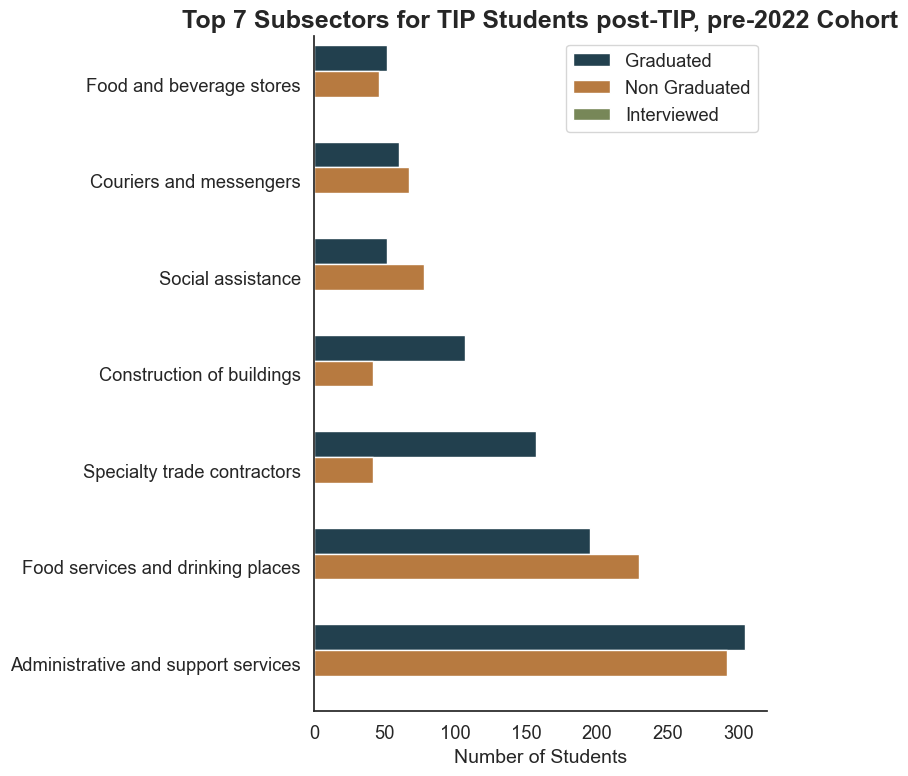

In [471]:
##pre-2022 cohort
# 1) join StartDate + Status
e = df_earnings.merge(
    df[["tip_id", "StartDate", "Status", "cohort_2022"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + pre-TIP quarters + non-missing subsector, cohort =1
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] > e["StartDate"]) &
    e["naics_subsector_2017"].notna() &
    (e["cohort_2022"] == 1)
].copy()

# (optional) drop blank strings just in case
e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]

# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    counts.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

plot_df = counts[counts["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    plot_df.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=plot_df,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students post-TIP, pre-2022 Cohort", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2455625167.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


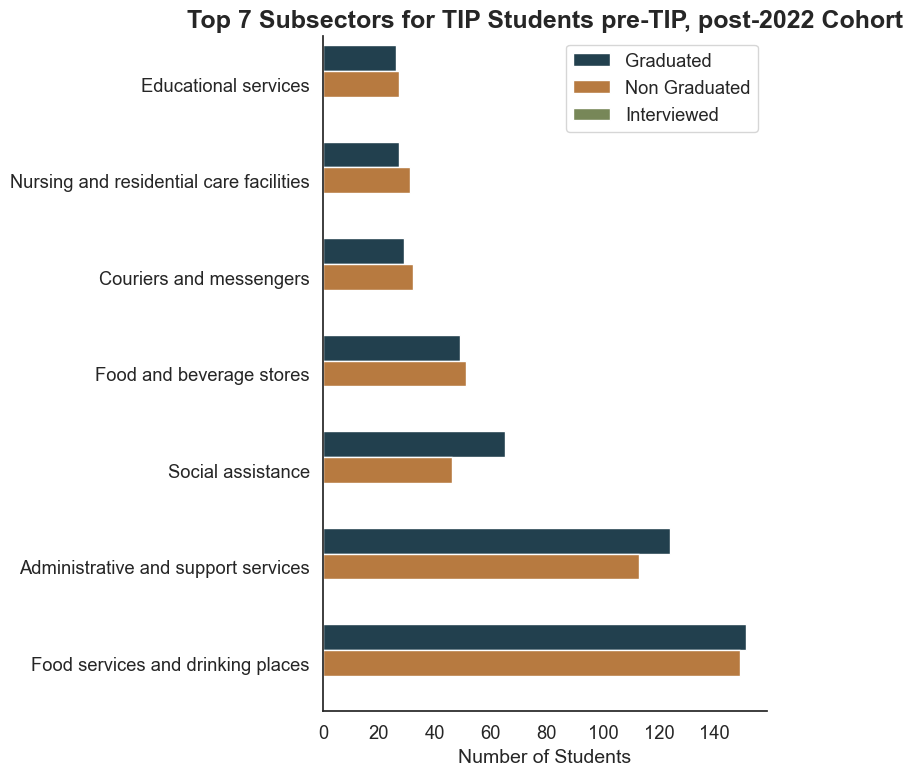

In [472]:
##post-2022 cohort
# 1) join StartDate + Status
e = df_earnings.merge(
    df[["tip_id", "StartDate", "Status", "cohort_2022"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + pre-TIP quarters + non-missing subsector, cohort =1
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] < e["StartDate"]) &
    e["naics_subsector_2017"].notna() &
    (e["cohort_2022"] == 2)
].copy()

# (optional) drop blank strings just in case
e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]

# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    counts.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

plot_df = counts[counts["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    plot_df.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=plot_df,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students pre-TIP, post-2022 Cohort", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\sarah\AppData\Local\Temp\ipykernel_7424\2740944143.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e.groupby(["naics_subsector_2017", "Status"])["tip_id"]


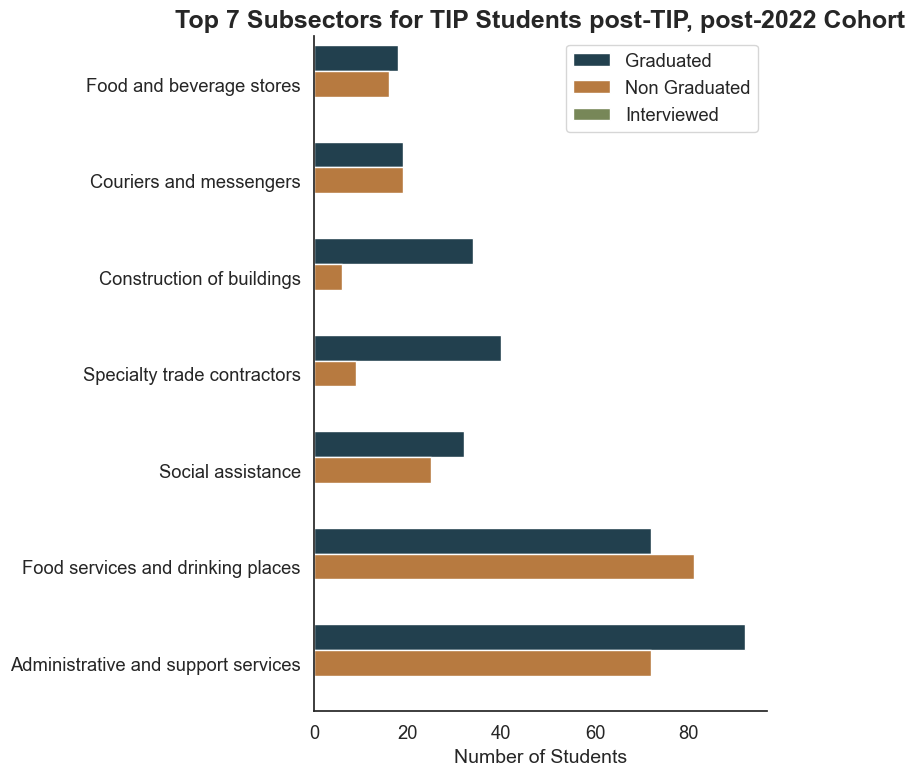

In [473]:
##post-2022 cohort
# 1) join StartDate + Status
e = df_earnings.merge(
    df[["tip_id", "StartDate", "Status", "cohort_2022"]],
    on="tip_id",
    how="left"
)

# 2) keep only Grad / Non Grad + pre-TIP quarters + non-missing subsector, cohort =1
e = e[
    e["Status"].isin(["Graduated", "Non Graduated"]) &
    (e["year_quarter_dt"] > e["StartDate"]) &
    e["naics_subsector_2017"].notna() &
    (e["cohort_2022"] == 2)
].copy()

# (optional) drop blank strings just in case
e = e[e["naics_subsector_2017"].astype(str).str.strip() != ""]

# 3) count unique students (tip_id) by subsector and status
counts = (
    e.groupby(["naics_subsector_2017", "Status"])["tip_id"]
    .nunique()
    .reset_index(name="count")
)

# 4) pick overall top 7 subsectors by total students (across both statuses)
top7 = (
    counts.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

plot_df = counts[counts["naics_subsector_2017"].isin(top7)].copy()

# order y-axis by total (top to bottom)
order = (
    plot_df.groupby("naics_subsector_2017")["count"]
    .sum()
    .sort_values(ascending=True)   # ascending so biggest ends up on top after barh
    .index
)

# 5) plot
plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=plot_df,
    y="naics_subsector_2017",
    x="count",
    hue="Status",
    order=order,
    orient="h"
)

sns.despine()
plt.title("Top 7 Subsectors for TIP Students post-TIP, post-2022 Cohort", fontdict={"fontsize": 18, "fontweight": "semibold"})
plt.xlabel("Number of Students", fontdict={"fontsize": 14})
plt.ylabel("")

# make legend look like screenshot order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title=None, loc="upper right")

plt.tight_layout()
plt.show()


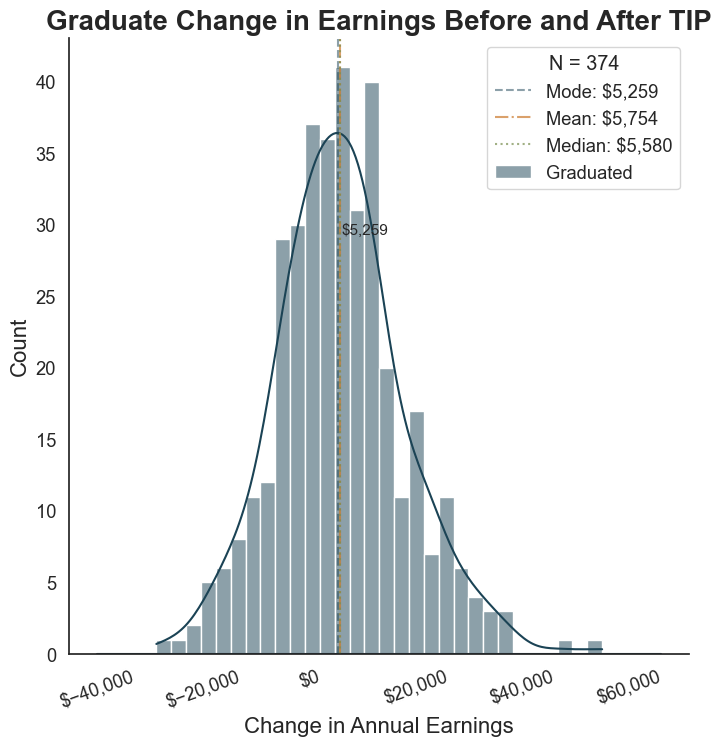

In [474]:
# Compute statistics
earn_change_grad = earn_change[earn_change['Status'] == 'Graduated'].copy()
mean_delta = earn_change_grad["delta"].mean()
median_delta = earn_change_grad["delta"].median()

#plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_grad,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_grad, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

# Optional: annotate values
ax.text(peak_x + 5000, y_vals[peak_idx]*0.8, f"${peak_x:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="medium")

sns.despine()
plt.title("Graduate Change in Earnings Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_grad.shape[0]}")
plt.show()


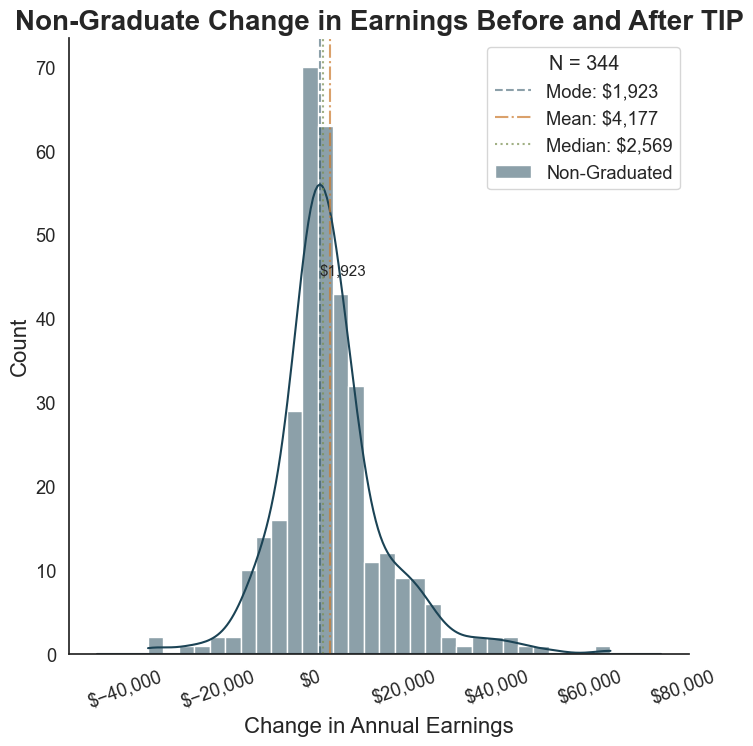

In [475]:
earn_change_non_grad = earn_change[earn_change['Status'] == 'Non Graduated'].copy()
mean_delta = earn_change_non_grad["delta"].mean()
median_delta = earn_change_non_grad["delta"].median()


# plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_non_grad,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Non-Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_non_grad, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

# Optional: annotate values
ax.text(peak_x + 5000, y_vals[peak_idx]*0.8, f"${peak_x:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="medium")

sns.despine()
plt.title("Non-Graduate Change in Earnings Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_non_grad.shape[0]}")
plt.show()


In [476]:
earn_change_grad.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,374.000000,374,374.000000,374.000000,374.000000,374.000000,374.000000
mean,1373.545455,2021-07-18 09:25:59.358288640,2021.101604,1.502674,10275.843765,16029.424910,5753.581145
min,10.000000,2017-04-17 00:00:00,2017.000000,1.000000,77.159082,14.789943,-28886.714802
25%,990.500000,2019-09-16 00:00:00,2019.000000,1.000000,3609.904514,7336.520877,-2088.715103
50%,1410.500000,2022-01-06 12:00:00,2022.000000,2.000000,7284.939406,14130.668597,5580.058528
75%,1734.000000,2023-04-29 06:00:00,2023.000000,2.000000,14272.133361,23157.124189,12289.483929
max,2188.000000,2024-09-23 00:00:00,2024.000000,2.000000,62745.285262,74247.860137,55003.226414
std,451.216570,NaN,2.102047,0.500663,9731.966795,11976.420811,12083.769046


In [477]:
earn_change_non_grad.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,344.000000,344,344.000000,344.000000,344.000000,344.000000,344.000000
mean,1353.744186,2021-07-18 22:02:47.441860352,2021.046512,1.447674,8044.593035,12221.989537,4177.396502
min,1.000000,2017-04-10 00:00:00,2017.000000,1.000000,85.067149,59.610125,-35080.770764
25%,1048.750000,2020-01-06 00:00:00,2019.750000,1.000000,2093.632084,3207.307049,-1191.418726
50%,1349.500000,2021-08-30 00:00:00,2021.000000,1.000000,5109.347011,8841.699164,2568.812911
75%,1663.500000,2023-03-16 12:00:00,2023.000000,2.000000,9931.498824,16468.892562,8238.102477
max,2183.000000,2024-09-16 00:00:00,2024.000000,2.000000,83610.279828,129228.110668,64428.346159
std,429.004032,NaN,1.958205,0.497979,9406.169401,13461.001527,11672.107972


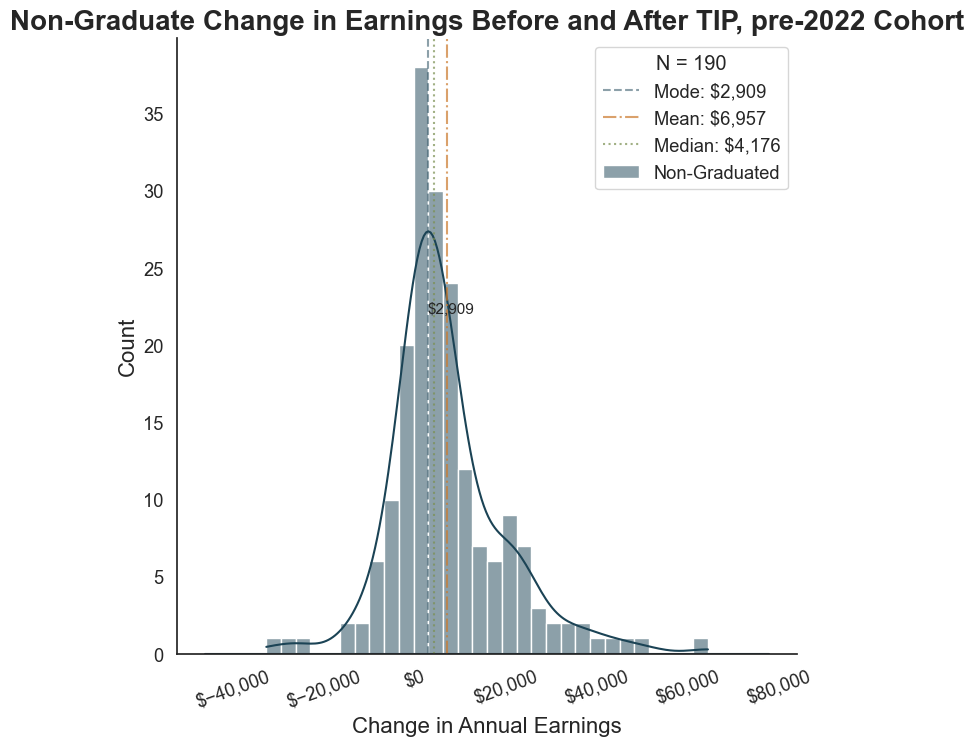

In [478]:
earn_change_non_grad_c1 = earn_change_non_grad[earn_change_non_grad['cohort_2022'] == 1].copy()
mean_delta = earn_change_non_grad_c1["delta"].mean()
median_delta = earn_change_non_grad_c1["delta"].median()


# plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_non_grad_c1,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Non-Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_non_grad_c1, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

# Optional: annotate values
ax.text(peak_x + 5000, y_vals[peak_idx]*0.8, f"${peak_x:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="medium")

sns.despine()
plt.title("Non-Graduate Change in Earnings Before and After TIP, pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_non_grad_c1.shape[0]}")
plt.show()


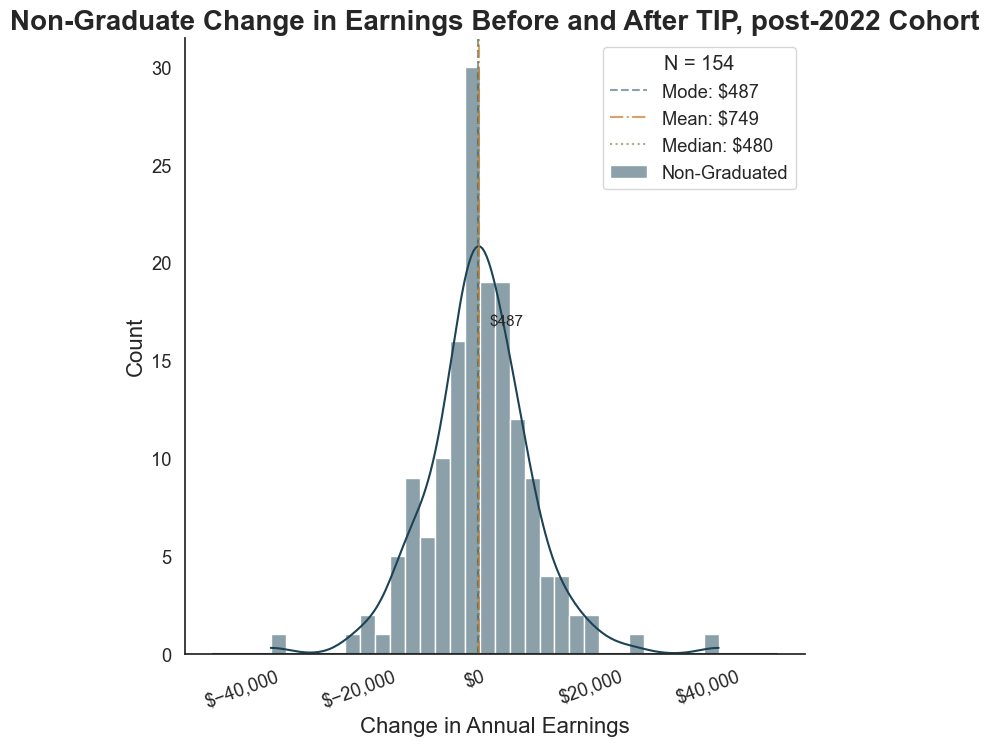

In [479]:
earn_change_non_grad_c2 = earn_change_non_grad[earn_change_non_grad['cohort_2022'] == 2].copy()
mean_delta = earn_change_non_grad_c2["delta"].mean()
median_delta = earn_change_non_grad_c2["delta"].median()


# plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_non_grad_c2,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Non-Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_non_grad_c2, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

# Optional: annotate values
ax.text(peak_x + 5000, y_vals[peak_idx]*0.8, f"${peak_x:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="medium")

sns.despine()
plt.title("Non-Graduate Change in Earnings Before and After TIP, post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_non_grad_c2.shape[0]}")
plt.show()


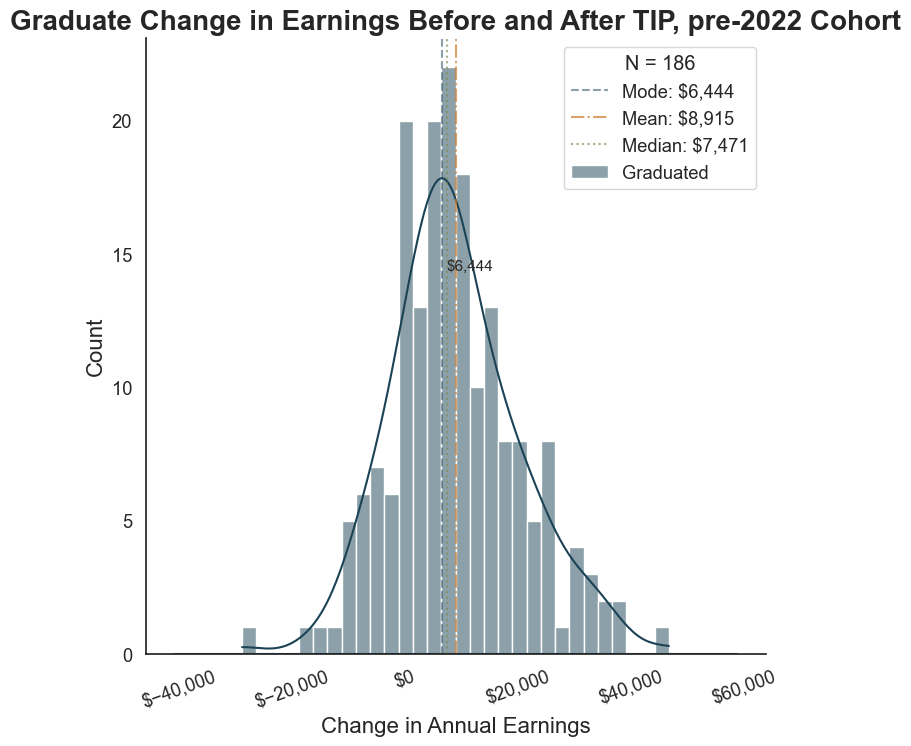

In [480]:
earn_change_grad_c1 = earn_change_grad[earn_change_grad['cohort_2022'] == 1].copy()
mean_delta = earn_change_grad_c1["delta"].mean()
median_delta = earn_change_grad_c1["delta"].median()


# plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_grad_c1,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_grad_c1, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

# Optional: annotate values
ax.text(peak_x + 5000, y_vals[peak_idx]*0.8, f"${peak_x:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="medium")

sns.despine()
plt.title("Graduate Change in Earnings Before and After TIP, pre-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_grad_c1.shape[0]}")
plt.show()


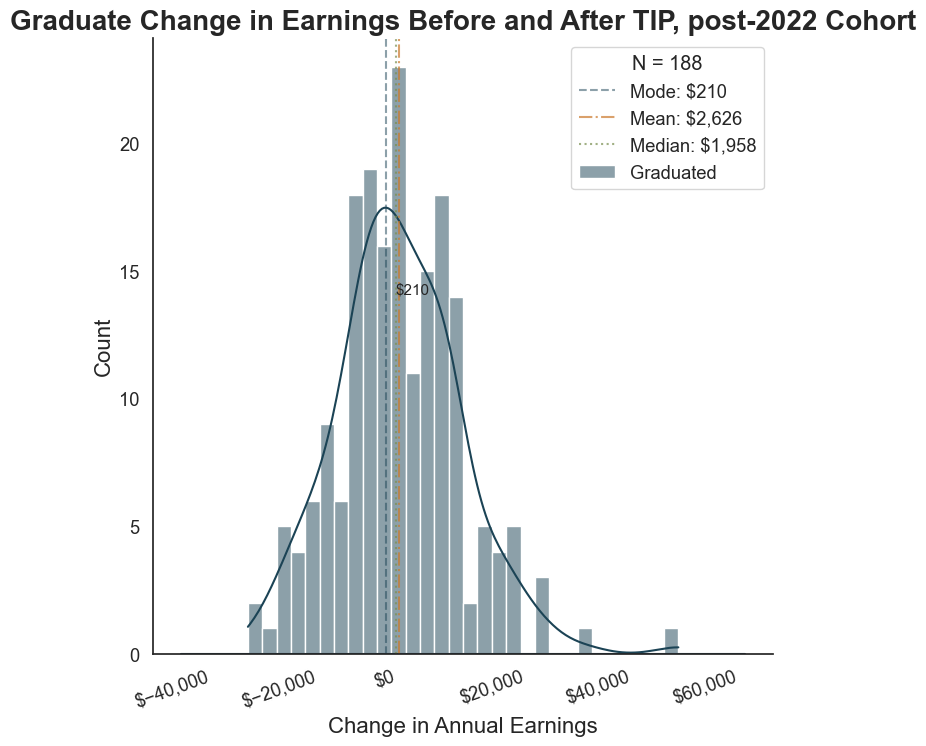

In [481]:
earn_change_grad_c2 = earn_change_grad[earn_change_grad['cohort_2022'] == 2].copy()
mean_delta = earn_change_grad_c2["delta"].mean()
median_delta = earn_change_grad_c2["delta"].median()


# plot
fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(
    data=earn_change_grad_c2,
    x="delta",
    kde=True,
    bins=30,
    ax=ax,
    label="Graduated"
)

# KDE peak
kde = sns.kdeplot(data=earn_change_grad_c2, x="delta", ax=ax)
x_vals, y_vals = kde.get_lines()[0].get_data()
peak_idx = y_vals.argmax()
peak_x = x_vals[peak_idx]

ax.axvline(peak_x, linestyle="--", color="C0", alpha=0.5, label=f"Mode: ${peak_x:,.0f}")
ax.axvline(mean_delta, linestyle="-.", color="C1", alpha=0.7, label=f"Mean: ${mean_delta:,.0f}")
ax.axvline(median_delta, linestyle=":", color="C2", alpha=0.7, label=f"Median: ${median_delta:,.0f}")

# Optional: annotate values
ax.text(peak_x + 5000, y_vals[peak_idx]*0.8, f"${peak_x:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="medium")

sns.despine()
plt.title("Graduate Change in Earnings Before and After TIP, post-2022 Cohort", fontdict={"fontsize": 20, "fontweight": "semibold"})
ax.xaxis.set_major_formatter("${x:,.0f}")
plt.xticks(rotation=20)
plt.xlabel("Change in Annual Earnings", fontdict={"fontsize": 16})
plt.ylabel("Count", fontdict={"fontsize": 16})
plt.legend(title=f"N = {earn_change_grad_c2.shape[0]}")
plt.show()


In [482]:
earn_change_non_grad_c1.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,190.000000,190,190.000000,190.0,190.000000,190.000000,190.000000
mean,1051.047368,2020-02-02 14:31:34.736841984,2019.573684,1.0,8065.568162,15022.099452,6956.531289
min,1.000000,2017-04-10 00:00:00,2017.000000,1.0,85.067149,144.288900,-32732.647800
25%,873.500000,2019-02-25 00:00:00,2019.000000,1.0,1595.848808,4435.296481,266.446971
50%,1108.000000,2020-05-26 00:00:00,2020.000000,1.0,4365.763695,10411.742752,4175.617587
75%,1259.750000,2021-03-08 00:00:00,2021.000000,1.0,10017.615117,20571.391480,10706.987389
max,1426.000000,2021-12-20 00:00:00,2021.000000,1.0,83610.279828,129228.110668,64428.346159
std,266.106123,NaN,1.260865,0.0,10456.851524,16130.223575,12776.053732


In [483]:
earn_change_non_grad_c2.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,154.000000,154,154.000000,154.0,154.000000,154.000000,154.000000
mean,1727.201299,2023-05-06 16:03:07.012987136,2022.863636,2.0,8018.714632,8767.308474,748.593842
min,478.000000,2022-01-03 00:00:00,2022.000000,2.0,360.656891,59.610125,-35080.770764
25%,1564.000000,2022-09-06 00:00:00,2022.000000,2.0,2940.651731,2217.139299,-3719.410835
50%,1727.000000,2023-06-12 00:00:00,2023.000000,2.0,5616.013146,6502.498752,479.654730
75%,1909.750000,2023-12-04 00:00:00,2023.000000,2.0,9875.286566,12977.743746,5546.843890
max,2183.000000,2024-09-16 00:00:00,2024.000000,2.0,52183.252013,42308.650801,41853.849595
std,266.378039,NaN,0.784392,0.0,7954.422257,7941.217908,9075.446680


In [484]:
earn_change_grad_c1.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,186.000000,186,186.000000,186.0,186.000000,186.000000,186.000000
mean,998.462366,2019-09-18 05:01:56.129032192,2019.258065,1.0,9187.791559,18102.937384,8915.145826
min,10.000000,2017-04-17 00:00:00,2017.000000,1.0,77.159082,111.585738,-28886.714802
25%,803.500000,2018-09-11 18:00:00,2018.000000,1.0,2639.558404,10040.910819,1267.403565
50%,1004.000000,2019-08-29 12:00:00,2019.000000,1.0,5941.613319,15371.307517,7471.181016
75%,1193.250000,2020-09-03 12:00:00,2020.000000,1.0,10854.371110,24877.962478,15327.505644
max,1424.000000,2021-12-20 00:00:00,2021.000000,1.0,62745.285262,70853.168317,46713.080294
std,250.944618,NaN,1.220573,0.0,9835.209862,11682.455259,11488.323493


In [485]:
earn_change_grad_c2.describe()

,tip_id,StartDate,StartYear,cohort_2022,adjusted_earnings_pre,adjusted_earnings_post,delta
count,188.000000,188,188.000000,188.0,188.000000,188.000000,188.000000
mean,1744.638298,2023-05-11 10:58:43.404255232,2022.925532,2.0,11352.320949,13977.971079,2625.650130
min,476.000000,2022-01-03 00:00:00,2022.000000,2.0,207.407030,14.789943,-25765.520061
25%,1584.250000,2022-09-10 12:00:00,2022.000000,2.0,4688.957526,5164.121679,-4789.921461
50%,1732.000000,2023-04-27 12:00:00,2023.000000,2.0,8259.107300,10665.546396,1957.983611
75%,1930.250000,2024-01-16 00:00:00,2024.000000,2.0,15482.047293,19417.352138,10461.139313
max,2188.000000,2024-09-23 00:00:00,2024.000000,2.0,59344.877565,74247.860137,55003.226414
std,255.779290,NaN,0.784057,0.0,9532.919736,11940.467584,11870.374263


In [486]:
##Statistical Significance

In [487]:
#Difference in gender between cohorts
##overall
table = pd.crosstab(df["cohort_2022"], df["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print("Full Cohort")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 1
df_c1 = df[df["cohort_2022"]==1].copy()
table = pd.crosstab(df_c1["Status"], df_c1["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print("#################")
print("Within Cohort 1")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 2
df_c2 = df[df["cohort_2022"]==2].copy()
table = pd.crosstab(df_c2["Status"], df_c2["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print("#################")
print("Within Cohort 2")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##graduated
print("#################")
print("Among Grads Only")
table = pd.crosstab(df_grad["cohort_2022"], df_grad["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##nongraduated
print("#################")
print("Among Non-Grads Only")
table = pd.crosstab(df_non_grad["cohort_2022"], df_non_grad["gender"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

Full Cohort
gender       Female  Male
cohort_2022              
1.0              65   890
2.0              83   427
Chi-square: 31.782892523662944
p-value: 1.7240462412815912e-08
#################
Within Cohort 1
gender         Female  Male
Status                     
Graduated          23   460
Non Graduated      37   422
Interviewed         5     8
Chi-square: 24.858822714128024
p-value: 3.999219435291552e-06
#################
Within Cohort 2
gender         Female  Male
Status                     
Graduated          49   201
Non Graduated      26   203
Interviewed         8    23
Chi-square: 8.165603642628826
p-value: 0.01686016025664672
#################
Among Grads Only
gender       Female  Male
cohort_2022              
1.0              23   460
2.0              49   201
Chi-square: 39.28817600279567
p-value: 3.6564885954698225e-10
#################
Among Non-Grads Only
gender       Female  Male
cohort_2022              
1.0              37   422
2.0              26   203
Chi-squa

In [488]:
#Difference in race between cohorts
##overall
table = pd.crosstab(df["cohort_2022"], df["race"])
chi2, p, dof, expected = chi2_contingency(table)

print("Full Cohort")
print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 1
##graduated
print("#################")
print("Within Cohort 1 Only")
table = pd.crosstab(df_c1["Status"], df_c1["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##within cohort 2
##graduated
print("#################")
print("Within Cohort 2 Only")
table = pd.crosstab(df_c2["cohort_2022"], df_c2["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##graduated
print("#################")
print("Among Grads Only")
table = pd.crosstab(df_grad["cohort_2022"], df_grad["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

##nongraduated
print("#################")
print("Among Non-Grads Only")
table = pd.crosstab(df_non_grad["cohort_2022"], df_non_grad["race"])
chi2, p, dof, expected = chi2_contingency(table)

print(table)
print("Chi-square:", chi2)
print("p-value:", p)

Full Cohort
race         Black  Other  White
cohort_2022                     
1.0            846      2    103
2.0            481      2     22
Chi-square: 17.949742029840547
p-value: 0.00012655026019375796
#################
Within Cohort 1 Only
race           Black  Other  White
Status                            
Graduated        418      1     61
Non Graduated    415      1     42
Interviewed       13      0      0
Chi-square: 4.673633408912394
p-value: 0.3224525019276658
#################
Within Cohort 2 Only
race         Black  Other  White
cohort_2022                     
2.0            481      2     22
Chi-square: 0.0
p-value: 1.0
#################
Among Grads Only
race         Black  Other  White
cohort_2022                     
1.0            418      1     61
2.0            233      1     12
Chi-square: 11.206042879494035
p-value: 0.0036867077061644177
#################
Among Non-Grads Only
race         Black  Other  White
cohort_2022                     
1.0            415  

In [489]:
#Difference in mean age
##overall
age1 = pd.to_numeric(df[df["cohort_2022"] == 1]["age"], errors="coerce").dropna()
age2 = pd.to_numeric(df[df["cohort_2022"] == 2]["age"], errors="coerce").dropna()

t, p = ttest_ind(age1, age2, equal_var=False)

print("Age Across Cohorts")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(age1))
print("n2:", len(age2))

##within cohort 1
age1 = pd.to_numeric(df_c1[df_c1["Status"] == "Graduated"]["age"], errors="coerce").dropna()
age2 = pd.to_numeric(df_c1[df_c1["Status"] == "Non Graduated"]["age"], errors="coerce").dropna()

t, p = ttest_ind(age1, age2, equal_var=False)
print("#################")
print("Age within Cohort 1 Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(age1))
print("n2:", len(age2))

##within cohort 2
age1 = pd.to_numeric(df_c2[df_c2["Status"] == "Graduated"]["age"], errors="coerce").dropna()
age2 = pd.to_numeric(df_c2[df_c2["Status"] == "Non Graduated"]["age"], errors="coerce").dropna()

t, p = ttest_ind(age1, age2, equal_var=False)
print("#################")
print("Age within Cohort 2 Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(age1))
print("n2:", len(age2))

##graduated
age1 = pd.to_numeric(df_grad[df_grad["cohort_2022"] == 1]["age"], errors="coerce").dropna()
age2 = pd.to_numeric(df_grad[df_grad["cohort_2022"] == 2]["age"], errors="coerce").dropna()

t, p = ttest_ind(age1, age2, equal_var=False)
print("#################")
print("Age among Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(age1))
print("n2:", len(age2))

##nongraduated
age1 = pd.to_numeric(df_non_grad[df_non_grad["cohort_2022"] == 1]["age"], errors="coerce").dropna()
age2 = pd.to_numeric(df_non_grad[df_non_grad["cohort_2022"] == 2]["age"], errors="coerce").dropna()

t, p = ttest_ind(age1, age2, equal_var=False)
print("#################")
print("Age among Non-Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(age1))
print("n2:", len(age2))

Age Across Cohorts
t-value: 4.419869598374291
p-value: 1.098331826038522e-05
n1: 998
n2: 535
#################
Age within Cohort 1 Only
t-value: 4.110796473872131
p-value: 4.2726065331393064e-05
n1: 501
n2: 483
#################
Age within Cohort 2 Only
t-value: 1.6987384577956304
p-value: 0.08999682407864293
n1: 258
n2: 240
#################
Age among Grads Only
t-value: 3.4514990460086112
p-value: 0.0006111525525881946
n1: 501
n2: 258
#################
Age among Non-Grads Only
t-value: 2.6042402939000593
p-value: 0.009517027866254777
n1: 483
n2: 240


In [490]:
#Difference in average pre-annual salary
##overall
e1 = pd.to_numeric(df_e_combined[df_e_combined["cohort_2022"] == 1]["adjusted_earnings_pre"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined[df_e_combined["cohort_2022"] == 2]["adjusted_earnings_pre"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("Pre-Annual Across Cohorts")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 1
df_e_combined_c1 = df_e_combined[df_e_combined["cohort_2022"] == 1].copy()
df_e_combined_c2 = df_e_combined[df_e_combined["cohort_2022"] == 2].copy()

e1 = pd.to_numeric(df_e_combined_c1[df_e_combined_c1["Status"] == "Graduated"]["adjusted_earnings_pre"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_c1[df_e_combined_c1["Status"] == "Non Graduated"]["adjusted_earnings_pre"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Pre-Annual Within Cohort 1")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 1

e1 = pd.to_numeric(df_e_combined_c2[df_e_combined_c2["Status"] == "Graduated"]["adjusted_earnings_pre"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_c2[df_e_combined_c2["Status"] == "Non Graduated"]["adjusted_earnings_pre"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Pre-Annual Within Cohort 2")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##graduated
df_e_combined_grad = df_e_combined[df_e_combined["Status"] == "Graduated"].copy()
e1 = pd.to_numeric(df_e_combined_grad[df_e_combined_grad["cohort_2022"] == 1]["adjusted_earnings_pre"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_grad[df_e_combined_grad["cohort_2022"] == 2]["adjusted_earnings_pre"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Pre-Annual among Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##nongraduated
df_e_combined_non_grad = df_e_combined[df_e_combined["Status"] == "Non Graduated"].copy()
e1 = pd.to_numeric(df_e_combined_non_grad[df_e_combined_non_grad["cohort_2022"] == 1]["adjusted_earnings_pre"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_non_grad[df_e_combined_non_grad["cohort_2022"] == 2]["adjusted_earnings_pre"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Pre-Annual among Non-Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))


Pre-Annual Across Cohorts
t-value: -1.1475473303099288
p-value: 0.25151178352578984
n1: 389
n2: 416
#################
Pre-Annual Within Cohort 1
t-value: 1.1137727413127403
p-value: 0.26606803290248515
n1: 189
n2: 200
#################
Pre-Annual Within Cohort 2
t-value: 3.9777489922060427
p-value: 8.224469556812349e-05
n1: 215
n2: 201
#################
Pre-Annual among Grads Only
t-value: -1.8809711892747474
p-value: 0.06072414215573534
n1: 189
n2: 215
#################
Pre-Annual among Non-Grads Only
t-value: 0.4460511234251849
p-value: 0.6558200055887053
n1: 200
n2: 201


In [491]:
#Difference in average post-annual salary
##overall
e1 = pd.to_numeric(df_e_combined[df_e_combined["cohort_2022"] == 1]["adjusted_earnings_post"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined[df_e_combined["cohort_2022"] == 2]["adjusted_earnings_post"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("Post-Annual Across Cohorts")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 1
e1 = pd.to_numeric(df_e_combined_c1[df_e_combined_c1["Status"] == "Graduated"]["adjusted_earnings_post"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_c1[df_e_combined_c1["Status"] == "Non Graduated"]["adjusted_earnings_post"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Post-Annual Within Cohort 1")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 1

e1 = pd.to_numeric(df_e_combined_c2[df_e_combined_c2["Status"] == "Graduated"]["adjusted_earnings_post"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_c2[df_e_combined_c2["Status"] == "Non Graduated"]["adjusted_earnings_post"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Post-Annual Within Cohort 2")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##graduated
df_e_combined_grad = df_e_combined[df_e_combined["Status"] == "Graduated"].copy()
e1 = pd.to_numeric(df_e_combined_grad[df_e_combined_grad["cohort_2022"] == 1]["adjusted_earnings_post"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_grad[df_e_combined_grad["cohort_2022"] == 2]["adjusted_earnings_post"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Post-Annual among Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##nongraduated
df_e_combined_non_grad = df_e_combined[df_e_combined["Status"] == "Non Graduated"].copy()
e1 = pd.to_numeric(df_e_combined_non_grad[df_e_combined_non_grad["cohort_2022"] == 1]["adjusted_earnings_post"], errors="coerce").dropna()
e2 = pd.to_numeric(df_e_combined_non_grad[df_e_combined_non_grad["cohort_2022"] == 2]["adjusted_earnings_post"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Post-Annual among Non-Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))


Post-Annual Across Cohorts
t-value: 6.258160021395966
p-value: 5.998414733028038e-10
n1: 867
n2: 366
#################
Post-Annual Within Cohort 1
t-value: 3.138409829714044
p-value: 0.001758609289959464
n1: 451
n2: 416
#################
Post-Annual Within Cohort 2
t-value: 5.462713429678022
p-value: 8.861108020374146e-08
n1: 202
n2: 164
#################
Post-Annual among Grads Only
t-value: 3.3918640259119854
p-value: 0.0007579315730556491
n1: 451
n2: 202
#################
Post-Annual among Non-Grads Only
t-value: 6.376170082075286
p-value: 3.957109849266346e-10
n1: 416
n2: 164


In [492]:
#Change in pre/post salary
##overall
e1 = pd.to_numeric(earn_change[earn_change["cohort_2022"] == 1]["delta"], errors="coerce").dropna()
e2 = pd.to_numeric(earn_change[earn_change["cohort_2022"] == 2]["delta"], errors="coerce").dropna()

t, p = ttest_ind(e1, e2, equal_var=False)

print("Earnings Change Across Cohorts")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 1
e1 = earn_change_grad_c1["delta"]
e2 = earn_change_non_grad_c1["delta"]

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Earnings Change Within Cohort 1")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##within Cohort 2

e1 = earn_change_grad_c2["delta"]
e2 = earn_change_non_grad_c2["delta"]

t, p = ttest_ind(e1, e2, equal_var=False)

print("#################")
print("Earnings Change Within Cohort 2")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##graduated
e1 = earn_change_grad[earn_change_grad["cohort_2022"] == 1]["delta"]
e2 = earn_change_grad[earn_change_grad["cohort_2022"] == 2]["delta"]

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Earnings Change among Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

##nongraduated

e1 = earn_change_non_grad[earn_change_non_grad["cohort_2022"] == 1]["delta"]
e2 = earn_change_non_grad[earn_change_non_grad["cohort_2022"] == 2]["delta"]

t, p = ttest_ind(e1, e2, equal_var=False)
print("#################")
print("Earnings Change among Non-Grads Only")
print("t-value:", t)
print("p-value:", p)
print("n1:", len(e1))
print("n2:", len(e2))

Earnings Change Across Cohorts
t-value: 7.186905418568905
p-value: 1.6704608186090085e-12
n1: 376
n2: 342
#################
Earnings Change Within Cohort 1
t-value: 1.563806725331676
p-value: 0.1187147339235355
n1: 186
n2: 190
#################
Earnings Change Within Cohort 2
t-value: 1.6563010304111019
p-value: 0.09858760953558954
n1: 188
n2: 154
#################
Earnings Change among Grads Only
t-value: 5.206869400260217
p-value: 3.1858016896142317e-07
n1: 186
n2: 188
#################
Earnings Change among Non-Grads Only
t-value: 5.258091362909057
p-value: 2.5932958525011365e-07
n1: 190
n2: 154


In [493]:
#DiD - Earnings

import statsmodels.formula.api as smf

earn_change['treatment'] = (earn_change['Status'] == 'Graduated').astype(int)
earn_change['cohort2'] = (earn_change['cohort_2022'] == 2).astype(int)

# regression for triple diff
# earnings_diff ~ treatment*cohort2
model = smf.ols("delta ~ treatment * cohort2", data=earn_change).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  delta   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     18.75
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.03e-11
Time:                        21:22:38   Log-Likelihood:                -7729.4
No. Observations:                 718   AIC:                         1.547e+04
Df Residuals:                     714   BIC:                         1.549e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          6956.5313    833.37

In [498]:
#Unconditional DiD - Employment
e = df_earnings.merge(
    df[["tip_id", "StartDate", "ValidYears", "Status", 'ValidYearsPre', 'cohort_2022']],
    on="tip_id",
    how="left"
)

# keep only Graduated / Non Graduated
e = e[e["Status"].isin(["Graduated", "Non Graduated"])].copy()


e["YearsSinceTIP"] = (e["year_quarter_dt"] - e["StartDate"]).dt.days / 365.25

# "employment in quarter" indicator: has employer legal name in that quarter
e["employed_quarter"] = e["employer_legal_name"].notna() & (e["employer_legal_name"].astype(str).str.strip() != "")

# integer bin for pre buckets: >0 -> ceil, <0 -> floor, 0 -> 0
y = e["YearsSinceTIP"]
e["YearsSinceTIP_int"] = np.where(y > 0, np.ceil(y), np.where(y < 0, np.floor(y), 0)).astype(int)

e.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,...,CPI,adjusted_earnings,StartDate,ValidYears,Status,ValidYearsPre,cohort_2022,YearsSinceTIP,employed_quarter,YearsSinceTIP_int
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,246.524,4136.708548,2017-05-08,8.569473,Graduated,-0.347707,1.0,0.648871,True,1
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,246.524,6117.649056,2017-05-08,8.569473,Graduated,-0.347707,1.0,0.648871,True,1
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,249.554,2477.600167,2017-05-08,8.569473,Graduated,-0.347707,1.0,0.895277,True,1
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,...,249.554,9303.985951,2017-05-08,8.569473,Graduated,-0.347707,1.0,0.895277,True,1
5,556,20181,GLUUTENY LLC,171,311811.0,Manufacturing,Food manufacturing,Retail Bakeries,Manufacturing,Food Manufacturing,...,249.554,222.049072,2017-05-08,8.569473,Graduated,-0.347707,1.0,0.895277,True,1
